## 1. Importando dependencias

In [ ]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


---

## 2. Importando o dataset


In [89]:
data_path = r'../data/processed/temperature_data.csv'
dados = pd.read_csv(data_path, delimiter=';')
print(f"Data Path: {data_path}")

Data Path: ../data/processed/temperature_data.csv


---

## 3. Estudo do dataset


In [146]:
print("Resumo do dataset:")
print("Shape:", dados.shape)
print("Colunas:", dados.shape[1])
print("Linhas:", dados.shape[0])

print("\nTipos de dados das colunas:")
print(dados.dtypes)

print("\nEstatísticas da variável alvo:")
if 'temperaturasaidafp' in dados.columns:
    print(dados['temperaturasaidafp'].describe())
else:
    print("Variável alvo 'temperaturasaidafp' não encontrada.")
    print("Colunas disponíveis:", list(dados.columns))

Resumo do dataset:
Shape: (7485, 16)
Colunas: 16
Linhas: 7485

Tipos de dados das colunas:
corrida                    int64
secao                    float64
acoatual                  object
qualidade                 object
al_min                   float64
n_min                    float64
s_min                    float64
sequencia                float64
sequenciatotal           float64
panela                   float64
vidapanela               float64
tempociclo               float64
tempovacuototal          float64
temperaturaliquidus      float64
temperaturasaidafp         int64
temperaturaobjetivada    float64
dtype: object

Estatísticas da variável alvo:
count    7485.000000
mean     1654.005745
std        21.711345
min      1583.000000
25%      1640.000000
50%      1654.000000
75%      1668.000000
max      1753.000000
Name: temperaturasaidafp, dtype: float64


---

## 4. Buscando valores ausentes


In [91]:
print(f"entendendo valores ausentes")
missing_values = dados.isnull().sum()
total_missing = missing_values.sum()

print(f"faltantes: {total_missing}")
if total_missing > 0:
    print(f"\nFaltantes por coluna:")
    print(missing_values[missing_values > 0])
    
  
    print(f"\nFilling missing values:")

    numeric_cols = dados.select_dtypes(include=[np.number]).columns
    filled_numeric = 0
    for col in numeric_cols:
        if dados[col].isnull().sum() > 0:
            median_val = dados[col].median()
            dados[col].fillna(median_val, inplace=True)
            filled_numeric += 1
            print(f"  • {col}: filled with median ({median_val:.2f})")
    
 
    categorical_cols = dados.select_dtypes(include=['object', 'category']).columns
    filled_categorical = 0
    for col in categorical_cols:
        if dados[col].isnull().sum() > 0:
            mode_val = dados[col].mode()[0]
            dados[col].fillna(mode_val, inplace=True)
            filled_categorical += 1
            print(f"  • {col}: filled with mode ({mode_val})")
    
    print(f"\nFilled {filled_numeric} numeric and {filled_categorical} categorical columns")
else:
    print("tudo certo por aqui")

entendendo valores ausentes
faltantes: 0
tudo certo por aqui


---

## 5. Definindo as features categoricas

In [92]:

categorical_features = ['acoatual', 'qualidade']
target_col = 'temperaturasaidafp'

print(f"features categoricas")
print(f"features categoricas: {categorical_features}")

if len(categorical_features) > 0:
    print(f"\nFeatures categóricas:")
    for i, feat in enumerate(categorical_features):
        if feat in dados.columns:
            unique_count = dados[feat].nunique()
            print(f"  {i+1:2}. {feat:25} | Unique values: {unique_count}")
            print(f"      Sample values: {list(dados[feat].unique()[:5])}")
        else:
            print(f"  {i+1:2}. {feat:25} | coluna não encontrada no dataset")
else:
    print("Nenhum recurso categórico definido")


valid_categorical_features = [feat for feat in categorical_features if feat in dados.columns]
if len(valid_categorical_features) != len(categorical_features):
    print(f"\n Warning: {len(categorical_features) - len(valid_categorical_features)} categorical features not found in dataset")
    categorical_features = valid_categorical_features


total_features = dados.shape[1] - 1 
numeric_features = total_features - len(categorical_features)
print(f"\nestudo de features")
print(f"Total: {total_features}")
print(f"Numericas: {numeric_features}")
print(f"Categoricas: {len(categorical_features)}")


print(f"\n=== convertendo cat para string ===")
for feat in categorical_features:
    if feat in dados.columns:

        dados[feat] = dados[feat].astype(str)
        print(f"{feat}: convertida para string")
    
print(f"catgoricas agora sao strings")

features categoricas
features categoricas: ['acoatual', 'qualidade']

Features categóricas:
   1. acoatual                  | Unique values: 3505
      Sample values: ['336236CB', 'D7B079C7', 'E5AB530D', '457B036C', '8F368B5C']
   2. qualidade                 | Unique values: 253
      Sample values: ['1F3F501C', '96956A01', 'A8E02CB3', '7BF6FBDF', '59D14704']

estudo de features
Total: 15
Numericas: 13
Categoricas: 2

=== convertendo cat para string ===
acoatual: convertida para string
qualidade: convertida para string
catgoricas agora sao strings


---

## 6. Preparando as features e a feature target (x e y)

In [93]:

X = dados.drop(columns=[target_col])
y = dados[target_col]

print(f"=== preparando features e a target ===")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target variable: {target_col}")

print(f"\n=== ESTATÍSTICAS DA VARIÁVEL ALVO ===")
print(f"Mean: {y.mean():.2f}")
print(f"Std: {y.std():.2f}")
print(f"Min: {y.min():.2f}")
print(f"Max: {y.max():.2f}")
print(f"Range: {y.max() - y.min():.2f}")

print(f"\n=== colunas de features ===")
feature_list = list(X.columns)
print(f"Total: {len(feature_list)} features")
for i, col in enumerate(feature_list[:10]): 
    print(f"  {i+1:2}. {col}")
if len(feature_list) > 10:
    print(f"  ... and {len(feature_list) - 10} more features")

=== preparando features e a target ===
Features shape: (7485, 15)
Target shape: (7485,)
Target variable: temperaturasaidafp

=== ESTATÍSTICAS DA VARIÁVEL ALVO ===
Mean: 1654.01
Std: 21.71
Min: 1583.00
Max: 1753.00
Range: 170.00

=== colunas de features ===
Total: 15 features
   1. corrida
   2. secao
   3. acoatual
   4. qualidade
   5. al_min
   6. n_min
   7. s_min
   8. sequencia
   9. sequenciatotal
  10. panela
  ... and 5 more features


##  O que este bloco faz

Este bloco prepara X (features) e y (target), imprime shapes, estatísticas básicas do alvo e lista as primeiras features:

- X = dados.drop(columns=[target_col]) → DataFrame com todas as colunas exceto a coluna alvo.
- y = dados[target_col] → Series com a variável alvo.
- Imprime shapes de X e y, nome da variável alvo.
- Mostra estatísticas do alvo: mean, std, min, max, range.
- Lista total de features e mostra os primeiros 10 nomes.

---

##  Passo a passo (resumido)

1. Separar variáveis explicativas (X) e variável resposta (y).  
2. Conferir shapes para garantir que X tem (n_samples, n_features) e y tem (n_samples,).  
3. Verificar estatísticas do alvo para entender escala e dispersão.  
4. Inspecionar nomes das features — útil para validar colunas categóricas e pipeline.

---

## O que fica em X e o que fica em y (explicação prática)

- X (features):
  - Contém todas as colunas usadas como entrada do modelo (preditores).
  - É um DataFrame 2D: cada linha = uma amostra, cada coluna = uma feature.
  - Pode conter colunas numéricas e categóricas.  
  - Ordem e nomes das colunas em X no treino devem ser os mesmos ao fazer predições.

- y (target):
  - Contém o valor que o modelo deve prever.
  - É uma Series 1D com mesmo número de linhas que X.
  - Para regressão (como temperatura) deve ser numérico; para classificação são rótulos (podem ser strings ou inteiros).

---

## Como CatBoost usa X e y

- CatBoost aceita diretamente:
  - model.fit(X, y) com X = DataFrame/ndarray e y = Series/array.
  - Ou usar Pool(data=X, label=y, cat_features=...) para passar metadados (recomendado quando há features categóricas, pesos, grupos).
- Tratamento de categóricas:
  - Informe as colunas categóricas via cat_features (nomes ou índices) ou converta para str/category antes de criar Pool.
  - CatBoost aplica codificação interna ótima para categoricals (target encoding, permutations), por isso é preferível não fazer One-Hot manual.
- Requisitos:
  - X e y devem ter mesma ordem e número de amostras.
  - Ao salvar/usar o modelo em produção, garanta que as colunas de entrada estejam na mesma ordem e formato (tipos) que no treino.
- Boas práticas:
  - Converter categóricas para str ou category antes do Pool.
  - Remover colunas com vazamento de informação (IDs temporais, targets futuros).
  - Verificar distribuição do target (outliers / escala) antes de treinar.

---

## Verificações rápidas sugeridas

- Confirme len(X) == len(y).  
- Verifique dtypes de X (X.dtypes) e converta categóricas: X[cat] = X[cat].astype(str).  
- Checar se target_col não está em X (já removido pelo drop).  
- Use Pool(X, y, cat_features=...) ao treinar para controle total.

---

## 7. Dividindo os dados para test e train

In [147]:
test_size = 0.2
random_state = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    random_state=random_state,
    stratify=None
)

print("Divisão dos dados:")
print(f"  Teste: {test_size:.0%} do total")
print(f"  Semente: {random_state}")

print("\nResumo da divisão:")
print(f"  Treino: {X_train.shape[0]:,} registros ({X_train.shape[0]/len(X):.0%})")
print(f"  Teste:  {X_test.shape[0]:,} registros ({X_test.shape[0]/len(X):.0%})")
print(f"  Features: {X_train.shape[1]}")

print("\nDistribuição da variável alvo:")
print(f"  Treino - média: {y_train.mean():.2f}, std: {y_train.std():.2f}")
print(f"  Teste  - média: {y_test.mean():.2f}, std: {y_test.std():.2f}")

Divisão dos dados:
  Teste: 20% do total
  Semente: 42

Resumo da divisão:
  Treino: 5,988 registros (80%)
  Teste:  1,497 registros (20%)
  Features: 15

Distribuição da variável alvo:
  Treino - média: 1653.97, std: 21.63
  Teste  - média: 1654.14, std: 22.05


##  O que este bloco faz

Este bloco divide o dataset em conjuntos de treino e teste e imprime informações resumidas sobre a divisão e a distribuição da variável alvo.

- Executa `train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=None)` para criar:
  - X_train, y_train → dados de treino
  - X_test, y_test → dados de teste
- Imprime parâmetros usados (tamanho do teste e semente) e resultados (nº de amostras em cada conjunto, percentual e nº de features).
- Imprime estatísticas simples da variável alvo em treino e teste (média e desvio padrão) para checar se a divisão alterou fortemente a distribuição do target.

---

##  Parâmetros chave

- test_size = 0.2 → 20% dos registros ficam no conjunto de teste.
- random_state = 42 → semente para tornar a divisão reprodutível.
- stratify = None → divisão aleatória sem estratificação (use estratify=y para problemas de classificação com classes desbalanceadas).

---

##  O que conferir após a divisão

- Tamanhos: X_train.shape / X_test.shape correspondem às proporções esperadas.
- Número de features: X_train.shape[1] deve ser igual ao de X.
- Distribuição do target: compare média e desvio padrão entre y_train e y_test — grandes diferenças podem indicar necessidade de estratificação ou revisão da amostra.
- Verifique vazamento de dados (leakage) entre treino e teste (ex.: colunas temporais, IDs).

---

##  Boas práticas rápidas

- Para classificação com classes desbalanceadas, use stratify=y.
- Para séries temporais, não use train_test_split aleatório; faça divisão temporal (por data).
- Mantenha `random_state` fixo para resultados reproduzíveis durante desenvolvimento e comparações de modelos.
- Confirme que índices/ordens não expõem informações do futuro ao treino (shuffle/ordem).

---

## Exemplo resumido de uso

- `train_test_split(X, y, test_size=0.2, random_state=42)`
- Verificar: `len(X_train), len(X_test), X_train.shape[1], y_train.mean(), y_test.mean()`



## 8. Criando as pools do catboost

In [148]:
print("Criando pools do CatBoost...")

train_pool = Pool(
    data=X_train,
    label=y_train,
    cat_features=categorical_features
)

test_pool = Pool(
    data=X_test,
    label=y_test,
    cat_features=categorical_features
)

print("Pool de treinamento criado:")
print(f"  • Amostras: {train_pool.num_row():,}")
print(f"  • Nº de features: {train_pool.num_col()}")
print(f"  • Features categóricas: {len(categorical_features)}")

print("\nPool de teste criado:")
print(f"  • Amostras: {test_pool.num_row():,}")
print(f"  • Nº de features: {test_pool.num_col()}")
print(f"  • Features categóricas: {len(categorical_features)}")

if categorical_features:
    print("\nFeatures categóricas nos pools:")
    for i, feat in enumerate(categorical_features[:5]):
        print(f"  {i+1}. {feat}")
    if len(categorical_features) > 5:
        print(f"  ... e mais {len(categorical_features) - 5}")

Criando pools do CatBoost...
Pool de treinamento criado:
  • Amostras: 5,988
  • Nº de features: 15
  • Features categóricas: 2

Pool de teste criado:
  • Amostras: 1,497
  • Nº de features: 15
  • Features categóricas: 2

Features categóricas nos pools:
  1. acoatual
  2. qualidade


## O que este bloco faz

Este trecho cria os "pools" (estruturas de dados do CatBoost) para treino e teste e imprime informações resumidas para checagem rápida:

- Cria `train_pool` e `test_pool` com:
  - data = X_train / X_test
  - label = y_train / y_test
  - cat_features = lista de features categóricas
- Imprime informações básicas dos pools:
  - número de amostras (`num_row()`)
  - número de features (`num_col()`)
  - quantidade de features categóricas
- Se houver features categóricas, lista as 5 primeiras para verificação rápida.

---

##  Passo a passo (resumido)
1. Construir Pool de treino com dados e rótulos.
2. Construir Pool de teste com dados e rótulos.
3. Mostrar quantas amostras e colunas cada pool tem.
4. Mostrar quantas features categóricas foram informadas e listar as primeiras.

---

##  O que é um Pool (CatBoost) e por que usar

- Pool é a estrutura de dados nativa do CatBoost que encapsula:
  - as features (X),
  - os rótulos (y),
  - informação de quais colunas são categóricas,
  - (opcional) pesos, grupos, metadados, etc.
- Vantagens de usar Pool:
  - Garante que o CatBoost trate corretamente features categóricas (evita conversão errada para numérico).
  - Otimizações internas: carregamento e processamento mais eficientes (memória/velocidade).
  - Permite passar metadados úteis (pesos, grupos para ranking, etc.).
  - Reduz chance de discrepância entre treino/avaliação (mesmo pipeline de pré-processamento para ambos).

---

## Boas práticas / observações
- Certifique-se de que `categorical_features` contenha nomes (ou índices) válidos presentes em `X_train`/`X_test`.
- Converta colunas categóricas para `str` ou `category` antes de criar o Pool (o notebook já faz isso em células anteriores).
- O CatBoost aceita DataFrame direto em `fit`, mas usar `Pool` é recomendado quando se quer controle total sobre metadados (cat_features, pesos, grupos).
- Verifique que a ordem/colunas do Pool são as mesmas quando aplicar o modelo em dados novos.

---

## Exemplo de uso rápido
- `train_pool.num_row()` → número de linhas no pool de treino  
- `train_pool.num_col()` → número total de features no pool



---

## 9. Configurando hiperparametros do modelo Catboost

In [149]:
# Configuração do modelo CatBoost
print("Configuração do modelo CatBoost:")

model = CatBoostRegressor(
    iterations=1000,           # Número de iterações
    learning_rate=0.1,         # Taxa de aprendizado
    depth=6,                   # Profundidade das árvores
    l2_leaf_reg=3,             # Regularização L2
    random_strength=1,         # Intensidade do ruído nos splits
    bagging_temperature=1,     # Temperatura do bagging
    od_type='Iter',            # Early stopping por iteração
    od_wait=50,                # Paciência do early stopping
    random_seed=42,            # Semente aleatória
    verbose=100,               # Progresso a cada N iterações
    eval_metric='RMSE',        # Métrica de avaliação
    use_best_model=True        # Usar melhor modelo na validação
)

params = model.get_params()
print("Hiperparâmetros:")
print(f"  Iterações: {params['iterations']}")
print(f"  Taxa de aprendizado: {params['learning_rate']}")
print(f"  Profundidade: {params['depth']}")
print(f"  Regularização L2: {params['l2_leaf_reg']}")
print(f"  Early stopping: {params['od_wait']} iterações")
print(f"  Métrica: {params['eval_metric']}")
print(f"  Semente: {params['random_seed']}")
print(f"  Features categóricas: {len(categorical_features)}")

Configuração do modelo CatBoost:
Hiperparâmetros:
  Iterações: 1000
  Taxa de aprendizado: 0.1
  Profundidade: 6
  Regularização L2: 3
  Early stopping: 50 iterações
  Métrica: RMSE
  Semente: 42
  Features categóricas: 2




## Configuração do CatBoost e explicação completa dos hiperparâmetros

Esta célula configura um CatBoostRegressor. Abaixo está a explicação teórica e matemática necessária para entender cada parâmetro, seus efeitos e recomendações práticas.

### Visão geral do CatBoost
- CatBoost é um algoritmo de gradient boosting sobre árvores de decisão. A ideia central do boosting é construir um modelo por etapas, onde a previsão acumulada após m iterações é:
  F_m(x) = F_{m-1}(x) + η · T_m(x)
  em que η é o learning_rate e T_m é a árvore adicionada na iteração m.
- Para uma função de perda L(y, ŷ), o boosting ajusta T_m para reduzir gradientes da perda. Para perda quadrática (MSE), gradiente por amostra i é (ŷ_i − y_i) e a hessiana é constante 1, o que simplifica atualizações de folha.
- Particularidades do CatBoost:
  - Ordered boosting: reduz target leakage ao computar estatísticas para features categóricas usando permutações/ordens dos dados.
  - Codificação interna de categóricas baseada em estatísticas (com técnicas para evitar leakage).

---

### Hiperparâmetros listados 

1. iterations (1000)
   - Definição: número máximo de iterações/árvores (boosting rounds).
   - Matemática/efeito: cada iteração adiciona η·T_m. Mais iterações reduzem viés (modelo mais expressivo) mas aumentam risco de overfitting e custo computacional.
   - Uso: ajustar em conjunto com learning_rate; usar early stopping para evitar treinar até o máximo.

2. learning_rate (η = 0.1)
   - Definição: fator de shrinkage que multiplica a contribuição de cada árvore.
   - Matemática/efeito: passo do gradiente funcional. Pequenos η (ex.: 0.01) exigem mais árvores; grandes η aceleram aprendizado mas podem causar overfitting.
   - Trade-off: velocidade de convergência vs. generalização.

3. depth (6)
   - Definição: profundidade máxima das árvores (número máximo de níveis).
   - Matemática/efeito: uma árvore de profundidade d tem até 2^d folhas; profundidade controla capacidade de modelar interações complexas entre features.
   - Implicação: maior depth → menor viés, maior variância e risco de overfitting; custo computacional aumenta.

4. l2_leaf_reg (λ = 3)
   - Definição: penalização L2 aplicada ao valor das folhas.
   - Matemática: ao estimar valor v* da folha, CatBoost resolve algo similar a v* = −Σ(grad) / (Σ(hess) + λ). A presença de λ suaviza o valor estimado da folha.
   - Efeito: λ maior → valores de folha menores (mais regularização) → reduz variância, aumenta viés.

5. random_strength (1)
   - Definição: magnitude de ruído adicionado ao score de splits durante construção da árvore.
   - Matemática/efeito: pequenas perturbações aleatórias no critério de ganho de split ajudam a evitar empates e splits determinísticos baseados em ruído, aumentando diversidade entre árvores.
   - Uso: útil quando vários splits têm ganhos similares; muito alto pode degradar qualidade.

6. bagging_temperature (1)
   - Definição: controla intensidade do “Bayesian bootstrap” usado pelo CatBoost (amostragem ponderada de instâncias).
   - Intuição/matemática: gera pesos estocásticos para amostras; temperatura T regula dispersão desses pesos. Valores baixos → amostragem mais agressiva; valores altos → pesos mais uniformes.
   - Efeito: regularização via amostragem; pode reduzir overfitting.

7. od_type ('Iter') e od_wait (50)
   - Definição: od_type define o tipo de early stopping; 'Iter' monitora o progresso por iterações. od_wait é a paciência (número de iterações sem melhora na métrica de validação antes de parar).
   - Efeito: interrompe o treino quando não há melhora, e com use_best_model=True restaura o melhor checkpoint. Economiza tempo e reduz overfitting.

8. random_seed (42)
   - Definição: semente para procedimentos aleatórios (bagging, ruído de splits, permutações em ordered boosting).
   - Efeito: garante reprodutibilidade; sem semente resultados podem variar entre execuções.

9. verbose (100)
   - Definição: frequência de logs de treinamento (a cada N iterações).
   - Efeito: apenas informação para usuário, sem impacto no aprendizado.

10. eval_metric ('RMSE')
    - Definição: métrica usada para validar e monitorar performance no conjunto de validação. RMSE = sqrt(mean((y − ŷ)^2)).
    - Implicação: penaliza erros quadráticos, sensível a outliers. Alternativas: MAE, Huber, etc., dependendo do objetivo.

11. use_best_model (True)
    - Definição: ao usar early stopping, garante restaurar o modelo da melhor iteração observada no conjunto de validação.
    - Efeito: evita retornar um modelo de iteração posterior que empiorou.

---

### Conceitos matemáticos essenciais relacionados
- Gradient boosting (descida de gradiente funcional): adiciona modelos para reduzir o gradiente da função de perda.
- Gradiente (g_i) e Hessiana (h_i): premières e segundas derivadas da loss; CatBoost pode usar ambas para estimativas tipo Newton para valores de folha.
- Shrinkage (learning_rate): escala a atualização a cada passo → v_{m} = v_{m-1} + η·Δ.
- Regularização L2 em folhas: adiciona λ·v^2 ao critério, resultando em denominador Σ(hess)+λ na solução da folha.
- Bias vs Variância: parâmetros depth, iterations, learning_rate e l2_leaf_reg afetam esse trade-off.
- Ordered boosting e codificação de categóricas do CatBoost: técnicas para evitar target leakage quando se calcula estatísticas de categorias.

---

### Implicações práticas e recomendações de tuning
- Padrão razoável inicial: depth 4–8, learning_rate 0.01–0.1, iterations 500–5000 dependendo do η.
- Use early stopping (od_wait) e use_best_model para evitar overfitting e salvar tempo.
- Se overfitting: aumentar l2_leaf_reg, diminuir depth, reduzir learning_rate, aumentar bagging_temperature.
- Se underfitting: aumentar depth, aumentar iterations, diminuir l2_leaf_reg ou aumentar learning_rate (com cautela).
- Ajustes finos:
  - random_strength e bagging_temperature são formas de regularização estocástica — úteis em dados ruidosos.
  - Para muitos dados categóricos, confie no tratamento interno do CatBoost em vez de one-hot manual.
- Métrica: escolha eval_metric alinhada ao objetivo de negócio (ex.: RMSE para minimizar erro quadrático; MAE para menor sensibilidade a outliers).

---

### O que as impressões nesta célula mostram
- `params = model.get_params()` recupera os hiperparâmetros.
- As linhas seguintes mostram valores principais (iterations, learning_rate, depth, l2, od_wait, eval_metric, random_seed, número de features categóricas) para validação manual antes do treino.

---

### Resumo rápido (boas práticas)
- Balancear learning_rate e iterations: menor η → mais iterações.
- Regularize com l2_leaf_reg, bagging_temperature ou reduzindo depth.
- Use ordered boosting/codificação interna para categóricas.
- Monitore com eval_set + early stopping e use_best_model=True.
- Fixar random_seed para reprodutibilidade.


---

## 10. Treinando o modelo


In [150]:
model.fit(
    train_pool,
    eval_set=test_pool,
    verbose=100,
    plot=False
)

print("-" * 60)
print("Treinamento finalizado!")


print("RESULTADOS")
print(f"Melhor iteração: {model.get_best_iteration()}")
print(f"Total de árvores: {model.tree_count_}")
print(f"Melhor RMSE validação: {model.get_best_score()['validation']['RMSE']:.4f}")

if model.get_best_iteration() < params['iterations'] - 1:
    print(f"Early stopping ativado na iteração {model.get_best_iteration()}")
else:
    print(f"Treinamento foi até {params['iterations']} iterações")

0:	learn: 20.0552284	test: 20.4569126	best: 20.4569126 (0)	total: 122ms	remaining: 2m 1s
100:	learn: 6.5860395	test: 6.8344477	best: 6.8344477 (100)	total: 10.5s	remaining: 1m 33s
200:	learn: 5.9526918	test: 6.6352726	best: 6.6352726 (200)	total: 21.4s	remaining: 1m 25s
300:	learn: 5.5373649	test: 6.5710927	best: 6.5710927 (300)	total: 30.8s	remaining: 1m 11s
400:	learn: 5.2357320	test: 6.5511114	best: 6.5451301 (392)	total: 38.6s	remaining: 57.7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 6.54440058
bestIteration = 435

Shrink model to first 436 iterations.
------------------------------------------------------------
Treinamento finalizado!
RESULTADOS
Melhor iteração: 435
Total de árvores: 436
Melhor RMSE validação: 6.5444
Early stopping ativado na iteração 435


# Treinamento do modelo — o que este bloco faz e conceitos associados

## Resumo rápido
Este bloco realiza o treinamento do CatBoostRegressor usando os Pools já preparados (train_pool e test_pool), monitora a validação durante o treino, aplica early stopping e imprime informações finais (melhor iteração, número de árvores e melhor RMSE de validação).

## Passos principais
1. Impressões iniciais — mensagens ao usuário sobre início e frequência de logs.
2. model.fit(train_pool, eval_set=test_pool, verbose=100, plot=False)
   - Executa o boosting usando os dados de treino.
   - `eval_set` fornece um conjunto de validação que o CatBoost usa para monitorar performance.
   - `verbose=100` controla a frequência de logs durante o treino.
   - `plot=False` desativa plot interativo de progresso.
3. Após o fit, obtém:
   - `model.get_best_iteration()` — iteração com melhor desempenho na validação (quando se usa early stopping).
   - `model.tree_count_` — número total de árvores construídas.
   - `model.get_best_score()['validation']['RMSE']` — melhor RMSE observado no conjunto de validação.
4. Verificação de early stopping:
   - Compara a melhor iteração com o número máximo (`params['iterations']`) para saber se o treino parou antes do limite.

## Conceitos associados
- Pool (CatBoost): estrutura que contém dados, rótulos e informação de colunas categóricas. Permite ao CatBoost aplicar tratamento específico para categóricas sem one‑hot manual.
- eval_set / validação: conjunto usado para monitorar a métrica (aqui RMSE) em cada iteração; não participa diretamente do ajuste dos parâmetros internos do modelo, serve para avaliação.
- RMSE (Root Mean Square Error): métrica de regressão sensível a erros grandes (outliers). É a raiz quadrada da média dos quadrados dos erros.
- verbose / logs: permitem acompanhar progresso do treino; útil para detectar problemas (por ex. converge rápido ou overfitting).
- Early stopping (`od_type`, `od_wait`, `use_best_model`):
  - `od_wait` define paciência — quantas iterações sem melhora antes de parar.
  - `od_type='Iter'` monitora por iterações.
  - `use_best_model=True` faz o CatBoost restaurar o checkpoint com a melhor performance na validação.
- Best iteration vs iterations: se `get_best_iteration()` for muito menor que `iterations`, significa que o early stopping interrompeu o treino porque a métrica de validação não melhorou.
- tree_count_: cada iteração adiciona uma (ou mais) árvore(s); o atributo retorna quantas árvores foram efetivamente treinadas.

## Boas práticas / recomendações rápidas
- Confirmar que `eval_set` representa bem dados fora da amostra (mesma distribuição).
- Ajustar `learning_rate` e `iterations` em conjunto (menor learning_rate geralmente pede mais iterações).
- Se houver overfitting: aumentar regularização (l2_leaf_reg), aumentar bagging_temperature, reduzir depth ou usar mais dados de validação.
- Usar `random_seed` para reprodutibilidade.
- Salvar modelo e métricas após treino (já presente em células posteriores do notebook).
- Considerar validação cruzada (cv) para estimativas mais robustas da performance.

## Interpretação das impressões finais
- `Melhor iteração` e `Melhor pontuação de validação` ajudam a escolher o checkpoint final salvo por `use_best_model`.

---

## 11. # Predições, Avaliação e Análises Pós‑Treino

In [151]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print(f"Predições treino: {len(y_pred_train)}")
print(f"Predições teste: {len(y_pred_test)}")

print("Exemplos de predição (teste):")
df_exemplo = pd.DataFrame({
    'Real': y_test.values[:5],
    'Previsto': y_pred_test[:5],
    'Erro': y_test.values[:5] - y_pred_test[:5]
})
print(df_exemplo.round(2))

Predições treino: 5988
Predições teste: 1497
Exemplos de predição (teste):
   Real  Previsto   Erro
0  1635   1636.74  -1.74
1  1654   1654.39  -0.39
2  1624   1623.95   0.05
3  1683   1674.81   8.19
4  1631   1641.98 -10.98


# Predições, Avaliação e Análises Pós‑Treino — Explicação detalhada

## Resumo
Nesta sequência de células são geradas predições com o modelo treinado, calculadas métricas de desempenho (treino e teste), realizadas análises de overfitting e importância de features, salvo o modelo e artefatos, carregado o modelo salvo, aplicadas predições em dados reais e feita uma série de comparações e visualizações. Abaixo está a descrição passo a passo do que cada parte faz e os conceitos associados.

---

## 1) Geração de predições (train / test)
- Código:
  - y_pred_train = model.predict(X_train)
  - y_pred_test = model.predict(X_test)
- O que faz:
  - Aplica o modelo treinado para produzir saídas contínuas (regressão) para conjuntos de treino e teste.
  - Conta e imprime quantas predições foram geradas.
- Por que é útil:
  - Permite avaliar desempenho no mesmo conjunto usado para treinar (checar underfitting) e no conjunto fora da amostra (generalização).

## 2) Estatísticas das predições
- Estatísticas calculadas: média, desvio padrão, mínimo e máximo para predições de treino e teste.
- Interpretação:
  - Média e desvio indicam tendência central e dispersão das predições.
  - Mínimo/máximo ajudam a identificar previsões fora do intervalo esperado (potenciais outliers ou erro de escala).
- Recomendações:
  - Conferir se as predições têm escala compatível com a variável alvo real; discrepâncias podem indicar problema no preprocessing ou feature mismatch.

## 3) Exemplo rápido predição vs real
- Constrói um DataFrame com os primeiros 5 valores reais, previstos e o erro (real − previsto).
- Objetivo:
  - Ter uma inspeção manual rápida de casos para entender comportamento por amostra (subestimação/sobreestimação).

---

## 4) Cálculo de métricas de desempenho
- Métricas calculadas (treino e teste):
  - MSE, RMSE, MAE, R²
- O que medem:
  - MSE: média dos quadrados dos erros (sensível a outliers).
  - RMSE: raiz do MSE, na mesma unidade da variável alvo.
  - MAE: erro absoluto médio, menos sensível a outliers.
  - R²: proporção de variância explicada (0–1; pode ser negativa).
- Uso prático:
  - Comparar treino vs teste para detectar overfitting (muito melhor em treino indica overfitting).
  - RMSE/MAE informam erro médio na unidade (°C), útil para decisão operacional.

## 5) Interpretação automática de performance
- Classificação heurística por R² em faixas (Excellent, Very Good, Good, Fair, Poor).
- Útil para alerta rápido, mas não substitui análise detalhada (dependendo do domínio, thresholds podem variar).

---

## 6) Análise de Overfitting
- Calcula diferenças entre métricas de treino e teste (rmse_diff, mae_diff, r2_diff).
- Lógica:
  - Se a diferença indicar que treino é muito melhor, sinaliza possível overfitting.
  - Há regras heurísticas (ex.: rmse_diff < -0.2 etc.) usadas para classificar.
- Observações:
  - Essas heurísticas são guias; investigar curvas de aprendizado e validação cruzada para diagnóstico preciso.

## 7) Importância de features
- Uso de model.get_feature_importance() para obter scores por feature.
- Cria DataFrame ordenado com nome e importância e imprime top N.
- Análises adicionais:
  - Soma das importâncias do top5/top10 para avaliar concentração de importância.
  - Separação de importância entre categóricas e numéricas.
- Conceito:
  - Importância indica quanto cada feature contribui para reduções na perda média durante o treinamento (não prova causalidade).

---

## 8) Salvamento do modelo e artefatos
- Ações:
  - model.save_model(model_path) salva o modelo binário (.cbm).
  - Gera model_info.txt com metadados (data, dataset, contagens, métricas, top features).
  - Salva predictions.csv (predições de teste e erros) e feature_importance.csv.
- Boas práticas:
  - Versionar modelo e metadados (semente, hiperparâmetros, path do dataset).
  - Salvar artefatos suficientes para reproducibilidade e auditoria.

## 9) Carregar modelo salvo
- Cria um CatBoostRegressor vazio e loaded_model.load_model(model_path).
- Recupera feature_names_ e tree_count_ para confirmar integridade.
- Importância:
  - Permite separar etapas (treino vs inferência) e usar modelo em produção ou em outra sessão.

---

## 10) Predições em dados reais (CSV)
- Etapas:
  1. Carregar CSV com dados reais.
  2. Comparar colunas do CSV com feature_names_ do modelo.
  3. Exigir ao menos 80% das features esperadas para prosseguir (regra prática adotada aqui).
  4. Preparar dados: selecionar features comuns, converter categóricas para string, preencher valores ausentes (moda para categóricas, mediana para numéricas).
  5. Gerar predicoes_reais = loaded_model.predict(dados_predicao).
  6. Analisar estatísticas (média, min, max, std) e distribuir por faixas.
  7. Inserir predições no DataFrame original (coluna temperatura_prevista_catboost).
- Observações críticas:
  - Idealmente usar mesmo pipeline de pré‑processamento que foi usado no treino (mesmos encoders, escalares, ordenação de colunas).
  - A regra 80% é heurística; faltas em features importantes podem degradar previsões.

## 11) Integração e comparação com modelo legado / valores reais
- Se existir coluna do modelo legado (sugestaomodelolegado), calcula:
  - Diferença média e desvio entre CatBoost e legado.
  - Contagem de casos onde CatBoost é maior/menor.
  - Medidas de concordância (diferença ≤ 5°C, ≤ 10°C, ≤ 20°C).
- Se existir temperaturamediareal, avalia erro absoluto do CatBoost frente ao real.
- Uso:
  - Validar se o novo modelo efetivamente melhora ou converge com o modelo anterior.
  - Estimar impacto operacional (quantos casos mudariam mais que X°C).

---

## 12) Criação de colunas de sugestão e exibição
- Adiciona coluna 'sugestaocatboost' tanto em `dados_com_catboost` quanto em `dadosoriginais_com_catboost`.
- Gera resumos descritivos (contagem, média, min/max/std) e exemplos prévios/últimos registros para inspeção manual.

---

## 13) Cálculos de faixas e visualizações
- Construção de vetores que medem proporção de erros em faixas: [-5, +10], (+10, +20], [-5, +20], abaixo de -5, etc.
- Plots:
  - Histogramas lado a lado (CatBoost vs Legado) com linhas verticais marcando limites de faixas.
  - Gráfico de barras comparando % de casos por faixa.
- Objetivo:
  - Visualizar distribuição de erros e comparar performance entre modelos de forma intuitiva.

---

## 14) Interpretação e próximas ações recomendadas
- Checar:
  - Se a distribuição de erros é centrada em zero (sem viés sistemático).
  - Presença de caudas longas/outliers — pode indicar problemas em subgrupos de dados.
  - Diferença entre treino/teste: se muito grande, aplicar regularização, reduzir depth, aumentar od_wait ou coletar mais dados.
- Próximos passos sugeridos:
  - Validar com K‑fold CV para estimativas mais robustas.
  - Reproduzir pipeline completo de pré‑processamento em inferência (salvar transformações).
  - Testes A/B contra modelo legado em produção controlada.
  - Monitoramento pós‑deploy: drift de features/target, recalibração periódica.

---

## Notas técnicas e invariantes
- Garantir que as colunas passadas ao modelo estejam na mesma ordem e tipo que no treinamento.
- Tratar divisão por zero (quando calcula percentuais) e NaNs antes de salvar/plotar.
- Conservar unidade das métricas (°C) ao reportar e comparar.
- Versionar dados, código e hiperparâmetros usados para cada experimento.

---

## Conclusão
Essa sequência cobre a cadeia completa pós‑treinamento: inferência local (treino/teste), avaliação numérica, diagnóstico de overfitting, estudo de importância de features, persistência do modelo e aplicação em dados reais com comparações e visualizações. Essas etapas são fundamentais para validar a utilidade do modelo e tomar decisões sobre deploy, ajustes de hiperparâmetros ou coleta adicional de dados.

---

## 12. Avaliando o desempenho


MÉTRICAS DE REGRESSÃO
MÉTRICA         | TREINO          | TESTE           | DIFERENÇA   
MSE             | 28.5675         | 42.8292         | 14.2617     
RMSE            | 5.3449          | 6.5444          | 1.1995      
MAE             | 4.1025          | 5.0610          | 0.9585      
R²              | 0.9389          | 0.9118          | 0.0271      
MAPE (%)        | 0.25            | 0.31            | 0.06        
SMAPE (%)       | 0.25            | 0.31            | 0.06        

INTERPRETAÇÃO DO DESEMPENHO
R² teste: 0.9118 (Excelente)
MAE teste: 5.06°C
RMSE teste: 6.54°C
MAPE teste: 0.31%

DIAGNÓSTICO DE OVERFITTING/UNDERFITTING
Boa generalização: diferença R² = 0.0271
RMSE diferente entre treino e teste: 1.20°C

ANÁLISE ESTATÍSTICA DOS ERROS
TREINO:
  Média dos erros: -0.1067°C
  Desvio padrão: 5.3442°C
  Assimetria: 0.1435
  Curtose: 1.9410

TESTE:
  Média dos erros: 0.0604°C
  Desvio padrão: 6.5463°C
  Assimetria: 0.1501
  Curtose: 1.0772

TESTE DE NORMALIDADE (Shapiro-Wilk

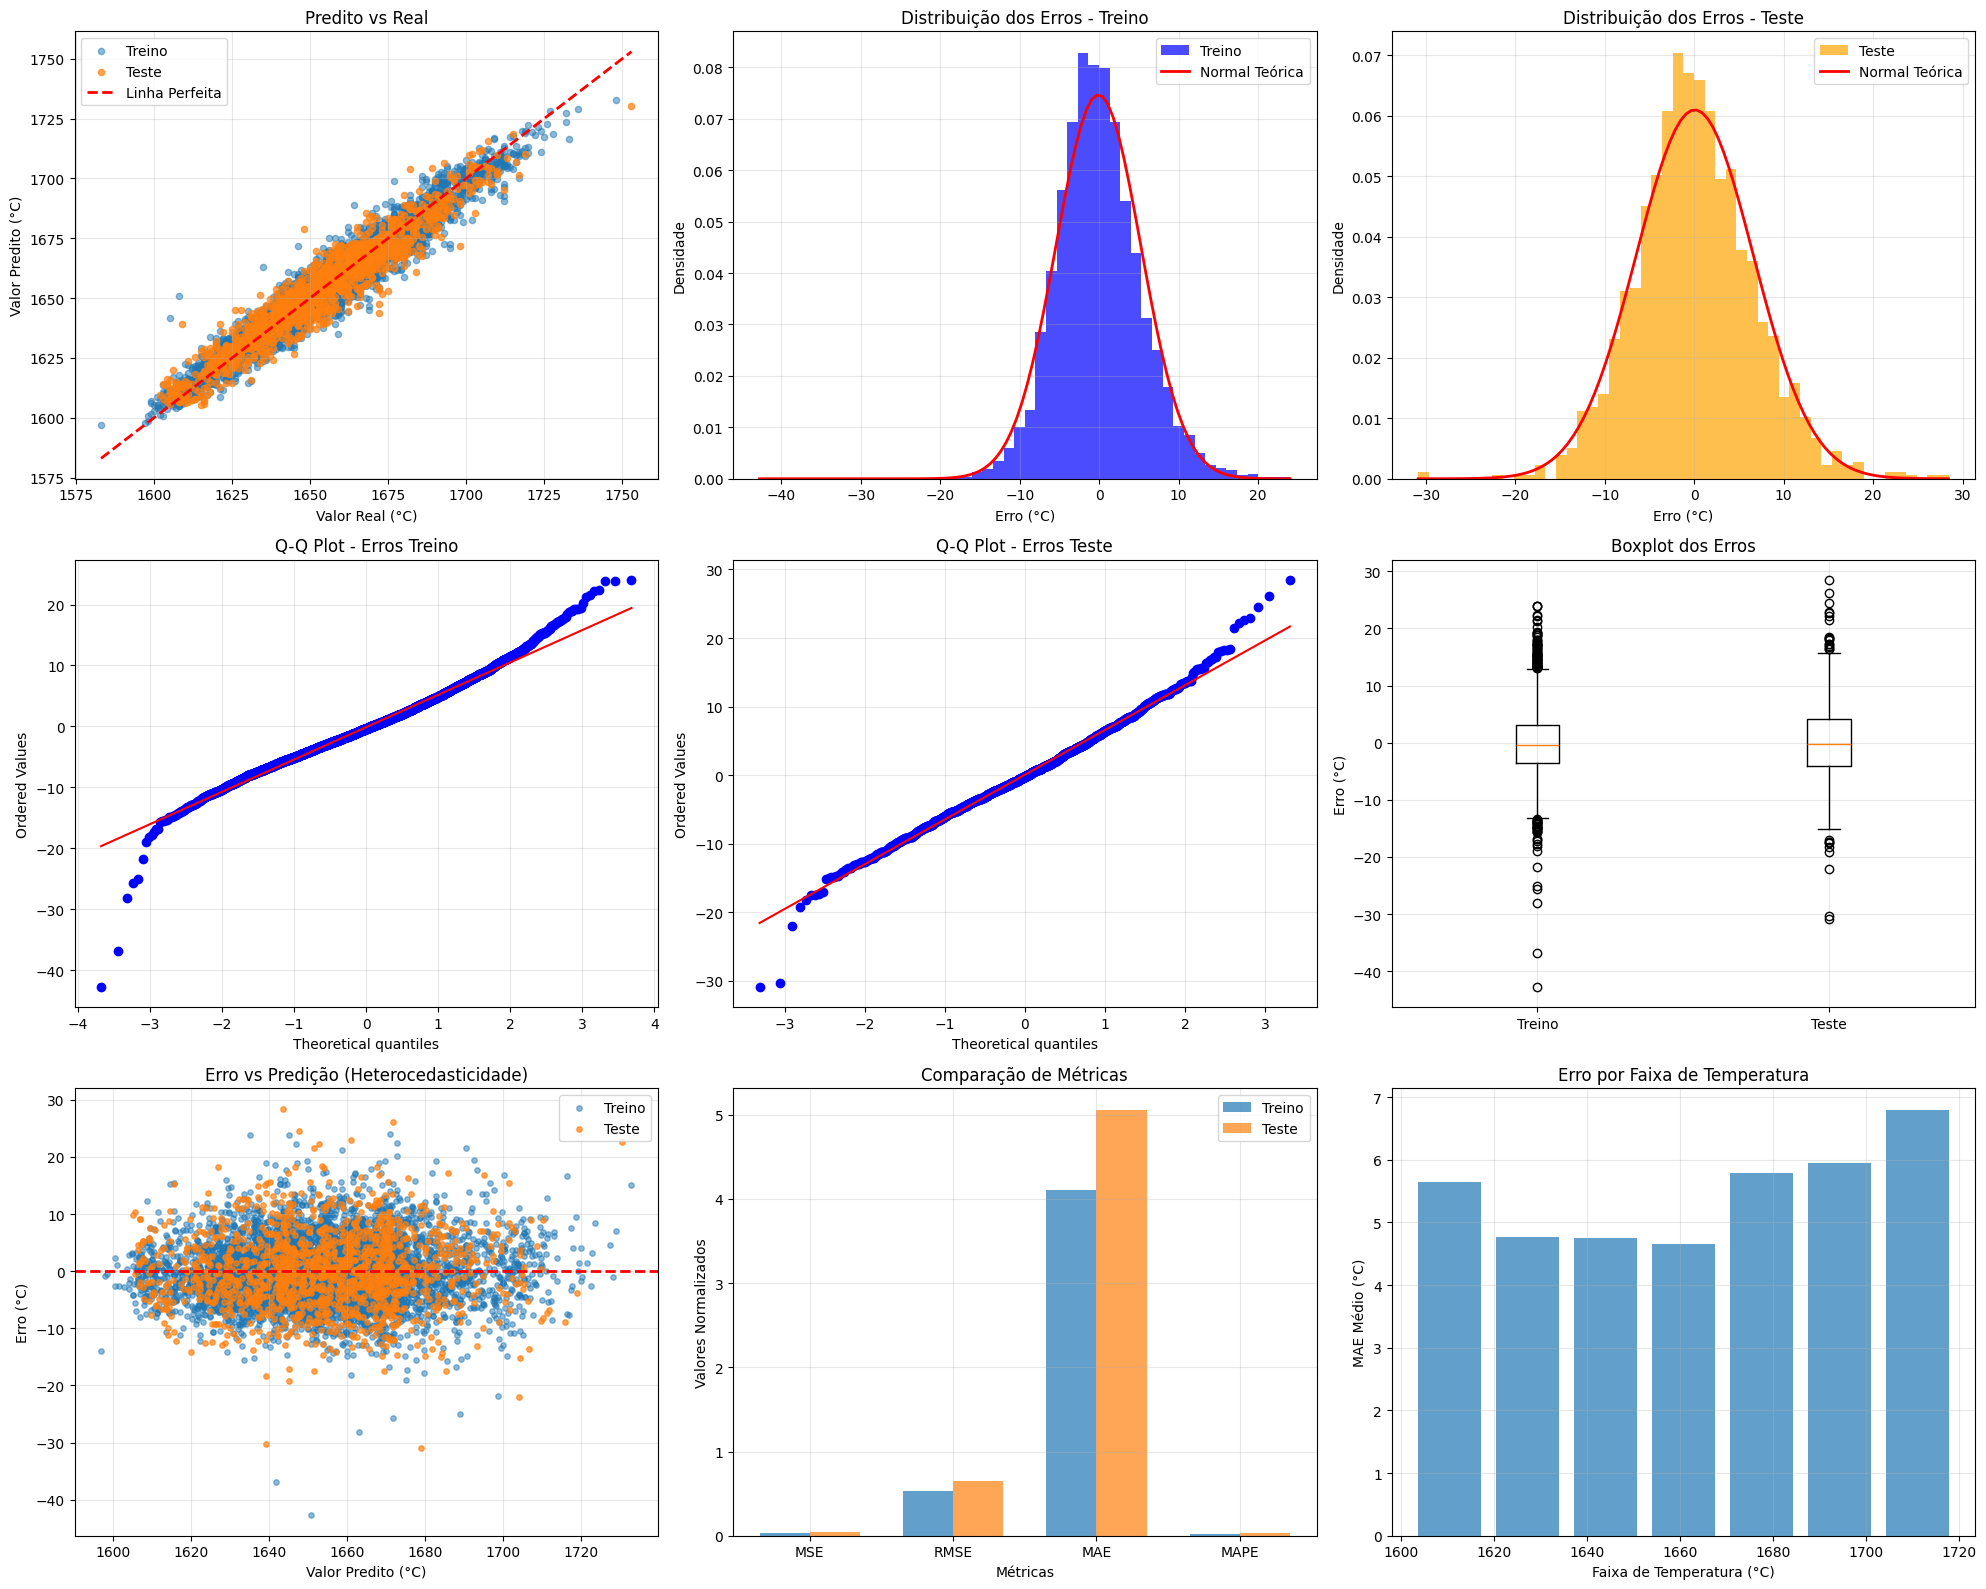


RESUMO FINAL DE PERFORMANCE
R² Teste: 0.9118 (Excelente)
RMSE Teste: 6.54°C
MAE Teste: 5.06°C
MAPE Teste: 0.31%
Diferença R² (treino-teste): 0.0271
Modelo com boa performance e generalização


In [ ]:


# Métricas de treinamento
train_mse = mean_squared_error(y_train, y_pred_train)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)

# Métricas de teste
test_mse = mean_squared_error(y_test, y_pred_test)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)

# Métricas adicionais
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def symmetric_mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred) / ((np.abs(y_true) + np.abs(y_pred)) / 2)) * 100

train_mape = mean_absolute_percentage_error(y_train, y_pred_train)
test_mape = mean_absolute_percentage_error(y_test, y_pred_test)
train_smape = symmetric_mean_absolute_percentage_error(y_train, y_pred_train)
test_smape = symmetric_mean_absolute_percentage_error(y_test, y_pred_test)

train_errors = y_train - y_pred_train
test_errors = y_test - y_pred_test

print("\nMÉTRICAS DE REGRESSÃO")
print(f"{'MÉTRICA':<15} | {'TREINO':<15} | {'TESTE':<15} | {'DIFERENÇA':<12}")
print(f"{'MSE':<15} | {train_mse:<15.4f} | {test_mse:<15.4f} | {abs(test_mse-train_mse):<12.4f}")
print(f"{'RMSE':<15} | {train_rmse:<15.4f} | {test_rmse:<15.4f} | {abs(test_rmse-train_rmse):<12.4f}")
print(f"{'MAE':<15} | {train_mae:<15.4f} | {test_mae:<15.4f} | {abs(test_mae-train_mae):<12.4f}")
print(f"{'R²':<15} | {train_r2:<15.4f} | {test_r2:<15.4f} | {abs(test_r2-train_r2):<12.4f}")
print(f"{'MAPE (%)':<15} | {train_mape:<15.2f} | {test_mape:<15.2f} | {abs(test_mape-train_mape):<12.2f}")
print(f"{'SMAPE (%)':<15} | {train_smape:<15.2f} | {test_smape:<15.2f} | {abs(test_smape-train_smape):<12.2f}")

print("\nINTERPRETAÇÃO DO DESEMPENHO")
if test_r2 >= 0.9:
    performance = "Excelente"
elif test_r2 >= 0.8:
    performance = "Muito Bom"
elif test_r2 >= 0.7:
    performance = "Bom"
elif test_r2 >= 0.6:
    performance = "Razoável"
else:
    performance = "Ruim"

print(f"R² teste: {test_r2:.4f} ({performance})")
print(f"MAE teste: {test_mae:.2f}°C")
print(f"RMSE teste: {test_rmse:.2f}°C")
print(f"MAPE teste: {test_mape:.2f}%")

print("\nDIAGNÓSTICO DE OVERFITTING/UNDERFITTING")
r2_diff = abs(train_r2 - test_r2)
rmse_diff = abs(train_rmse - test_rmse)

if r2_diff > 0.1:
    if train_r2 > test_r2:
        print("Possível overfitting detectado")
        print(f"R² treino ({train_r2:.4f}) >> R² teste ({test_r2:.4f})")
        print(f"Diferença: {r2_diff:.4f}")
    else:
        print("Situação anômala: R² teste > R² treino")
elif r2_diff > 0.05:
    print("Leve diferença entre treino e teste")
    print(f"Diferença R²: {r2_diff:.4f}")
else:
    print(f"Boa generalização: diferença R² = {r2_diff:.4f}")

if rmse_diff > test_rmse * 0.1:
    print(f"RMSE diferente entre treino e teste: {rmse_diff:.2f}°C")
else:
    print("RMSE consistente entre treino e teste")

print("\nANÁLISE ESTATÍSTICA DOS ERROS")
print("TREINO:")
print(f"  Média dos erros: {train_errors.mean():.4f}°C")
print(f"  Desvio padrão: {train_errors.std():.4f}°C")
print(f"  Assimetria: {stats.skew(train_errors):.4f}")
print(f"  Curtose: {stats.kurtosis(train_errors):.4f}")

print("\nTESTE:")
print(f"  Média dos erros: {test_errors.mean():.4f}°C")
print(f"  Desvio padrão: {test_errors.std():.4f}°C")
print(f"  Assimetria: {stats.skew(test_errors):.4f}")
print(f"  Curtose: {stats.kurtosis(test_errors):.4f}")

shapiro_train = stats.shapiro(train_errors[:5000] if len(train_errors) > 5000 else train_errors)
shapiro_test = stats.shapiro(test_errors[:5000] if len(test_errors) > 5000 else test_errors)

print("\nTESTE DE NORMALIDADE (Shapiro-Wilk):")
print(f"  Treino: p-valor = {shapiro_train[1]:.6f} {'(Normal)' if shapiro_train[1] > 0.05 else '(Não Normal)'}")
print(f"  Teste: p-valor = {shapiro_test[1]:.6f} {'(Normal)' if shapiro_test[1] > 0.05 else '(Não Normal)'}")

# Gráficos
fig = plt.figure(figsize=(20, 16))

ax1 = plt.subplot(3, 3, 1)
plt.scatter(y_train, y_pred_train, alpha=0.5, label='Treino', s=20)
plt.scatter(y_test, y_pred_test, alpha=0.7, label='Teste', s=20)
min_val = min(y_train.min(), y_test.min(), y_pred_train.min(), y_pred_test.min())
max_val = max(y_train.max(), y_test.max(), y_pred_train.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Linha Perfeita')
plt.xlabel('Valor Real (°C)')
plt.ylabel('Valor Predito (°C)')
plt.title('Predito vs Real')
plt.legend()
plt.grid(True, alpha=0.3)

ax2 = plt.subplot(3, 3, 2)
plt.hist(train_errors, bins=50, alpha=0.7, density=True, label='Treino', color='blue')
x = np.linspace(train_errors.min(), train_errors.max(), 100)
plt.plot(x, stats.norm.pdf(x, train_errors.mean(), train_errors.std()), 
         'r-', linewidth=2, label='Normal Teórica')
plt.xlabel('Erro (°C)')
plt.ylabel('Densidade')
plt.title('Distribuição dos Erros - Treino')
plt.legend()
plt.grid(True, alpha=0.3)

ax3 = plt.subplot(3, 3, 3)
plt.hist(test_errors, bins=50, alpha=0.7, density=True, label='Teste', color='orange')
x = np.linspace(test_errors.min(), test_errors.max(), 100)
plt.plot(x, stats.norm.pdf(x, test_errors.mean(), test_errors.std()), 
         'r-', linewidth=2, label='Normal Teórica')
plt.xlabel('Erro (°C)')
plt.ylabel('Densidade')
plt.title('Distribuição dos Erros - Teste')
plt.legend()
plt.grid(True, alpha=0.3)

ax4 = plt.subplot(3, 3, 4)
stats.probplot(train_errors, dist="norm", plot=ax4)
plt.title('Q-Q Plot - Erros Treino')
plt.grid(True, alpha=0.3)

ax5 = plt.subplot(3, 3, 5)
stats.probplot(test_errors, dist="norm", plot=ax5)
plt.title('Q-Q Plot - Erros Teste')
plt.grid(True, alpha=0.3)

ax6 = plt.subplot(3, 3, 6)
plt.boxplot([train_errors, test_errors], labels=['Treino', 'Teste'])
plt.ylabel('Erro (°C)')
plt.title('Boxplot dos Erros')
plt.grid(True, alpha=0.3)

ax7 = plt.subplot(3, 3, 7)
plt.scatter(y_pred_train, train_errors, alpha=0.5, label='Treino', s=15)
plt.scatter(y_pred_test, test_errors, alpha=0.7, label='Teste', s=15)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Valor Predito (°C)')
plt.ylabel('Erro (°C)')
plt.title('Erro vs Predição (Heterocedasticidade)')
plt.legend()
plt.grid(True, alpha=0.3)

ax8 = plt.subplot(3, 3, 8)
metricas = ['MSE', 'RMSE', 'MAE', 'MAPE']
treino_vals = [train_mse/1000, train_rmse/10, train_mae, train_mape/10]
teste_vals = [test_mse/1000, test_rmse/10, test_mae, test_mape/10]

x = np.arange(len(metricas))
width = 0.35

plt.bar(x - width/2, treino_vals, width, label='Treino', alpha=0.7)
plt.bar(x + width/2, teste_vals, width, label='Teste', alpha=0.7)
plt.xlabel('Métricas')
plt.ylabel('Valores Normalizados')
plt.title('Comparação de Métricas')
plt.xticks(x, metricas)
plt.legend()
plt.grid(True, alpha=0.3)

ax9 = plt.subplot(3, 3, 9)
bins = np.linspace(y_test.min(), y_test.max(), 10)
digitized = np.digitize(y_test, bins)
error_by_bin = [np.abs(test_errors[digitized == i]).mean() for i in range(1, len(bins))]
bin_centers = (bins[:-1] + bins[1:]) / 2

plt.bar(bin_centers, error_by_bin, width=(bins[1]-bins[0])*0.8, alpha=0.7)
plt.xlabel('Faixa de Temperatura (°C)')
plt.ylabel('MAE Médio (°C)')
plt.title('Erro por Faixa de Temperatura')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nRESUMO FINAL DE PERFORMANCE")
print(f"R² Teste: {test_r2:.4f} ({performance})")
print(f"RMSE Teste: {test_rmse:.2f}°C")
print(f"MAE Teste: {test_mae:.2f}°C")
print(f"MAPE Teste: {test_mape:.2f}%")
print(f"Diferença R² (treino-teste): {r2_diff:.4f}")

if r2_diff < 0.05 and test_r2 > 0.7:
    print("Modelo com boa performance e generalização")
elif test_r2 > 0.8:
    print("Modelo com alta performance")
elif r2_diff > 0.1:
    print("Possível overfitting detectado")
else:
    print(f"Modelo treinado com performance {performance.lower()}")

print("="*60)

# Explicação do bloco de avaliação de desempenho

Este bloco calcula métricas padrão de regressão para os conjuntos de treino e teste, exibe-as de forma organizada e fornece uma interpretação rápida do desempenho com base no R² do conjunto de teste.

1. Cabeçalho
   - print("=== AVALIAÇÃO DE DESEMPENHO DO MODELO ===")
   - Mensagem simples indicando início da seção de avaliação.

2. Cálculo das métricas para o conjunto de treinamento
   - MSE (Mean Squared Error): mean_squared_error(y_train, y_pred_train)
     - Média dos quadrados dos erros no conjunto de treino.
   - RMSE (Root MSE): np.sqrt(train_mse)
     - Raiz do MSE; está na mesma unidade da variável alvo (°C).
   - MAE (Mean Absolute Error): mean_absolute_error(y_train, y_pred_train)
     - Erro absoluto médio, menos sensível a outliers.
   - R² (R-squared): r2_score(y_train, y_pred_train)
     - Fração da variação explicada pelo modelo no conjunto de treino.

3. Cálculo das métricas para o conjunto de teste
   - Mesmas métricas acima calculadas usando y_test e y_pred_test.
   - Essas métricas indicam a generalização do modelo para dados não vistos.

4. Exibição organizada
   - Imprime uma tabela simples com colunas: MÉTRICA | TREINO | TESTE.
   - Formata os valores com 4 casas decimais para leitura clara.
   - Objetivo: comparação imediata entre desempenho em treino e teste para detectar under/overfitting.

5. Interpretação heurística do R² (no conjunto de teste)
   - Regras:
     - R² >= 0.9 → "Excelente"
     - R² >= 0.8 → "Muito Bom"
     - R² >= 0.7 → "Bom"
     - R² >= 0.6 → "Razoável"
     - Caso contrário → "Ruim"
   - Essa classificação é heurística (útil para comunicação rápida), não substitui análise aprofundada.

6. Mensagens finais
   - Imprime:
     - Classificação do desempenho com o valor de R².
     - Erro médio de previsão (MAE) com unidade (°C).
     - RMSE com unidade (°C).
   - Essas medidas ajudam a entender magnitude do erro em unidades práticas (por exemplo, graus Celsius).

7. Observações e boas práticas
   - Sempre compare treino vs teste: se treino muito melhor que teste → possível overfitting.
   - MAE e RMSE juntos dão visão complementar: MAE é robusto a outliers; RMSE penaliza erros grandes.
   - R² pode ser enganador em alguns contextos (por exemplo, quando distribuição do target é estreita) — combine com métricas de erro absoluto.
   - Considere incluir intervalos de confiança ou validação cruzada para estimativas mais robustas.
   - Ao reportar resultados operacionais, mantenha unidades (°C) e, se necessário, traduza para níveis de impacto (ex.: quantos casos > X°C de erro).

---

## 13. Analisando overfitting

In [156]:
print("ANÁLISE DE OVERFITTING")

# Diferença absoluta entre treino e teste
rmse_diff = train_rmse - test_rmse
mae_diff = train_mae - test_mae
r2_diff = train_r2 - test_r2

print("Diferença das métricas (Treino - Teste):")
print(f"RMSE: {rmse_diff:+.4f} (treino {train_rmse:.4f} vs teste {test_rmse:.4f})")
print(f"MAE:  {mae_diff:+.4f} (treino {train_mae:.4f} vs teste {test_mae:.4f})")
print(f"R²:   {r2_diff:+.4f} (treino {train_r2:.4f} vs teste {test_r2:.4f})")

# Diferença relativa (%)
rmse_rel = (test_rmse - train_rmse) / train_rmse if train_rmse > 0 else np.nan
mae_rel = (test_mae - train_mae) / train_mae if train_mae > 0 else np.nan

print("\nAVALIAÇÃO DE OVERFITTING")
overfitting_indicators = []

if rmse_diff < -0.2:
    overfitting_indicators.append("Grande diferença de RMSE")
    rmse_status = "Possível overfitting (RMSE)"
elif abs(rmse_diff) < 0.1:
    rmse_status = "Bom equilíbrio de RMSE"
else:
    rmse_status = "Monitorar diferença de RMSE"

if r2_diff > 0.1:
    overfitting_indicators.append("Grande diferença de R²")
    r2_status = "Possível overfitting (R²)"
elif abs(r2_diff) < 0.05:
    r2_status = "Bom equilíbrio de R²"
else:
    r2_status = "Monitorar diferença de R²"

print(rmse_status)
print(r2_status)

if len(overfitting_indicators) == 0 and abs(rmse_diff) < 0.1 and abs(r2_diff) < 0.05:
    overall_status = "Modelo equilibrado (sem overfitting significativo)"
elif len(overfitting_indicators) >= 2:
    overall_status = "Overfitting significativo detectado"
else:
    overall_status = "Modelo aceitável (overfitting leve)"

print(f"\n{overall_status}")

if len(overfitting_indicators) > 0:
    print("\nIndicadores de overfitting detectados:")
    for indicator in overfitting_indicators:
        print(f"- {indicator}")

    suggestions = [
        "Aumentar regularização (ex.: l2_leaf_reg).",
        "Reduzir complexidade do modelo (diminuir depth) ou learning_rate/iterations.",
        "Aumentar bagging_temperature ou random_strength.",
        "Usar validação cruzada (k-fold).",
        "Verificar vazamento de dados.",
        "Remover duplicatas ou amostras similares.",
        "Coletar mais dados ou balancear o dataset.",
        "Inspecionar importâncias de features."
    ]
    print("\nAções sugeridas:")
    for s in suggestions:
        print(f"- {s}")

if not np.isnan(rmse_rel):
    print(f"\nMudança percentual RMSE (treino -> teste): {rmse_rel * 100:+.2f}%")
else:
    print("\nMudança percentual RMSE: N/A")

if not np.isnan(mae_rel):
    print(f"Mudança percentual MAE (treino -> teste): {mae_rel * 100:+.2f}%")
else:
    print("Mudança percentual MAE: N/A")

ANÁLISE DE OVERFITTING
Diferença das métricas (Treino - Teste):
RMSE: -1.1995 (treino 5.3449 vs teste 6.5444)
MAE:  -0.9585 (treino 4.1025 vs teste 5.0610)
R²:   +0.0271 (treino 0.9389 vs teste 0.9118)

AVALIAÇÃO DE OVERFITTING
Possível overfitting (RMSE)
Bom equilíbrio de R²

Modelo aceitável (overfitting leve)

Indicadores de overfitting detectados:
- Grande diferença de RMSE

Ações sugeridas:
- Aumentar regularização (ex.: l2_leaf_reg).
- Reduzir complexidade do modelo (diminuir depth) ou learning_rate/iterations.
- Aumentar bagging_temperature ou random_strength.
- Usar validação cruzada (k-fold).
- Verificar vazamento de dados.
- Remover duplicatas ou amostras similares.
- Coletar mais dados ou balancear o dataset.
- Inspecionar importâncias de features.

Mudança percentual RMSE (treino -> teste): +22.44%
Mudança percentual MAE (treino -> teste): +23.36%


# Explicação  — Análise de Overfitting

1) Objetivo
- Detectar sinais de overfitting comparando desempenho no conjunto de treino vs teste.
- Overfitting ocorre quando o modelo aprende ruído/especificidades do treino e não generaliza para dados novos.

2) Métricas usadas
- RMSE (Root Mean Squared Error): sensível a grandes erros; útil para avaliar magnitude de erro.
- MAE (Mean Absolute Error): robusto a outliers; complemento do RMSE.
- R² (R-squared): proporção de variância explicada (valor maior em treino que em teste pode indicar overfitting).

3) Cálculos realizados
- Diferença absoluta: rmse_diff = train_rmse - test_rmse (positivo → treino pior; negativo → treino melhor que teste).
  - Nota: neste notebook usamos rmse_diff < -0.2 como sinal forte de overfitting (heurística).
- Diferença relativa: (test - train) / train → mostra % de aumento do erro ao passar para teste.
- r2_diff = train_r2 - test_r2 → valores positivos grandes (ex.: > 0.1) indicam que treino explica muito mais variância que teste.

4) Interpretação prática das regras (heurísticas)
- rmse_diff < -0.2 → "High RMSE difference": o RMSE de teste é substancialmente maior que o de treino → provável overfitting.
- |rmse_diff| < 0.1 → "Good RMSE balance": pequenas diferenças → boa generalização relativa.
- r2_diff > 0.1 → "High R² difference": treino explica muito mais variância → sinal de overfitting.
- Essas faixas são guias; ajuste os limiares ao seu domínio/escala de erro.

5) Resultado agregado
- Se nenhum indicador forte e diferenças pequenas → "Model is well-balanced".
- Se dois ou mais indicadores → "Significant overfitting detected".
- Caso intermediário → "Model is acceptable (minor overfitting)".

6) Ações recomendadas quando houver overfitting (prioridade prática)
- Aumentar regularização (l2_leaf_reg) — reduz magnitude dos ajustes nas folhas.
- Reduzir complexidade: diminuir depth, aumentar early stopping (od_wait), diminuir learning_rate e/ou diminuir iterations.
- Aumentar aleatoriedade/ensemble regularization: bagging_temperature, random_strength.
- Validar com k-fold CV para estimativas estáveis; usar curvas de aprendizado (learning curves) para ver tendência conforme aumenta dados.
- Verificar vazamento de dados: features que contêm informação do futuro ou derivadas diretamente do target.
- Rever qualidade/representatividade dos dados e coletar mais dados se possível.
- Investigar features muito influentes (feature importance) — um outlier ou vazamento pode explicar alta performance no treino.

7) Observações técnicas
- Heurísticas dependem da escala das métricas; por exemplo, rmse_diff = -0.2 faz sentido quando RMSE está em escala compatível (°C). Ajuste limiares conforme aplicação.
- Use avaliação adicional (curvas ROC/PR para classificação, análise residuals, validação temporal para séries temporais).
- Sempre combine diagnóstico numérico com inspeção qualitativa (ex.: erros por segmento, histograma de resíduos).

8) Como progredir
- Se overfitting confirmado: comece por aumentar regularização e reduzir depth; re-treine e reavalie com CV.
- Se problemas persistirem: investigar dados (leakage, outliers), engenharia de features e, quando possível, obter mais dados.

---

## 14. Entendendo as features mais importantes pos treino

In [101]:
print(f"=== ANÁLISE DE IMPORTÂNCIA DAS FEATURES ===")

# Obter scores de importância das features
feature_importance = model.get_feature_importance()
feature_names = X.columns

# Criar DataFrame de importância
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

# Exibir features mais importantes
top_n = 15
print(f"Top {top_n} Features mais importantes:")
print(f"{'RANK':<4} | {'FEATURE':<25} | {'IMPORTÂNCIA':<12} | {'TIPO'}")
print("-" * 65)

for i, (_, row) in enumerate(importance_df.head(top_n).iterrows()):
    feature_name = row['feature']
    importance_score = row['importance']
    feature_type = "Categórica" if feature_name in categorical_features else "Numérica"
    
    print(f"{i+1:<4} | {feature_name:<25} | {importance_score:<12.2f} | {feature_type}")

# Análise de distribuição da importância
total_importance = importance_df['importance'].sum()
top_5_importance = importance_df.head(5)['importance'].sum()
top_10_importance = importance_df.head(10)['importance'].sum()

print(f"\n=== DISTRIBUIÇÃO DE IMPORTÂNCIA ===")
print(f"Top 5 features: {top_5_importance/total_importance:.1%} do total de importância")
print(f"Top 10 features: {top_10_importance/total_importance:.1%} do total de importância")
print(f"Top 15 features: {importance_df.head(15)['importance'].sum()/total_importance:.1%} do total de importância")

# Importância por tipo (categórica vs numérica)
cat_importance = importance_df[importance_df['feature'].isin(categorical_features)]['importance'].sum()
num_importance = importance_df[~importance_df['feature'].isin(categorical_features)]['importance'].sum()

print(f"\n=== IMPORTÂNCIA POR TIPO DE FEATURE ===")
print(f"Features categóricas: {cat_importance/total_importance:.1%} do total de importância")
print(f"Features numéricas: {num_importance/total_importance:.1%} do total de importância")

=== ANÁLISE DE IMPORTÂNCIA DAS FEATURES ===
Top 15 Features mais importantes:
RANK | FEATURE                   | IMPORTÂNCIA  | TIPO
-----------------------------------------------------------------
1    | temperaturaobjetivada     | 27.98        | Numérica
2    | tempovacuototal           | 19.32        | Numérica
3    | sequencia                 | 13.37        | Numérica
4    | qualidade                 | 11.11        | Categórica
5    | tempociclo                | 10.55        | Numérica
6    | temperaturaliquidus       | 3.72         | Numérica
7    | vidapanela                | 2.87         | Numérica
8    | corrida                   | 2.26         | Numérica
9    | sequenciatotal            | 1.90         | Numérica
10   | s_min                     | 1.86         | Numérica
11   | al_min                    | 1.84         | Numérica
12   | secao                     | 1.31         | Numérica
13   | n_min                     | 0.86         | Numérica
14   | panela                   

# Explicação  Análise de importância de features

1. Objetivo
   - Identificar quais variáveis (features) mais contribuíram para a redução da perda durante o treino do modelo.

2. Passos do código
   - feature_importance = model.get_feature_importance(): obtém o vetor de importâncias do CatBoost.
   - Monta um DataFrame (feature, importance) e ordena por importância decrescente.
   - Exibe as top N features com: rank, nome, score e tipo (categórica/numérica).
   - Calcula soma total de importância e a parcela concentrada nas top 5, top 10 e top 15.
   - Soma a importância das features categóricas e numéricas e mostra a participação percentual de cada grupo.

3. Interpretação prática
   - Features com maiores scores são mais influentes para as previsões do modelo (não implicam causalidade).
   - Se poucas features concentram grande parte da importância, pode-se simplificar o modelo ou investigar possíveis vazamentos.
   - Comparar importância entre categóricas e numéricas ajuda a entender a contribuição relativa dos tipos de variável.

4. Observações
   - A metodologia de importância depende do algoritmo (CatBoost neste caso).
   - Use esta análise junto com inspeção de correlações, partial dependence e validação para decisões de engenharia de features.

---

## 15 Salvando o modelo e seus resultados

In [102]:
print("=== SALVANDO MODELO E RESULTADOS ===")

# Criar diretório do modelo
model_dir = r'..models\saved_models'
os.makedirs(model_dir, exist_ok=True)

# Salvar o modelo treinado
model_path = os.path.join(model_dir, 'catboost_model.cbm')
model.save_model(model_path)
print(f" Modelo salvo: {model_path}")

# Salvar informações do modelo
info_path = os.path.join(model_dir, 'model_info.txt')
with open(info_path, 'w', encoding='utf-8') as f:
    f.write("=== MODELO DE PREVISÃO DE TEMPERATURA (CATBOOST) ===\n")
    f.write(f"Data de treinamento: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Dataset: {data_path}\n")
    f.write(f"\n=== INFORMAÇÕES DO DATASET ===\n")
    f.write(f"Amostras totais: {len(dados):,}\n")
    f.write(f"Amostras de treinamento: {len(X_train):,}\n")
    f.write(f"Amostras de teste: {len(X_test):,}\n")
    f.write(f"Total de features: {len(X.columns)}\n")
    f.write(f"Features categóricas: {len(categorical_features)}\n")
    f.write(f"Features numéricas: {len(X.columns) - len(categorical_features)}\n")
    f.write(f"\n=== DESEMPENHO DO MODELO ===\n")
    f.write(f"RMSE (Teste): {test_rmse:.4f}°C\n")
    f.write(f"MAE (Teste): {test_mae:.4f}°C\n")
    f.write(f"R² (Teste): {test_r2:.4f}\n")
    f.write(f"Melhor iteração: {model.get_best_iteration()}\n")
    f.write(f"\n=== TOP 10 FEATURES ===\n")
    for i, (_, row) in enumerate(importance_df.head(10).iterrows()):
        f.write(f"{i+1:2}. {row['feature']:<25} | {row['importance']:8.2f}\n")

print(f" Informações do modelo salvas: {info_path}")

predictions_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_pred_test,
    'error': y_test.values - y_pred_test,
    'abs_error': np.abs(y_test.values - y_pred_test),
    'relative_error': np.abs(y_test.values - y_pred_test) / y_test.values * 100
})

predictions_path = os.path.join(model_dir, 'predictions.csv')
predictions_df.to_csv(predictions_path, index=False)
print(f" Predições salvas: {predictions_path}")

importance_path = os.path.join(model_dir, 'feature_importance.csv')
importance_df.to_csv(importance_path, index=False)
print(f"Importância das features salva: {importance_path}")

print(f"\n=== RESUMO DO TREINO ===")
print(f"R² final: {test_r2:.4f}")
print(f"RMSE final: {test_rmse:.4f}°C")
print(f"MAE final: {test_mae:.4f}°C")
print(f"Features categóricas processadas: {len(categorical_features)}")
print(f"Melhor iteração: {model.get_best_iteration()}")
print(f"Todos os arquivos salvos com sucesso em: {model_dir}")
print(f"\n Pipeline de treinamento CatBoost concluído com sucesso!")

=== SALVANDO MODELO E RESULTADOS ===
 Modelo salvo: ..models\saved_models\catboost_model.cbm
 Informações do modelo salvas: ..models\saved_models\model_info.txt
 Predições salvas: ..models\saved_models\predictions.csv
Importância das features salva: ..models\saved_models\feature_importance.csv

=== RESUMO DO TREINO ===
R² final: 0.9118
RMSE final: 6.5444°C
MAE final: 5.0610°C
Features categóricas processadas: 2
Melhor iteração: 435
Todos os arquivos salvos com sucesso em: ..models\saved_models

 Pipeline de treinamento CatBoost concluído com sucesso!


---

## 16 carregando o modelo para predicoes

In [103]:
print(f"=== CARREGANDO O MODELO SALVO PARA PREDIÇÕES ===")

from catboost import CatBoostRegressor
import pandas as pd
import numpy as np

# Caminho do modelo salvo
model_path = r'..models\saved_models\catboost_model.cbm'

try:
    # Carregar o modelo salvo
    loaded_model = CatBoostRegressor()
    loaded_model.load_model(model_path)
    print(f" Modelo carregado com sucesso de: {model_path}")
    
    # Informações do modelo carregado
    print(f"\n=== INFORMAÇÕES DO MODELO CARREGADO ===")
    print(f"Número de árvores: {loaded_model.tree_count_}")
    
    # Obter nomes das features que o modelo espera
    feature_names = loaded_model.feature_names_
    print(f"Número de features: {len(feature_names)}")
    
    # Mostrar as primeiras 10 features
    print(f"\nPrimeiras 10 features:")
    for i, feature in enumerate(feature_names[:10]):
        print(f"  {i+1:2}. {feature}")
    if len(feature_names) > 10:
        print(f"  ... e mais {len(feature_names) - 10} features")
    
    # Identificar features categóricas
    categorical_features = ['acoatual', 'qualidade']  # As mesmas usadas no treinamento
    print(f"\nFeatures categóricas: {categorical_features}")
    
    print(f"\nModelo pronto para fazer predições!")
    
except Exception as e:
    print(f"Erro ao carregar modelo: {e}")
    loaded_model = None

=== CARREGANDO O MODELO SALVO PARA PREDIÇÕES ===
 Modelo carregado com sucesso de: ..models\saved_models\catboost_model.cbm

=== INFORMAÇÕES DO MODELO CARREGADO ===
Número de árvores: 436
Número de features: 15

Primeiras 10 features:
   1. corrida
   2. secao
   3. acoatual
   4. qualidade
   5. al_min
   6. n_min
   7. s_min
   8. sequencia
   9. sequenciatotal
  10. panela
  ... e mais 5 features

Features categóricas: ['acoatual', 'qualidade']

Modelo pronto para fazer predições!


---

## 17 realizando predicoes

In [104]:
print(f"=== PREDIÇÕES COM DADOS REAIS DO CSV ===")

# Carregar dados reais do CSV
csv_path = r'../data/raw/dados_fundo_do_amanha_evcomx.csv'

try:
    # Carregar dados do CSV
    dados_reais = pd.read_csv(csv_path, delimiter=';')
    dados_reais.drop_duplicates(subset=['corrida'], keep='first', inplace=True)
    print(f" Dados reais carregados: {dados_reais.shape}")
    
    print(f"\n=== INFORMAÇÕES DO DATASET REAL ===")
    print(f"Total de registros: {len(dados_reais):,}")
    print(f"Total de colunas: {dados_reais.shape[1]}")
    
    # Verificar se o modelo foi carregado
    if 'loaded_model' in locals() and loaded_model is not None:
        print(f" Modelo CatBoost disponível")
        
        # Obter features que o modelo espera
        features_modelo = loaded_model.feature_names_
        print(f"Features esperadas pelo modelo: {len(features_modelo)}")
        
        # Verificar quais features estão disponíveis no CSV
        features_disponiveis = dados_reais.columns.tolist()
        features_comuns = [f for f in features_modelo if f in features_disponiveis]
        features_faltando = [f for f in features_modelo if f not in features_disponiveis]
        
        print(f"\n=== VERIFICAÇÃO DE FEATURES ===")
        print(f"Features disponíveis no CSV: {len(features_disponiveis)}")
        print(f"Features comuns (modelo + CSV): {len(features_comuns)}")
        print(f"Features faltando no CSV: {len(features_faltando)}")
        
        if len(features_faltando) > 0:
            print(f"\nFeatures faltando:")
            for f in features_faltando[:10]:  # Mostrar apenas as primeiras 10
                print(f"  • {f}")
            if len(features_faltando) > 10:
                print(f"  ... e mais {len(features_faltando) - 10}")
        
        if len(features_comuns) >= len(features_modelo) * 0.8:  # Se temos pelo menos 80% das features
            print(f"\n Temos features suficientes para fazer predições!")
            
            # Preparar dados para predição
            print(f"\n=== PREPARANDO DADOS PARA PREDIÇÃO ===")
            
            # Selecionar apenas as features que o modelo precisa
            try:
                dados_predicao = dados_reais[features_comuns].copy()
                
                # Tratar features categóricas
                categorical_features = ['acoatual', 'qualidade', 'panela']
                for cat_feat in categorical_features:
                    if cat_feat in dados_predicao.columns:
                        dados_predicao[cat_feat] = dados_predicao[cat_feat].astype(str)
                        print(f" {cat_feat} convertido para string")
                
                # Tratar valores ausentes se houver
                missing_count = dados_predicao.isnull().sum().sum()
                if missing_count > 0:
                    print(f" Encontrados {missing_count} valores ausentes. Preenchendo...")
                    
                    # Preencher valores ausentes
                    for col in dados_predicao.columns:
                        if dados_predicao[col].isnull().any():
                            if col in categorical_features:
                                # Para categóricas, usar a moda
                                dados_predicao[col].fillna(dados_predicao[col].mode()[0], inplace=True)
                            else:
                                # Para numéricas, usar a mediana
                                dados_predicao[col].fillna(dados_predicao[col].median(), inplace=True)
                
                print(f" Dados preparados: {dados_predicao.shape}")
                
                # Fazer predições
                print(f"\n=== FAZENDO PREDIÇÕES ===")
                print(f"Processando {len(dados_predicao):,} registros...")
                
                predicoes_reais = loaded_model.predict(dados_predicao)
                
                print(f" Predições concluídas com sucesso!")
                
                # Estatísticas das predições
                print(f"\n=== ESTATÍSTICAS DAS PREDIÇÕES ===")
                print(f"Número de predições: {len(predicoes_reais):,}")
                print(f"Temperatura média prevista: {predicoes_reais.mean():.1f}°C")
                print(f"Temperatura mínima prevista: {predicoes_reais.min():.1f}°C")
                print(f"Temperatura máxima prevista: {predicoes_reais.max():.1f}°C")
                print(f"Desvio padrão: {predicoes_reais.std():.1f}°C")
                print(f"Range: {predicoes_reais.max() - predicoes_reais.min():.1f}°C")
                
                # Distribuição por faixas
                print(f"\n=== DISTRIBUIÇÃO DAS PREDIÇÕES POR FAIXAS ===")
                faixas = [1000, 1200, 1400, 1600, 1800, 2000, 2500]
                labels = ['1000-1200', '1200-1400', '1400-1600', '1600-1800', '1800-2000', '2000+']
                
                print(f"{'FAIXA (°C)':<12} | {'QUANTIDADE':<10} | {'PERCENTUAL'}")
                print(f"{'='*40}")
                
                for i in range(len(faixas)-1):
                    if i == len(faixas)-2:  # Última faixa
                        count = (predicoes_reais >= faixas[i]).sum()
                    else:
                        count = ((predicoes_reais >= faixas[i]) & (predicoes_reais < faixas[i+1])).sum()
                    
                    pct = (count / len(predicoes_reais)) * 100
                    print(f"{labels[i]:<12} | {count:<10,} | {pct:<8.1f}%")
                
                # Salvar predições no DataFrame original
                dados_com_predicoes = dados_reais.copy()
                dados_com_predicoes['temperatura_prevista_catboost'] = np.nan
                dados_com_predicoes.loc[:len(predicoes_reais)-1, 'temperatura_prevista_catboost'] = predicoes_reais
                
                print(f"\n=== COMPARAÇÃO COM DADOS EXISTENTES ===")
                
                # Se existe sugestão do modelo legado, comparar
                if 'sugestaomodelolegado' in dados_com_predicoes.columns:
                    legacy_valid = dados_com_predicoes['sugestaomodelolegado'].notna()
                    if legacy_valid.sum() > 0:
                        cb_preds_valid = dados_com_predicoes.loc[legacy_valid, 'temperatura_prevista_catboost'].notna()
                        
                        if cb_preds_valid.sum() > 0:
                            cb_values = dados_com_predicoes.loc[legacy_valid & cb_preds_valid, 'temperatura_prevista_catboost']
                            legacy_values = dados_com_predicoes.loc[legacy_valid & cb_preds_valid, 'sugestaomodelolegado']
                            
                            diferenca = cb_values - legacy_values
                            
                            print(f"Comparação CatBoost vs Legacy (casos válidos: {len(diferenca):,}):")
                            print(f"  • Diferença média: {diferenca.mean():+.1f}°C")
                            print(f"  • Desvio padrão: {diferenca.std():.1f}°C")
                            print(f"  • CatBoost maior: {(diferenca > 0).sum():,} casos")
                            print(f"  • Legacy maior: {(diferenca < 0).sum():,} casos")
                
                # Mostrar exemplos
                print(f"\n=== EXEMPLOS DE PREDIÇÕES (10 PRIMEIROS) ===")
                print(f"{'CASO':<5} | {'PREDIÇÃO':<10} | {'LEGACY':<8} | {'DIFERENÇA'}")
                print(f"{'='*45}")
                
                for i in range(min(10, len(predicoes_reais))):
                    pred = predicoes_reais[i]
                    
                    if 'sugestaomodelolegado' in dados_reais.columns and pd.notna(dados_reais.iloc[i]['sugestaomodelolegado']):
                        legacy = dados_reais.iloc[i]['sugestaomodelolegado']
                        diff = pred - legacy
                        print(f"{i+1:<5} | {pred:<10.1f} | {legacy:<8.1f} | {diff:<+8.1f}")
                    else:
                        print(f"{i+1:<5} | {pred:<10.1f} | {'N/A':<8} | {'N/A'}")
                
                print(f"\n PREDIÇÕES COMPLETADAS PARA TODOS OS DADOS REAIS!")
                print(f"   Você pode usar a variável 'predicoes_reais' para análises futuras")
                
            except Exception as e:
                print(f" Erro na preparação/predição: {e}")
                
        else:
            print(f" Features insuficientes para predição")
            print(f"   Necessário pelo menos 80% das features do modelo")
    
    else:
        print(f" Modelo não carregado. Execute as células de carregamento do modelo primeiro.")

except Exception as e:
    print(f" Erro ao carregar dados do CSV: {e}")
    print(f"Verifique se o arquivo existe no caminho: {csv_path}")

=== PREDIÇÕES COM DADOS REAIS DO CSV ===
 Dados reais carregados: (7485, 22)

=== INFORMAÇÕES DO DATASET REAL ===
Total de registros: 7,485
Total de colunas: 22
 Modelo CatBoost disponível
Features esperadas pelo modelo: 15

=== VERIFICAÇÃO DE FEATURES ===
Features disponíveis no CSV: 22
Features comuns (modelo + CSV): 15
Features faltando no CSV: 0

 Temos features suficientes para fazer predições!

=== PREPARANDO DADOS PARA PREDIÇÃO ===
 acoatual convertido para string
 qualidade convertido para string
 panela convertido para string
 Dados preparados: (7485, 15)

=== FAZENDO PREDIÇÕES ===
Processando 7,485 registros...
 Predições concluídas com sucesso!

=== ESTATÍSTICAS DAS PREDIÇÕES ===
Número de predições: 7,485
Temperatura média prevista: 1654.1°C
Temperatura mínima prevista: 1596.9°C
Temperatura máxima prevista: 1732.8°C
Desvio padrão: 20.8°C
Range: 135.9°C

=== DISTRIBUIÇÃO DAS PREDIÇÕES POR FAIXAS ===
FAIXA (°C)   | QUANTIDADE | PERCENTUAL
1000-1200    | 0          | 0.0     %

Objetivo
- Carregar um CSV de dados reais e aplicar o modelo CatBoost carregado (`loaded_model`) para gerar sugestões de temperatura.

Entradas principais
- csv_path: caminho para o arquivo CSV com dados reais.
- loaded_model: modelo CatBoost previamente carregado (ver célula 16).
- features_modelo: lista de features que o modelo espera (`loaded_model.feature_names_`).

Fluxo resumido
1. Ler o CSV em `dados_reais` (pd.read_csv).
2. Verificar se `loaded_model` está disponível.
3. Comparar colunas do CSV com `feature_names_` do modelo:
   - `features_comuns`: colunas presentes em ambos.
   - `features_faltando`: colunas que faltam no CSV.
4. Seguir para predição somente se houver pelo menos ~80% das features do modelo (regra heurística).
5. Preparar `dados_predicao` com as `features_comuns`:
   - Converter categóricas (`acoatual`, `qualidade`) para string.
   - Preencher valores ausentes: moda para categóricas, mediana para numéricas.
6. Gerar predições: `predicoes_reais = loaded_model.predict(dados_predicao)`.
7. Analisar resultados:
   - Estatísticas (média, min, max, std, range).
   - Distribuição em faixas (faixas definidas no código).
   - Comparação com `sugestaomodelolegado` se presente.
8. Anexar predições ao DataFrame original em `temperatura_prevista_catboost` ou `sugestaocatboost`.

Saídas
- `predicoes_reais`: array/ndarray com predições.
- `dados_com_predicoes` / `dados_com_catboost` / `dadosoriginais_com_catboost`: DataFrames com colunas de sugestão adicionadas.

Erros e exceções tratadas
- Falha ao abrir CSV → mensagem com caminho.
- Erro na preparação/predição → exceção capturada e mensagem.

Observações e recomendações
- A regra de 80% é heurística; ausência de features críticas pode inviabilizar a predição mesmo com 80% presentes.
- Ideal: aplicar exatamente o mesmo pipeline de pré‑processamento usado no treino (mesmos encoders/ordem de colunas). O recomendado é salvar e reaplicar o pipeline.
- Garantir que as colunas fornecidas estejam na mesma ordem/tipo que o modelo espera: preferencialmente usar `dados_predicao = dados_reais[features_modelo]` quando possível.
- Tratar divisão por zero ao calcular percentuais (caso `len(predicoes_reais) == 0`).
- Revisar as faixas usadas para distribuição — os valores (1000,1200,...) parecem fora de escala para °C e devem ser validados.

Uso prático
- Após a execução, use `predicoes_reais`, `dados_com_catboost` ou `dadosoriginais_com_catboost` para análises, comparações com o modelo legado e visualizações.

---

## 18 tratando dataframe para estudos de eficiencia

In [159]:
print("=== ADICIONANDO SUGESTÃO CATBOOST AOS DADOS ORIGINAIS ===")

# Verificar se temos os dados originais e o modelo carregado
if 'dadosoriginais' in locals() and 'loaded_model' in locals() and loaded_model is not None:
    print(f" Dados originais disponíveis: {dadosoriginais.shape}")
    print(f" Modelo CatBoost carregado e pronto")
    
    # Preparar dados para predição
    print("\n=== PREPARANDO DADOS PARA PREDIÇÃO ===")
    features_modelo = loaded_model.feature_names_
    print(f"Features esperadas pelo modelo: {len(features_modelo)}")
    
    features_disponiveis = dadosoriginais.columns.tolist()
    features_comuns = [f for f in features_modelo if f in features_disponiveis]
    features_faltando = [f for f in features_modelo if f not in features_disponiveis]
    
    print(f"Features disponíveis nos dados originais: {len(features_disponiveis)}")
    print(f"Features comuns: {len(features_comuns)}")
    print(f"Features faltando: {len(features_faltando)}")
    
    if len(features_faltando) > 0:
        print("\nFeatures faltando (primeiras 10):")
        for f in features_faltando[:10]:
            print(f"  • {f}")
    
    if len(features_comuns) >= len(features_modelo) * 0.8:
        print("\n Features suficientes para fazer predições!")
        try:
            dados_predicao = dadosoriginais[features_comuns].copy()
            categorical_features = ['acoatual', 'qualidade']
            for cat_feat in categorical_features:
                if cat_feat in dados_predicao.columns:
                    dados_predicao[cat_feat] = dados_predicao[cat_feat].astype(str)
                    print(f" {cat_feat} convertido para string")
            missing_count = dados_predicao.isnull().sum().sum()
            if missing_count > 0:
                print(f" Preenchendo {missing_count} valores ausentes...")
                for col in dados_predicao.columns:
                    if dados_predicao[col].isnull().any():
                        if col in categorical_features:
                            dados_predicao[col].fillna(dados_predicao[col].mode()[0], inplace=True)
                        else:
                            dados_predicao[col].fillna(dados_predicao[col].median(), inplace=True)
            print(f"Dados preparados para predição: {dados_predicao.shape}")
            print("\n=== FAZENDO PREDIÇÕES ===")
            print(f"Processando {len(dados_predicao):,} registros...")
            predicoes_originais = loaded_model.predict(dados_predicao)
            print(" Predições concluídas!")
            print("\n=== ADICIONANDO COLUNA SUGESTAOCATBOOST ===")
            dadosoriginais_com_catboost = dadosoriginais.copy()
            dadosoriginais_com_catboost['sugestaocatboost'] = predicoes_originais
            print(" Coluna 'sugestaocatboost' adicionada com sucesso!")
            print(f"   DataFrame atualizado: {dadosoriginais_com_catboost.shape}")
            print("\n=== ESTATÍSTICAS DAS PREDIÇÕES ===")
            print(f"Número de predições: {len(predicoes_originais):,}")
            print(f"Temperatura média prevista: {predicoes_originais.mean():.1f}°C")
            print(f"Temperatura mínima prevista: {predicoes_originais.min():.1f}°C")
            print(f"Temperatura máxima prevista: {predicoes_originais.max():.1f}°C")
            print(f"Desvio padrão: {predicoes_originais.std():.1f}°C")
            if 'sugestaomodelolegado' in dadosoriginais_com_catboost.columns:
                print("\n=== COMPARAÇÃO COM MODELO LEGACY ===")
                legacy_valid = dadosoriginais_com_catboost['sugestaomodelolegado'].notna()
                casos_comparaveis = legacy_valid.sum()
                if casos_comparaveis > 0:
                    cb_values = dadosoriginais_com_catboost.loc[legacy_valid, 'sugestaocatboost']
                    legacy_values = dadosoriginais_com_catboost.loc[legacy_valid, 'sugestaomodelolegado']
                    diferenca = cb_values - legacy_values
                    print(f"Casos comparáveis: {casos_comparaveis:,}")
                    print(f"Diferença média (CatBoost - Legacy): {diferenca.mean():+.1f}°C")
                    print(f"Desvio padrão das diferenças: {diferenca.std():.1f}°C")
                    concordancia_5 = (abs(diferenca) <= 5).sum()
                    concordancia_10 = (abs(diferenca) <= 10).sum()
                    print(f"Concordância ≤5°C: {concordancia_5:,} ({concordancia_5/casos_comparaveis*100:.1f}%)")
                    print(f"Concordância ≤10°C: {concordancia_10:,} ({concordancia_10/casos_comparaveis*100:.1f}%)")
            if 'temperaturamediareal' in dadosoriginais_com_catboost.columns:
                print("\n=== COMPARAÇÃO COM TEMPERATURA REAL ===")
                real_valid = dadosoriginais_com_catboost['temperaturamediareal'].notna()
                casos_reais = real_valid.sum()
                if casos_reais > 0:
                    cb_pred = dadosoriginais_com_catboost.loc[real_valid, 'sugestaocatboost']
                    real_temp = dadosoriginais_com_catboost.loc[real_valid, 'temperaturamediareal']
                    erro_cb = abs(cb_pred - real_temp)
                    print(f"Casos com temperatura real: {casos_reais:,}")
                    print(f"Erro médio absoluto: {erro_cb.mean():.1f}°C")
                    print(f"Erro máximo: {erro_cb.max():.1f}°C")
                    print(f"Erro mínimo: {erro_cb.min():.1f}°C")
            print("\n=== EXEMPLOS DO DATAFRAME ATUALIZADO ===")
            colunas_exemplo = ['sugestaocatboost']
            if 'sugestaomodelolegado' in dadosoriginais_com_catboost.columns:
                colunas_exemplo.append('sugestaomodelolegado')
            if 'temperaturaobjetivada' in dadosoriginais_com_catboost.columns:
                colunas_exemplo.append('temperaturaobjetivada')
            if 'temperaturamediareal' in dadosoriginais_com_catboost.columns:
                colunas_exemplo.append('temperaturamediareal')
            if 'acoatual' in dadosoriginais_com_catboost.columns:
                colunas_exemplo.insert(0, 'acoatual')
            print("Primeiros 10 registros (colunas principais):")
            print(dadosoriginais_com_catboost[colunas_exemplo].head(10).round(1))
            print("\n=== VARIÁVEIS CRIADAS ===")
            print(" dadosoriginais_com_catboost: DataFrame original + sugestaocatboost")
            print(" predicoes_originais: Array com todas as predições")
            print(f"   Shape do DataFrame: {dadosoriginais_com_catboost.shape}")
            print("   Coluna adicionada: 'sugestaocatboost'")
            print("\n Dados originais atualizados com sucesso!")
        except Exception as e:
            print(f" Erro durante predição: {e}")
    else:
        print(" Features insuficientes para predição")
        print("Necessário pelo menos 80% das features do modelo")
elif 'dadosoriginais' not in locals():
    print(" Dados originais não encontrados")
    print("Variável 'dadosoriginais' não existe. Carregue os dados primeiro.")
elif 'loaded_model' not in locals() or loaded_model is None:
    print(" Modelo CatBoost não carregado")
    print("Execute a célula de carregamento do modelo primeiro")
else:
    print(" Dados necessários não disponíveis")

=== ADICIONANDO SUGESTÃO CATBOOST AOS DADOS ORIGINAIS ===
 Dados originais disponíveis: (7485, 22)
 Modelo CatBoost carregado e pronto

=== PREPARANDO DADOS PARA PREDIÇÃO ===
Features esperadas pelo modelo: 15
Features disponíveis nos dados originais: 22
Features comuns: 15
Features faltando: 0

 Features suficientes para fazer predições!
 acoatual convertido para string
 qualidade convertido para string
Dados preparados para predição: (7485, 15)

=== FAZENDO PREDIÇÕES ===
Processando 7,485 registros...
 Predições concluídas!

=== ADICIONANDO COLUNA SUGESTAOCATBOOST ===
 Coluna 'sugestaocatboost' adicionada com sucesso!
   DataFrame atualizado: (7485, 23)

=== ESTATÍSTICAS DAS PREDIÇÕES ===
Número de predições: 7,485
Temperatura média prevista: 1654.1°C
Temperatura mínima prevista: 1596.9°C
Temperatura máxima prevista: 1732.8°C
Desvio padrão: 20.8°C

=== COMPARAÇÃO COM MODELO LEGACY ===
Casos comparáveis: 7,485
Diferença média (CatBoost - Legacy): +5.2°C
Desvio padrão das diferenças: 3

Objetivo
- Inserir as predições já calculadas (`predicoes_reais`) no DataFrame de entrada (`dados_reais`) e gerar resumos e comparações com a sugestão do modelo legado quando disponível.

Pré‑requisitos
- Variáveis em memória:
  - `predicoes_reais` (array/ndarray com predições do CatBoost)
  - `dados_reais` (DataFrame carregado a partir do CSV)
- `loaded_model` já deve ter sido usado anteriormente para gerar `predicoes_reais`.

O que a célula faz (passo a passo)
1. Verifica existência de `predicoes_reais` e `dados_reais`.
2. Cria uma cópia `dados_com_catboost` para não alterar o original.
3. Inicializa a coluna `sugestaocatboost` com NaN e preenche até o número mínimo entre predições e linhas do DataFrame.
4. Se existir coluna `sugestaomodelolegado`, calcula estatísticas separadas (contagem, média, min/max, std) e compara nos casos onde ambas sugestões existem:
   - média, desvio, min/max da diferença (CatBoost − Legacy);
   - concordância em tolerâncias (≤5°C, ≤10°C, ≤20°C).
5. Exibe primeiros exemplos filtrados apenas para registros com ao menos uma sugestão.
6. Imprime resumo das variáveis criadas e colunas disponíveis.

Saídas / Variáveis criadas
- `dados_com_catboost` : DataFrame (cópia de `dados_reais`) com coluna `sugestaocatboost`.
- Impressões com estatísticas, exemplos e mensagens de status.

Observações e recomendações
- O preenchimento assume que as predições estão na mesma ordem dos registros; confirmar alinhamento (IDs) se necessário.
- Se `len(predicoes_reais) < len(dados_reais)`, apenas as primeiras linhas são preenchidas; atentar para registros não previstos.
- Tratar NaNs ou tipos fora do esperado antes de comparar; verificações adicionais podem ser necessárias para análises numéricas.
- Use `dadosoriginais_com_catboost` / `df_sugestoes` posteriormente para análises avançadas e visualizações.
- Mensagens orientam ação caso `predicoes_reais` ou `dados_reais` não estejam disponíveis.

Como usar na prática
- Execute a célula de predições (onde `predicoes_reais` é criada) e depois esta célula.
- Após execução, inspecione `dados_com_catboost.head()` ou filtre `df_sugestoes` para análises e exportação.

## 19 Nas proximas celulas faremos estudos de eficiencia com a predicao do modelo e o dataframe fornecido pela Evcomx

In [160]:
print(f"=== VISUALIZAÇÃO DO DATAFRAME COM SUGESTÕES (DADOS ORIGINAIS) ===")

# Verificar se o DataFrame com CatBoost existe
if 'dadosoriginais_com_catboost' in locals():
    print(f" DataFrame disponível: {dadosoriginais_com_catboost.shape}")
    
    # Identificar colunas principais para exibição
    colunas_principais = []
    # Colunas de temperatura/sugestões
    if 'sugestaocatboost' in dadosoriginais_com_catboost.columns:
        colunas_principais.append('sugestaocatboost')
    if 'sugestaomodelolegado' in dadosoriginais_com_catboost.columns:
        colunas_principais.append('sugestaomodelolegado')
    if 'temperaturaobjetivada' in dadosoriginais_com_catboost.columns:
        colunas_principais.append('temperaturaobjetivada')
    if 'temperaturamediareal' in dadosoriginais_com_catboost.columns:
        colunas_principais.append('temperaturamediareal')
    # Colunas categóricas importantes
    if 'acoatual' in dadosoriginais_com_catboost.columns:
        colunas_principais.insert(0, 'acoatual')
    if 'qualidade' in dadosoriginais_com_catboost.columns:
        colunas_principais.insert(1, 'qualidade')
    
    print(f"\n=== INFORMAÇÕES GERAIS DO DATAFRAME ===")
    print(f"Total de registros: {len(dadosoriginais_com_catboost):,}")
    print(f"Total de colunas: {dadosoriginais_com_catboost.shape[1]}")
    print(f"Colunas principais selecionadas: {len(colunas_principais)}")
    
    # Estatísticas de preenchimento das colunas principais
    print(f"\n=== PREENCHIMENTO DAS COLUNAS PRINCIPAIS ===")
    for col in colunas_principais:
        if col in dadosoriginais_com_catboost.columns:
            total = len(dadosoriginais_com_catboost)
            nao_nulos = dadosoriginais_com_catboost[col].notna().sum()
            pct = (nao_nulos / total) * 100
            print(f"{col:<25}: {nao_nulos:>7,}/{total:,} ({pct:5.1f}%)")
    
    # Filtrar registros que têm pelo menos uma sugestão
    tem_sugestao = pd.Series(False, index=dadosoriginais_com_catboost.index)
    if 'sugestaocatboost' in dadosoriginais_com_catboost.columns:
        tem_sugestao |= dadosoriginais_com_catboost['sugestaocatboost'].notna()
    if 'sugestaomodelolegado' in dadosoriginais_com_catboost.columns:
        tem_sugestao |= dadosoriginais_com_catboost['sugestaomodelolegado'].notna()
    registros_com_sugestao = tem_sugestao.sum()
    
    print(f"\n=== REGISTROS COM PELO MENOS UMA SUGESTÃO ===")
    print(f"Total: {registros_com_sugestao:,} registros")
    
    if registros_com_sugestao > 0:
        # Criar DataFrame filtrado para exibição
        df_display = dadosoriginais_com_catboost.loc[tem_sugestao, colunas_principais].copy()
        # Adicionar coluna de índice original para referência
        df_display.reset_index(inplace=True)
        df_display.rename(columns={'index': 'id_original'}, inplace=True)
        print(f"\n=== PRIMEIROS 20 REGISTROS COM SUGESTÕES ===")
        pd.set_option('display.max_columns', None)
        pd.set_option('display.width', None)
        pd.set_option('display.max_colwidth', 15)
        print(df_display.head(20).round(1))
        if len(df_display) > 20:
            print(f"\n... e mais {len(df_display) - 20:,} registros")
        print(f"\n=== ESTATÍSTICAS DAS SUGESTÕES ===")
        if 'sugestaocatboost' in df_display.columns:
            cb_stats = df_display['sugestaocatboost'].describe()
            print(f"\nSUGESTÃO CATBOOST:")
            print(f"  Contagem: {cb_stats['count']:.0f}")
            print(f"  Média:    {cb_stats['mean']:.1f}°C")
            print(f"  Min:      {cb_stats['min']:.1f}°C")
            print(f"  Max:      {cb_stats['max']:.1f}°C")
            print(f"  Std:      {cb_stats['std']:.1f}°C")
        if 'sugestaomodelolegado' in df_display.columns:
            leg_stats = df_display['sugestaomodelolegado'].describe()
            print(f"\nSUGESTÃO LEGACY:")
            print(f"  Contagem: {leg_stats['count']:.0f}")
            print(f"  Média:    {leg_stats['mean']:.1f}°C")
            print(f"  Min:      {leg_stats['min']:.1f}°C")
            print(f"  Max:      {leg_stats['max']:.1f}°C")
            print(f"  Std:      {leg_stats['std']:.1f}°C")
        print(f"\n=== ÚLTIMOS 5 REGISTROS COM SUGESTÕES ===")
        print(df_display.tail(5).round(1))
        # Salvar DataFrame filtrado para uso futuro
        df_sugestoes_originais = df_display.copy()
        print(f"\n=== VARIÁVEIS CRIADAS ===")
        print(f"df_sugestoes_originais: DataFrame filtrado com apenas registros que têm sugestões")
        print(f"   Shape: {df_sugestoes_originais.shape}")
    else:
        print(f" Nenhum registro encontrado com sugestões")
    
    # Informações sobre todas as colunas disponíveis
    print(f"\n=== TODAS AS COLUNAS DISPONÍVEIS ===")
    print(f"Total: {len(dadosoriginais_com_catboost.columns)} colunas")
    colunas_temp = [col for col in dadosoriginais_com_catboost.columns if 'temperatura' in col.lower()]
    colunas_sugestao = [col for col in dadosoriginais_com_catboost.columns if 'sugestao' in col.lower()]
    if colunas_temp:
        print(f"\nColunas de Temperatura ({len(colunas_temp)}):")
        for col in colunas_temp:
            print(f"  • {col}")
    if colunas_sugestao:
        print(f"\nColunas de Sugestão ({len(colunas_sugestao)}):")
        for col in colunas_sugestao:
            print(f"  • {col}")
    print(f"\n DataFrame exibido com sucesso!")
else:
    print(f" DataFrame 'dadosoriginais_com_catboost' não encontrado")
    print(f"Execute primeiro a célula que adiciona as sugestões do CatBoost aos dados originais")

=== VISUALIZAÇÃO DO DATAFRAME COM SUGESTÕES (DADOS ORIGINAIS) ===
 DataFrame disponível: (7485, 23)

=== INFORMAÇÕES GERAIS DO DATAFRAME ===
Total de registros: 7,485
Total de colunas: 23
Colunas principais selecionadas: 6

=== PREENCHIMENTO DAS COLUNAS PRINCIPAIS ===
acoatual                 :   7,485/7,485 (100.0%)
qualidade                :   7,485/7,485 (100.0%)
sugestaocatboost         :   7,485/7,485 (100.0%)
sugestaomodelolegado     :   7,485/7,485 (100.0%)
temperaturaobjetivada    :   7,485/7,485 (100.0%)
temperaturamediareal     :   7,482/7,485 (100.0%)

=== REGISTROS COM PELO MENOS UMA SUGESTÃO ===
Total: 7,485 registros

=== PRIMEIROS 20 REGISTROS COM SUGESTÕES ===
    id_original  acoatual qualidade  sugestaocatboost  sugestaomodelolegado  \
0             0  336236CB  1F3F501C          1664.2              1648         
1             6  D7B079C7  1F3F501C          1677.5              1674         
2            28  E5AB530D  96956A01          1661.2              1651         

In [161]:
display(df_sugestoes.head())

,id_original,acoatual,qualidade,sugestaocatboost,sugestaomodelolegado,temperaturaobjetivada,temperaturamediareal
0,0,336236CB,1F3F501C,1664.222853,1648,1543.0,1555.0
1,6,D7B079C7,1F3F501C,1677.493605,1674,1543.0,1547.0
2,28,E5AB530D,96956A01,1661.169214,1651,1540.0,1556.0
3,36,457B036C,96956A01,1671.315437,1667,1540.0,1540.0
4,40,8F368B5C,96956A01,1673.590452,1687,1540.0,1550.0


In [162]:
dadosoriginais = pd.read_csv(r'C:\Users\Maxter\Desktop\dsfa\newcatboost\catboost-temperature-prediction\data\raw\dados_fundo_do_amanha_evcomx.csv', delimiter=';')
dadosoriginais = dadosoriginais.drop_duplicates(subset=['corrida'], keep='first')
display(dadosoriginais.head())

,corrida,secao,acoatual,qualidade,al_min,c_min,c_max,n_min,s_min,sequencia,sequenciatotal,panela,vidapanela,tempociclo,tempovacuototal,temperaturaliquidus,velocidadeobjetivada,velocidadereal,sugestaomodelolegado,temperaturasaidafp,temperaturaobjetivada,temperaturamediareal
0,7691,180.0,336236CB,1F3F501C,0.02,0.16,0.18,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1648,1670,1543.0,1555.0
6,7690,180.0,D7B079C7,1F3F501C,0.02,0.14,0.16,0.01,0.01,1.0,2.0,16.0,4.0,959.0,51.0,1503.0,0.85,0.85,1674,1678,1543.0,1547.0
28,7689,90.0,E5AB530D,96956A01,0.02,0.15,0.17,0.01,0.02,3.0,3.0,6.0,37.0,1800.0,46.0,1500.0,2.10,2.11,1651,1672,1540.0,1556.0
36,7688,90.0,457B036C,96956A01,0.02,0.17,0.19,0.01,0.02,1.0,3.0,15.0,14.0,2191.0,51.0,1500.0,2.10,2.07,1667,1674,1540.0,1540.0
40,7687,90.0,8F368B5C,96956A01,0.02,0.15,0.17,0.01,0.02,1.0,3.0,1.0,11.0,0.0,46.0,1500.0,2.10,2.11,1687,1662,1540.0,1550.0


In [163]:
print(f"=== ADICIONANDO SUGESTÃO CATBOOST AOS DADOS ORIGINAIS ===")

# Verificar se temos os dados originais e o modelo carregado
if 'dadosoriginais' in locals() and 'loaded_model' in locals() and loaded_model is not None:
    print(f" Dados originais disponíveis: {dadosoriginais.shape}")
    print(f" Modelo CatBoost carregado e pronto")
    
    # Preparar dados para predição
    print(f"\n=== PREPARANDO DADOS PARA PREDIÇÃO ===")
    
    # Obter features que o modelo espera
    features_modelo = loaded_model.feature_names_
    print(f"Features esperadas pelo modelo: {len(features_modelo)}")
    
    # Verificar quais features estão disponíveis nos dados originais
    features_disponiveis = dadosoriginais.columns.tolist()
    features_comuns = [f for f in features_modelo if f in features_disponiveis]
    features_faltando = [f for f in features_modelo if f not in features_disponiveis]
    
    print(f"Features disponíveis nos dados originais: {len(features_disponiveis)}")
    print(f"Features comuns: {len(features_comuns)}")
    print(f"Features faltando: {len(features_faltando)}")
    
    if len(features_faltando) > 0:
        print(f"\nFeatures faltando (primeiras 10):")
        for f in features_faltando[:10]:
            print(f"  • {f}")
    
    if len(features_comuns) >= len(features_modelo) * 0.8:  # Se temos pelo menos 80% das features
        print(f"\n Features suficientes para fazer predições!")
        
        try:
            # Preparar dados para predição
            dados_predicao = dadosoriginais[features_comuns].copy()
            
            # Tratar features categóricas
            categorical_features = ['acoatual', 'qualidade']
            for cat_feat in categorical_features:
                if cat_feat in dados_predicao.columns:
                    dados_predicao[cat_feat] = dados_predicao[cat_feat].astype(str)
                    print(f" {cat_feat} convertido para string")
            
            # Tratar valores ausentes se houver
            missing_count = dados_predicao.isnull().sum().sum()
            if missing_count > 0:
                print(f" Preenchendo {missing_count} valores ausentes...")
                
                for col in dados_predicao.columns:
                    if dados_predicao[col].isnull().any():
                        if col in categorical_features:
                            dados_predicao[col].fillna(dados_predicao[col].mode()[0], inplace=True)
                        else:
                            dados_predicao[col].fillna(dados_predicao[col].median(), inplace=True)
            
            print(f"Dados preparados para predição: {dados_predicao.shape}")
            
            # Fazer predições
            print(f"\n=== FAZENDO PREDIÇÕES ===")
            print(f"Processando {len(dados_predicao):,} registros...")
            
            predicoes_originais = loaded_model.predict(dados_predicao)
            
            print(f" Predições concluídas!")
            
            # Adicionar ao DataFrame original
            print(f"\n=== ADICIONANDO COLUNA SUGESTAOCATBOOST ===")
            
            # Criar cópia dos dados originais
            dadosoriginais_com_catboost = dadosoriginais.copy()
            
            # Adicionar a coluna
            dadosoriginais_com_catboost['sugestaocatboost'] = predicoes_originais
            
            print(f" Coluna 'sugestaocatboost' adicionada com sucesso!")
            print(f"   DataFrame atualizado: {dadosoriginais_com_catboost.shape}")
            
            # Estatísticas das predições
            print(f"\n=== ESTATÍSTICAS DAS PREDIÇÕES ===")
            print(f"Número de predições: {len(predicoes_originais):,}")
            print(f"Temperatura média prevista: {predicoes_originais.mean():.1f}°C")
            print(f"Temperatura mínima prevista: {predicoes_originais.min():.1f}°C")
            print(f"Temperatura máxima prevista: {predicoes_originais.max():.1f}°C")
            print(f"Desvio padrão: {predicoes_originais.std():.1f}°C")
            
            # Comparar com modelo legacy se disponível
            if 'sugestaomodelolegado' in dadosoriginais_com_catboost.columns:
                print(f"\n=== COMPARAÇÃO COM MODELO LEGACY ===")
                
                legacy_valid = dadosoriginais_com_catboost['sugestaomodelolegado'].notna()
                casos_comparaveis = legacy_valid.sum()
                
                if casos_comparaveis > 0:
                    cb_values = dadosoriginais_com_catboost.loc[legacy_valid, 'sugestaocatboost']
                    legacy_values = dadosoriginais_com_catboost.loc[legacy_valid, 'sugestaomodelolegado']
                    
                    diferenca = cb_values - legacy_values
                    
                    print(f"Casos comparáveis: {casos_comparaveis:,}")
                    print(f"Diferença média (CatBoost - Legacy): {diferenca.mean():+.1f}°C")
                    print(f"Desvio padrão das diferenças: {diferenca.std():.1f}°C")
                    
                    # Concordância
                    concordancia_5 = (abs(diferenca) <= 5).sum()
                    concordancia_10 = (abs(diferenca) <= 10).sum()
                    
                    print(f"Concordância ≤5°C: {concordancia_5:,} ({concordancia_5/casos_comparaveis*100:.1f}%)")
                    print(f"Concordância ≤10°C: {concordancia_10:,} ({concordancia_10/casos_comparaveis*100:.1f}%)")
            
            # Comparar com temperaturas reais se disponível
            if 'temperaturamediareal' in dadosoriginais_com_catboost.columns:
                print(f"\n=== COMPARAÇÃO COM TEMPERATURA REAL ===")
                
                real_valid = dadosoriginais_com_catboost['temperaturamediareal'].notna()
                casos_reais = real_valid.sum()
                
                if casos_reais > 0:
                    cb_pred = dadosoriginais_com_catboost.loc[real_valid, 'sugestaocatboost']
                    real_temp = dadosoriginais_com_catboost.loc[real_valid, 'temperaturamediareal']
                    
                    erro_cb = abs(cb_pred - real_temp)
                    
                    print(f"Casos com temperatura real: {casos_reais:,}")
                    print(f"Erro médio absoluto: {erro_cb.mean():.1f}°C")
                    print(f"Erro máximo: {erro_cb.max():.1f}°C")
                    print(f"Erro mínimo: {erro_cb.min():.1f}°C")
            
            # Mostrar exemplos
            print(f"\n=== EXEMPLOS DO DATAFRAME ATUALIZADO ===")
            
            # Colunas relevantes para mostrar
            colunas_exemplo = ['sugestaocatboost']
            if 'sugestaomodelolegado' in dadosoriginais_com_catboost.columns:
                colunas_exemplo.append('sugestaomodelolegado')
            if 'temperaturaobjetivada' in dadosoriginais_com_catboost.columns:
                colunas_exemplo.append('temperaturaobjetivada')
            if 'temperaturamediareal' in dadosoriginais_com_catboost.columns:
                colunas_exemplo.append('temperaturamediareal')
            if 'acoatual' in dadosoriginais_com_catboost.columns:
                colunas_exemplo.insert(0, 'acoatual')
            
            print(f"Primeiros 10 registros (colunas principais):")
            print(dadosoriginais_com_catboost[colunas_exemplo].head(10).round(1))
            
            print(f"\n=== VARIÁVEIS CRIADAS ===")
            print(f" dadosoriginais_com_catboost: DataFrame original + sugestaocatboost")
            print(f" predicoes_originais: Array com todas as predições")
            print(f"   Shape do DataFrame: {dadosoriginais_com_catboost.shape}")
            print(f"   Coluna adicionada: 'sugestaocatboost'")
            
            print(f"\n Dados originais atualizados com sucesso!")
            
        except Exception as e:
            print(f" Erro durante predição: {e}")
            
    else:
        print(f" Features insuficientes para predição")
        print(f"Necessário pelo menos 80% das features do modelo")

elif 'dadosoriginais' not in locals():
    print(f" Dados originais não encontrados")
    print(f"Variável 'dadosoriginais' não existe. Carregue os dados primeiro.")
    
elif 'loaded_model' not in locals() or loaded_model is None:
    print(f" Modelo CatBoost não carregado")
    print(f"Execute a célula de carregamento do modelo primeiro")
    
else:
    print(f" Dados necessários não disponíveis")

=== ADICIONANDO SUGESTÃO CATBOOST AOS DADOS ORIGINAIS ===
 Dados originais disponíveis: (7485, 22)
 Modelo CatBoost carregado e pronto

=== PREPARANDO DADOS PARA PREDIÇÃO ===
Features esperadas pelo modelo: 15
Features disponíveis nos dados originais: 22
Features comuns: 15
Features faltando: 0

 Features suficientes para fazer predições!
 acoatual convertido para string
 qualidade convertido para string
Dados preparados para predição: (7485, 15)

=== FAZENDO PREDIÇÕES ===
Processando 7,485 registros...
 Predições concluídas!

=== ADICIONANDO COLUNA SUGESTAOCATBOOST ===
 Coluna 'sugestaocatboost' adicionada com sucesso!
   DataFrame atualizado: (7485, 23)

=== ESTATÍSTICAS DAS PREDIÇÕES ===
Número de predições: 7,485
Temperatura média prevista: 1654.1°C
Temperatura mínima prevista: 1596.9°C
Temperatura máxima prevista: 1732.8°C
Desvio padrão: 20.8°C

=== COMPARAÇÃO COM MODELO LEGACY ===
Casos comparáveis: 7,485
Diferença média (CatBoost - Legacy): +5.2°C
Desvio padrão das diferenças: 3

## IMPORTANTE

In [110]:
display(dadosoriginais_com_catboost.head())

,corrida,secao,acoatual,qualidade,al_min,c_min,c_max,n_min,s_min,sequencia,sequenciatotal,panela,vidapanela,tempociclo,tempovacuototal,temperaturaliquidus,velocidadeobjetivada,velocidadereal,sugestaomodelolegado,temperaturasaidafp,temperaturaobjetivada,temperaturamediareal,sugestaocatboost
0,7691,180.0,336236CB,1F3F501C,0.02,0.16,0.18,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1648,1670,1543.0,1555.0,1664.222853
6,7690,180.0,D7B079C7,1F3F501C,0.02,0.14,0.16,0.01,0.01,1.0,2.0,16.0,4.0,959.0,51.0,1503.0,0.85,0.85,1674,1678,1543.0,1547.0,1677.493605
28,7689,90.0,E5AB530D,96956A01,0.02,0.15,0.17,0.01,0.02,3.0,3.0,6.0,37.0,1800.0,46.0,1500.0,2.10,2.11,1651,1672,1540.0,1556.0,1661.169214
36,7688,90.0,457B036C,96956A01,0.02,0.17,0.19,0.01,0.02,1.0,3.0,15.0,14.0,2191.0,51.0,1500.0,2.10,2.07,1667,1674,1540.0,1540.0,1671.315437
40,7687,90.0,8F368B5C,96956A01,0.02,0.15,0.17,0.01,0.02,1.0,3.0,1.0,11.0,0.0,46.0,1500.0,2.10,2.11,1687,1662,1540.0,1550.0,1673.590452


In [111]:
dif_real_fp = dadosoriginais_com_catboost['temperaturamediareal'] - dadosoriginais_com_catboost['temperaturasaidafp']
dif_real_fp_menos_sugestaocatboost = dadosoriginais_com_catboost['sugestaocatboost'] + dif_real_fp
calcular_5_10 = dif_real_fp_menos_sugestaocatboost - dadosoriginais_com_catboost['temperaturaobjetivada']
dif_real_fp = dadosoriginais_com_catboost['temperaturamediareal'] - dadosoriginais_com_catboost['temperaturasaidafp']
dif_real_fp_menos_sugestaomodelolegado = dadosoriginais_com_catboost['sugestaomodelolegado'] + dif_real_fp
calcular_5_10_legado = dif_real_fp_menos_sugestaomodelolegado - dadosoriginais_com_catboost['temperaturaobjetivada']
print(calcular_5_10_legado)
print(dif_real_fp)
print(calcular_5_10)
print(dif_real_fp)
print(dif_real_fp_menos_sugestaomodelolegado)

0       -115.0
6       -131.0
28      -116.0
36      -134.0
40      -112.0
         ...  
48596   -111.0
48602   -107.0
48618   -103.0
48638   -133.0
48646   -121.0
Length: 7485, dtype: float64
0        1549.222853
6        1546.493605
28       1545.169214
36       1537.315437
40       1561.590452
            ...     
48596    1555.070218
48602    1551.859359
48618    1552.057348
48638    1557.843161
48646    1572.164871
Length: 7485, dtype: float64
0         6.222853
6         3.493605
28        5.169214
36       -2.684563
40       21.590452
           ...    
48596    22.070218
48602     8.859359
48618     9.057348
48638     5.843161
48646    20.164871
Length: 7485, dtype: float64
0       -115.0
6       -131.0
28      -116.0
36      -134.0
40      -112.0
         ...  
48596   -111.0
48602   -107.0
48618   -103.0
48638   -133.0
48646   -121.0
Length: 7485, dtype: float64
0        1533.0
6        1543.0
28       1535.0
36       1533.0
40       1575.0
          ...  
48596    1542.0
48

In [112]:
faixa_min = -5
faixa_max = 10
faixa_20 = 20

total = len(calcular_5_10)
dentro_faixa = ((calcular_5_10 >= faixa_min) & (calcular_5_10 <= faixa_max)).sum()
fora_faixa = total - dentro_faixa

pct_dentro = 100 * dentro_faixa / total if total > 0 else 0
pct_fora = 100 * fora_faixa / total if total > 0 else 0

print(f"Total de valores: {total}")
print(f"Dentro da faixa [-5, +10]: {dentro_faixa} ({pct_dentro:.2f}%)")
print(f"Fora da faixa: {fora_faixa} ({pct_fora:.2f}%)")

Total de valores: 7485
Dentro da faixa [-5, +10]: 4063 (54.28%)
Fora da faixa: 3422 (45.72%)


In [135]:

faixa_min_m5_20 = -5
faixa_max_m5_20 = 20

dentro_faixa_m5_20 = ((calcular_5_10 >= faixa_min_m5_20) & (calcular_5_10 <= faixa_max_m5_20)).sum()
pct_dentro_m5_20 = 100 * dentro_faixa_m5_20 / total if total > 0 else 0

print(f"Entre -5 e +20: {dentro_faixa_m5_20} valores ({pct_dentro_m5_20:.2f}%)")

Entre -5 e +20: 6471 valores (86.45%)


In [114]:
# Análises para calcular_5_10_legado
# 1. % entre -5 e +10
faixa_min = -5
faixa_max = 10
total_legado = len(calcular_5_10_legado)
dentro_faixa_legado = ((calcular_5_10_legado >= faixa_min) & (calcular_5_10_legado <= faixa_max)).sum()
fora_faixa_legado = total_legado - dentro_faixa_legado
pct_dentro_legado = 100 * dentro_faixa_legado / total_legado if total_legado > 0 else 0
pct_fora_legado = 100 * fora_faixa_legado / total_legado if total_legado > 0 else 0
print(f"[LEGADO] Total de valores: {total_legado}")
print(f"[LEGADO] Dentro da faixa [-5, +10]: {dentro_faixa_legado} ({pct_dentro_legado:.2f}%)")
print(f"[LEGADO] Fora da faixa: {fora_faixa_legado} ({pct_fora_legado:.2f}%)")

# 2. % entre +10 e +20
faixa_min_10_20 = 10
faixa_max_10_20 = 20
dentro_faixa_10_20_legado = ((calcular_5_10_legado > faixa_min_10_20) & (calcular_5_10_legado <= faixa_max_10_20)).sum()
pct_dentro_10_20_legado = 100 * dentro_faixa_10_20_legado / total_legado if total_legado > 0 else 0
print(f"[LEGADO] Entre +10 e +20: {dentro_faixa_10_20_legado} valores ({pct_dentro_10_20_legado:.2f}%)")

# 3. % entre -5 e +20
faixa_min_m5_20 = -5
faixa_max_m5_20 = 20
dentro_faixa_m5_20_legado = ((calcular_5_10_legado >= faixa_min_m5_20) & (calcular_5_10_legado <= faixa_max_m5_20)).sum()
pct_dentro_m5_20_legado = 100 * dentro_faixa_m5_20_legado / total_legado if total_legado > 0 else 0
print(f"[LEGADO] Entre -5 e +20: {dentro_faixa_m5_20_legado} valores ({pct_dentro_m5_20_legado:.2f}%)")

# 4. % abaixo de -5
abaixo_m5_legado = (calcular_5_10_legado < -5).sum()
pct_abaixo_m5_legado = 100 * abaixo_m5_legado / total_legado if total_legado > 0 else 0
print(f"[LEGADO] Abaixo de -5: {abaixo_m5_legado} valores ({pct_abaixo_m5_legado:.2f}%)")

[LEGADO] Total de valores: 7485
[LEGADO] Dentro da faixa [-5, +10]: 4755 (63.53%)
[LEGADO] Fora da faixa: 2730 (36.47%)
[LEGADO] Entre +10 e +20: 1295 valores (17.30%)
[LEGADO] Entre -5 e +20: 6050 valores (80.83%)
[LEGADO] Abaixo de -5: 1229 valores (16.42%)


In [115]:

abaixo_m5 = (calcular_5_10 < -5).sum()
pct_abaixo_m5 = 100 * abaixo_m5 / total if total > 0 else 0

print(f"Abaixo de -5: {abaixo_m5} valores ({pct_abaixo_m5:.2f}%)")

Abaixo de -5: 541 valores (7.23%)


## IMPORTANTE

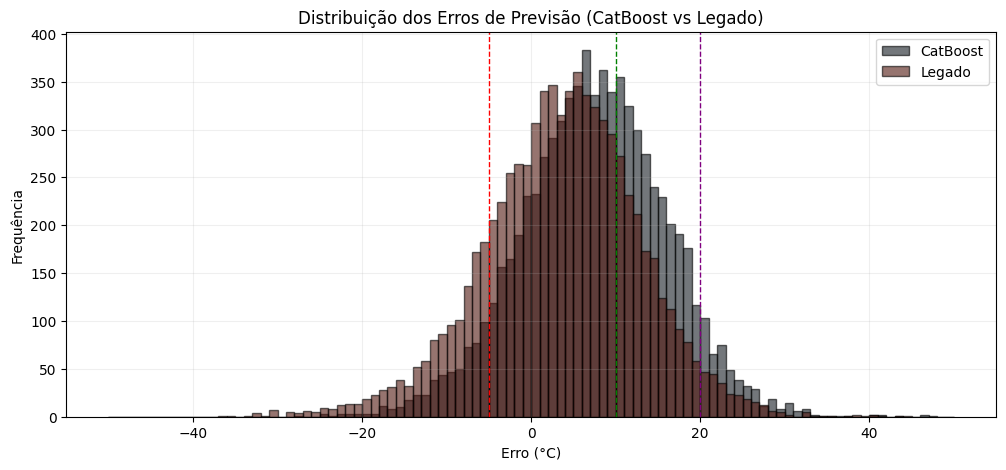

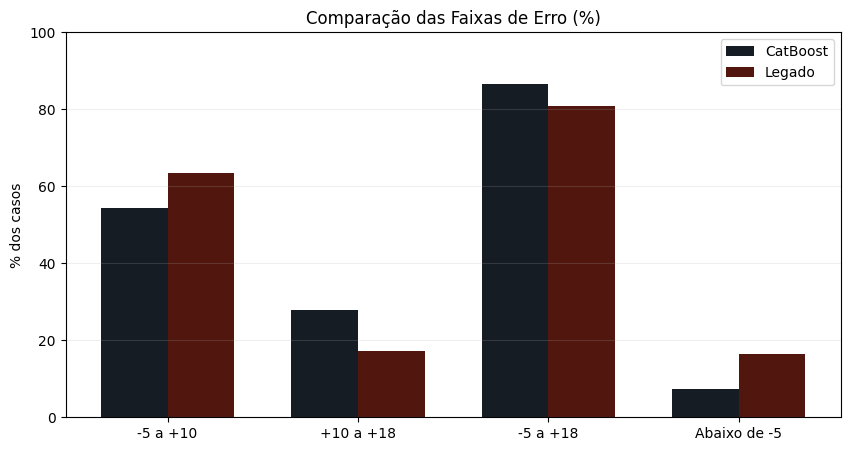

In [133]:
import matplotlib.pyplot as plt
import numpy as np

# Garantir que as variáveis de percentuais e contagens existem
if 'dentro_faixa_10_20' not in locals():
    faixa_min_10_20 = 10
    faixa_max_10_20 = 18
    dentro_faixa_10_20 = ((calcular_5_10 > faixa_min_10_20) & (calcular_5_10 <= faixa_max_10_20)).sum()
if 'pct_dentro_10_20' not in locals():
    pct_dentro_10_20 = 100 * dentro_faixa_10_20 / total if 'total' in locals() and total > 0 else 0
if 'dentro_faixa_10_20_legado' not in locals():
    faixa_min_10_20 = 10
    faixa_max_10_20 = 18
    dentro_faixa_10_20_legado = ((calcular_5_10_legado > faixa_min_10_20) & (calcular_5_10_legado <= faixa_max_10_20)).sum()
if 'pct_dentro_10_20_legado' not in locals():
    pct_dentro_10_20_legado = 100 * dentro_faixa_10_20_legado / total_legado if 'total_legado' in locals() and total_legado > 0 else 0

# Histograma dos erros lado a lado
plt.figure(figsize=(12,5))
plt.hist(calcular_5_10, bins=np.arange(-50,51,1), alpha=0.6, label='CatBoost', color='#161C23', edgecolor='black')  # cinza escuro
plt.hist(calcular_5_10_legado, bins=np.arange(-50,51,1), alpha=0.6, label='Legado', color='#51170F', edgecolor='black')  # vermelho
plt.axvline(-5, color='red', linestyle='--', lw=1)
plt.axvline(10, color='green', linestyle='--', lw=1)
plt.axvline(20, color='purple', linestyle='--', lw=1)
plt.title('Distribuição dos Erros de Previsão (CatBoost vs Legado)')
plt.xlabel('Erro (°C)')
plt.ylabel('Frequência')
plt.legend()
plt.grid(alpha=0.2)
plt.show()


faixas_labels = ['-5 a +10','+10 a +18','-5 a +18','Abaixo de -5']
catboost_vals = [pct_dentro, pct_dentro_10_20, pct_dentro_m5_20, pct_abaixo_m5]
legado_vals = [pct_dentro_legado, pct_dentro_10_20_legado, pct_dentro_m5_20_legado, pct_abaixo_m5_legado]

x = np.arange(len(faixas_labels))
width = 0.35

plt.figure(figsize=(10,5))
plt.bar(x - width/2, catboost_vals, width, label='CatBoost', color='#161C23')  # cinza escuro
plt.bar(x + width/2, legado_vals, width, label='Legado', color='#51170F')      # vermelho
plt.ylabel('% dos casos')
plt.title('Comparação das Faixas de Erro (%)')
plt.xticks(x, faixas_labels)
plt.ylim(0,100)
plt.legend()
plt.grid(axis='y', alpha=0.2)
plt.show()

In [136]:


print("="*55)
print(f"{'COMPARAÇÃO DE FAIXAS DE ERRO':^55}")
print("="*55)
print(f"{'Faixa':<22} | {'CatBoost':>13} | {'Legado':>13}")
print("-"*55)
print(f"{'Total de valores':<22} | {total:>13,} | {total_legado:>13,}")
print(f"{'Dentro [-5, +10]':<22} | {dentro_faixa:>6} ({pct_dentro:5.2f}%) | {dentro_faixa_legado:>6} ({pct_dentro_legado:5.2f}%)")
print(f"{'Fora da faixa':<22} | {fora_faixa:>6} ({pct_fora:5.2f}%) | {fora_faixa_legado:>6} ({pct_fora_legado:5.2f}%)")
print(f"{'Entre +10 e +20':<22} | {dentro_faixa_10_20:>6} ({pct_dentro_10_20:5.2f}%) | {dentro_faixa_10_20_legado:>6} ({pct_dentro_10_20_legado:5.2f}%)")
print(f"{'Entre -5 e +20':<22} | {dentro_faixa_m5_20:>6} ({pct_dentro_m5_20:5.2f}%) | {dentro_faixa_m5_20_legado:>6} ({pct_dentro_m5_20_legado:5.2f}%)")
print(f"{'Abaixo de -5':<22} | {abaixo_m5:>6} ({pct_abaixo_m5:5.2f}%) | {abaixo_m5_legado:>6} ({pct_abaixo_m5_legado:5.2f}%)")
print("="*55)

             COMPARAÇÃO DE FAIXAS DE ERRO              
Faixa                  |      CatBoost |        Legado
-------------------------------------------------------
Total de valores       |         7,485 |         7,485
Dentro [-5, +10]       |   4063 (54.28%) |   4755 (63.53%)
Fora da faixa          |   3422 (45.72%) |   2730 (36.47%)
Entre +10 e +20        |   2081 (27.80%) |   1295 (17.30%)
Entre -5 e +20         |   6471 (86.45%) |   6050 (80.83%)
Abaixo de -5           |    541 ( 7.23%) |   1229 (16.42%)



COMPARAÇÃO DE FAIXAS DE ERRO  sem c_min            

Faixa                  |      CatBoost |        Legado

Total de valores       |         7,485 |         7,485
Dentro [-5, +10]       |   4071 (54.39%) |   4755 (63.53%)
Fora da faixa          |   3414 (45.61%) |   2730 (36.47%)
Entre +10 e +20        |   2373 (31.70%) |   1295 (17.30%)
Entre -5 e +20         |   6444 (86.09%) |   6050 (80.83%)
Abaixo de -5           |    554 ( 7.40%) |   1229 (16.42%)


=======================================================
             COMPARAÇÃO DE FAIXAS DE ERRO   sem c_min e c_max           
=======================================================
Faixa                  |      CatBoost |        Legado
-------------------------------------------------------
Total de valores       |         7,485 |         7,485
Dentro [-5, +10]       |   4063 (54.28%) |   4755 (63.53%)
Fora da faixa          |   3422 (45.72%) |   2730 (36.47%)
Entre +10 e +20        |   2373 (31.70%) |   1295 (17.30%)
Entre -5 e +20         |   6471 (86.45%) |   6050 (80.83%)
Abaixo de -5           |    541 ( 7.23%) |   1229 (16.42%)
=======================================================

In [118]:
print("=== ANÁLISE DO IMPACTO DA SEQUÊNCIA NA PERDA DE TEMPERATURA ===")

# 1. Verificar presença e distribuição da sequência
print("Distribuição de sequências no dataset:")
seq_counts = dadosoriginais_com_catboost['sequencia'].value_counts().sort_index()
print(seq_counts)
print(f"\nTotal de sequências únicas: {dadosoriginais_com_catboost['sequencia'].nunique()}")

# 2. Calcular perda de temperatura (Real - FP) por sequência
dadosoriginais_com_catboost['perda_temperatura'] = (
    dadosoriginais_com_catboost['temperaturamediareal'] - 
    dadosoriginais_com_catboost['temperaturasaidafp']
)

# 3. Criar as colunas de erro dos modelos no DataFrame
print(f"\n=== CRIANDO COLUNAS DE ERRO DOS MODELOS ===")

# Calcular os erros e adicionar ao DataFrame
dif_real_fp = dadosoriginais_com_catboost['temperaturamediareal'] - dadosoriginais_com_catboost['temperaturasaidafp']

# Erro CatBoost
dif_real_fp_menos_sugestaocatboost = dadosoriginais_com_catboost['sugestaocatboost'] + dif_real_fp
dadosoriginais_com_catboost['calcular_5_10'] = dif_real_fp_menos_sugestaocatboost - dadosoriginais_com_catboost['temperaturaobjetivada']

# Erro Legacy
dif_real_fp_menos_sugestaomodelolegado = dadosoriginais_com_catboost['sugestaomodelolegado'] + dif_real_fp
dadosoriginais_com_catboost['calcular_5_10_legado'] = dif_real_fp_menos_sugestaomodelolegado - dadosoriginais_com_catboost['temperaturaobjetivada']

print("✓ Colunas de erro criadas no DataFrame")

# 4. Calcular estatísticas de perda de temperatura por sequência
print(f"\n=== PERDA DE TEMPERATURA POR SEQUÊNCIA ===")
perda_por_seq = dadosoriginais_com_catboost.groupby('sequencia')['perda_temperatura'].agg([
    'count', 'mean', 'std', 'min', 'max'
]).round(2)

print("Estatísticas de perda de temperatura por sequência:")
print(perda_por_seq)

# 5. Análise estatística - teste ANOVA
from scipy import stats

print(f"\n=== TESTE ESTATÍSTICO (ANOVA) ===")
seq_grupos = []
for seq in sorted(dadosoriginais_com_catboost['sequencia'].unique()):
    grupo = dadosoriginais_com_catboost[
        dadosoriginais_com_catboost['sequencia'] == seq
    ]['perda_temperatura'].dropna()
    seq_grupos.append(grupo)
    print(f"Sequência {seq}: {len(grupo)} amostras, perda média = {grupo.mean():.2f}°C")

# Teste ANOVA
if len(seq_grupos) > 1:
    f_stat, p_value = stats.f_oneway(*seq_grupos)
    print(f"\nF-statistic: {f_stat:.4f}")
    print(f"P-value: {p_value:.6f}")
    
    if p_value < 0.05:
        print("✓ Diferença SIGNIFICATIVA entre sequências (p < 0.05)")
    else:
        print("❌ Diferença NÃO significativa entre sequências (p >= 0.05)")

# 6. Verificar se sequência está no modelo como feature importante
print(f"\n=== IMPORTÂNCIA DA SEQUÊNCIA NO MODELO ===")
if 'importance_df' in locals():
    seq_importance = importance_df[importance_df['feature'].str.contains('sequen', case=False, na=False)]
    
    if not seq_importance.empty:
        print("Importância da sequência no modelo:")
        for idx, row in seq_importance.iterrows():
            rank = importance_df.index[importance_df['feature'] == row['feature']].tolist()[0] + 1
            print(f"  {row['feature']}: Rank #{rank}, Importância = {row['importance']:.2f}")
    else:
        print("❌ 'sequencia' não está entre as features do modelo")
        print("\nTop 15 features mais importantes:")
        for i, row in importance_df.head(15).iterrows():
            print(f"  {i+1:2}. {row['feature']:<25} | {row['importance']:8.2f}")
else:
    print("DataFrame de importância não encontrado")

# 7. Análise do erro do modelo por sequência
print(f"\n=== ERRO DOS MODELOS POR SEQUÊNCIA ===")

# Erro do CatBoost por sequência
erro_cb_por_seq = dadosoriginais_com_catboost.groupby('sequencia')['calcular_5_10'].agg([
    'count', 'mean', 'std'
]).round(2)

# Erro do Legacy por sequência  
erro_legacy_por_seq = dadosoriginais_com_catboost.groupby('sequencia')['calcular_5_10_legado'].agg([
    'count', 'mean', 'std'
]).round(2)

print("Erro do CatBoost por sequência:")
print(erro_cb_por_seq)

print("\nErro do Legacy por sequência:")
print(erro_legacy_por_seq)

# 8. Temperatura média por sequência (análise exploratória)
print(f"\n=== TEMPERATURAS MÉDIAS POR SEQUÊNCIA ===")
temp_stats = dadosoriginais_com_catboost.groupby('sequencia').agg({
    'temperaturamediareal': ['count', 'mean', 'std'],
    'temperaturasaidafp': ['mean', 'std'],
    'temperaturaobjetivada': ['mean', 'std'],
    'sugestaocatboost': ['mean', 'std'],
    'sugestaomodelolegado': ['mean', 'std']
}).round(2)

print("Estatísticas de temperatura por sequência:")
print(temp_stats)

# 9. Análise de concordância por sequência (faixa -5 a +10)
print(f"\n=== CONCORDÂNCIA DOS MODELOS POR SEQUÊNCIA (FAIXA -5 a +10) ===")

concordancia_summary = []
for seq in sorted(dadosoriginais_com_catboost['sequencia'].unique()):
    seq_data = dadosoriginais_com_catboost[dadosoriginais_com_catboost['sequencia'] == seq]
    
    total_seq = len(seq_data)
    cb_dentro_faixa = ((seq_data['calcular_5_10'] >= -5) & (seq_data['calcular_5_10'] <= 10)).sum()
    cb_pct = (cb_dentro_faixa / total_seq * 100) if total_seq > 0 else 0
    
    legacy_dentro_faixa = ((seq_data['calcular_5_10_legado'] >= -5) & (seq_data['calcular_5_10_legado'] <= 10)).sum()
    legacy_pct = (legacy_dentro_faixa / total_seq * 100) if total_seq > 0 else 0
    
    concordancia_summary.append({
        'sequencia': seq,
        'total': total_seq,
        'catboost_faixa': cb_dentro_faixa,
        'catboost_pct': cb_pct,
        'legacy_faixa': legacy_dentro_faixa,
        'legacy_pct': legacy_pct,
        'diferenca_pct': cb_pct - legacy_pct
    })

print(f"{'SEQ':<4} | {'TOTAL':<6} | {'CB_FAIXA':<8} | {'CB_%':<6} | {'LEG_FAIXA':<9} | {'LEG_%':<6} | {'DIFF_%':<7}")
print("-" * 60)
for item in concordancia_summary:
    print(f"{item['sequencia']:<4} | {item['total']:<6} | {item['catboost_faixa']:<8} | {item['catboost_pct']:<6.1f} | {item['legacy_faixa']:<9} | {item['legacy_pct']:<6.1f} | {item['diferenca_pct']:<+7.1f}")

# 10. Conclusões
print(f"\n=== CONCLUSÕES SOBRE O IMPACTO DA SEQUÊNCIA ===")

seq_maior_perda = perda_por_seq['mean'].idxmax()
seq_menor_perda = perda_por_seq['mean'].idxmin()

print(f"1. Sequência com MAIOR perda de temperatura: {seq_maior_perda} ({perda_por_seq.loc[seq_maior_perda, 'mean']:.2f}°C)")
print(f"2. Sequência com MENOR perda de temperatura: {seq_menor_perda} ({perda_por_seq.loc[seq_menor_perda, 'mean']:.2f}°C)")
print(f"3. Diferença entre maior e menor: {perda_por_seq['mean'].max() - perda_por_seq['mean'].min():.2f}°C")

if 'seq_importance' in locals() and not seq_importance.empty:
    print(f"4. ✓ Sequência está sendo considerada pelo modelo")
else:
    print(f"4. ❌ Sequência NÃO está sendo considerada pelo modelo")
    print(f"   Isso pode explicar parte da diferença de performance!")

melhor_seq_cb = max(concordancia_summary, key=lambda x: x['catboost_pct'])
pior_seq_cb = min(concordancia_summary, key=lambda x: x['catboost_pct'])

print(f"5. CatBoost funciona melhor na sequência {melhor_seq_cb['sequencia']} ({melhor_seq_cb['catboost_pct']:.1f}%)")
print(f"6. CatBoost funciona pior na sequência {pior_seq_cb['sequencia']} ({pior_seq_cb['catboost_pct']:.1f}%)")

print(f"\n💡 RECOMENDAÇÃO:")
print(f"Se a sequência não estiver no modelo, considere:")
print(f"- Verificar se a variável 'sequencia' está no dataset de treino")
print(f"- Re-treinar o modelo incluindo 'sequencia' como feature categórica")
print(f"- Criar features derivadas da sequência (ex: is_primeira_sequencia)")

# 11. Resumo estatístico final
print(f"\n=== RESUMO ESTATÍSTICO POR SEQUÊNCIA ===")
for seq in sorted(dadosoriginais_com_catboost['sequencia'].unique()):
    seq_data = dadosoriginais_com_catboost[dadosoriginais_com_catboost['sequencia'] == seq]
    
    perda_media = seq_data['perda_temperatura'].mean()
    cb_erro_medio = seq_data['calcular_5_10'].mean()
    legacy_erro_medio = seq_data['calcular_5_10_legado'].mean()
    
    print(f"Sequência {seq}:")
    print(f"  • Perda média de temperatura: {perda_media:.2f}°C")
    print(f"  • Erro médio CatBoost: {cb_erro_medio:.2f}°C")
    print(f"  • Erro médio Legacy: {legacy_erro_medio:.2f}°C")
    print(f"  • Amostras: {len(seq_data):,}")
    print()

=== ANÁLISE DO IMPACTO DA SEQUÊNCIA NA PERDA DE TEMPERATURA ===
Distribuição de sequências no dataset:
sequencia
1.0     1480
2.0     1424
3.0     1315
4.0     1095
5.0      854
6.0      645
7.0      407
8.0      171
9.0       61
10.0      31
11.0       2
Name: count, dtype: int64

Total de sequências únicas: 11

=== CRIANDO COLUNAS DE ERRO DOS MODELOS ===
✓ Colunas de erro criadas no DataFrame

=== PERDA DE TEMPERATURA POR SEQUÊNCIA ===
Estatísticas de perda de temperatura por sequência:
           count    mean    std     min   max
sequencia                                    
1.0         1478 -130.18  15.60  -190.0 -72.0
2.0         1424 -110.20  14.40  -175.0 -68.0
3.0         1314 -111.31  43.35 -1587.0 -68.0
4.0         1095 -109.45  12.57  -160.0 -71.0
5.0          854 -107.61  12.51  -173.0 -72.0
6.0          645 -107.07  11.62  -156.0 -73.0
7.0          407 -105.76  10.67  -139.0 -75.0
8.0          171 -104.83  11.10  -132.0 -81.0
9.0           61 -102.59  12.33  -131.0 -75.0


=== ANÁLISE DO IMPACTO DA SEQUÊNCIA NA PERDA DE TEMPERATURA COM GRÁFICOS ===
Distribuição de sequências no dataset:
sequencia
1.0     1480
2.0     1424
3.0     1315
4.0     1095
5.0      854
6.0      645
7.0      407
8.0      171
9.0       61
10.0      31
11.0       2
Name: count, dtype: int64

Total de sequências únicas: 11

=== CRIANDO COLUNAS DE ERRO DOS MODELOS ===
✓ Colunas de erro criadas no DataFrame

=== PERDA DE TEMPERATURA POR SEQUÊNCIA ===
Estatísticas de perda de temperatura por sequência:
           count    mean    std     min   max
sequencia                                    
1.0         1478 -130.18  15.60  -190.0 -72.0
2.0         1424 -110.20  14.40  -175.0 -68.0
3.0         1314 -111.31  43.35 -1587.0 -68.0
4.0         1095 -109.45  12.57  -160.0 -71.0
5.0          854 -107.61  12.51  -173.0 -72.0
6.0          645 -107.07  11.62  -156.0 -73.0
7.0          407 -105.76  10.67  -139.0 -75.0
8.0          171 -104.83  11.10  -132.0 -81.0
9.0           61 -102.59  12.33  

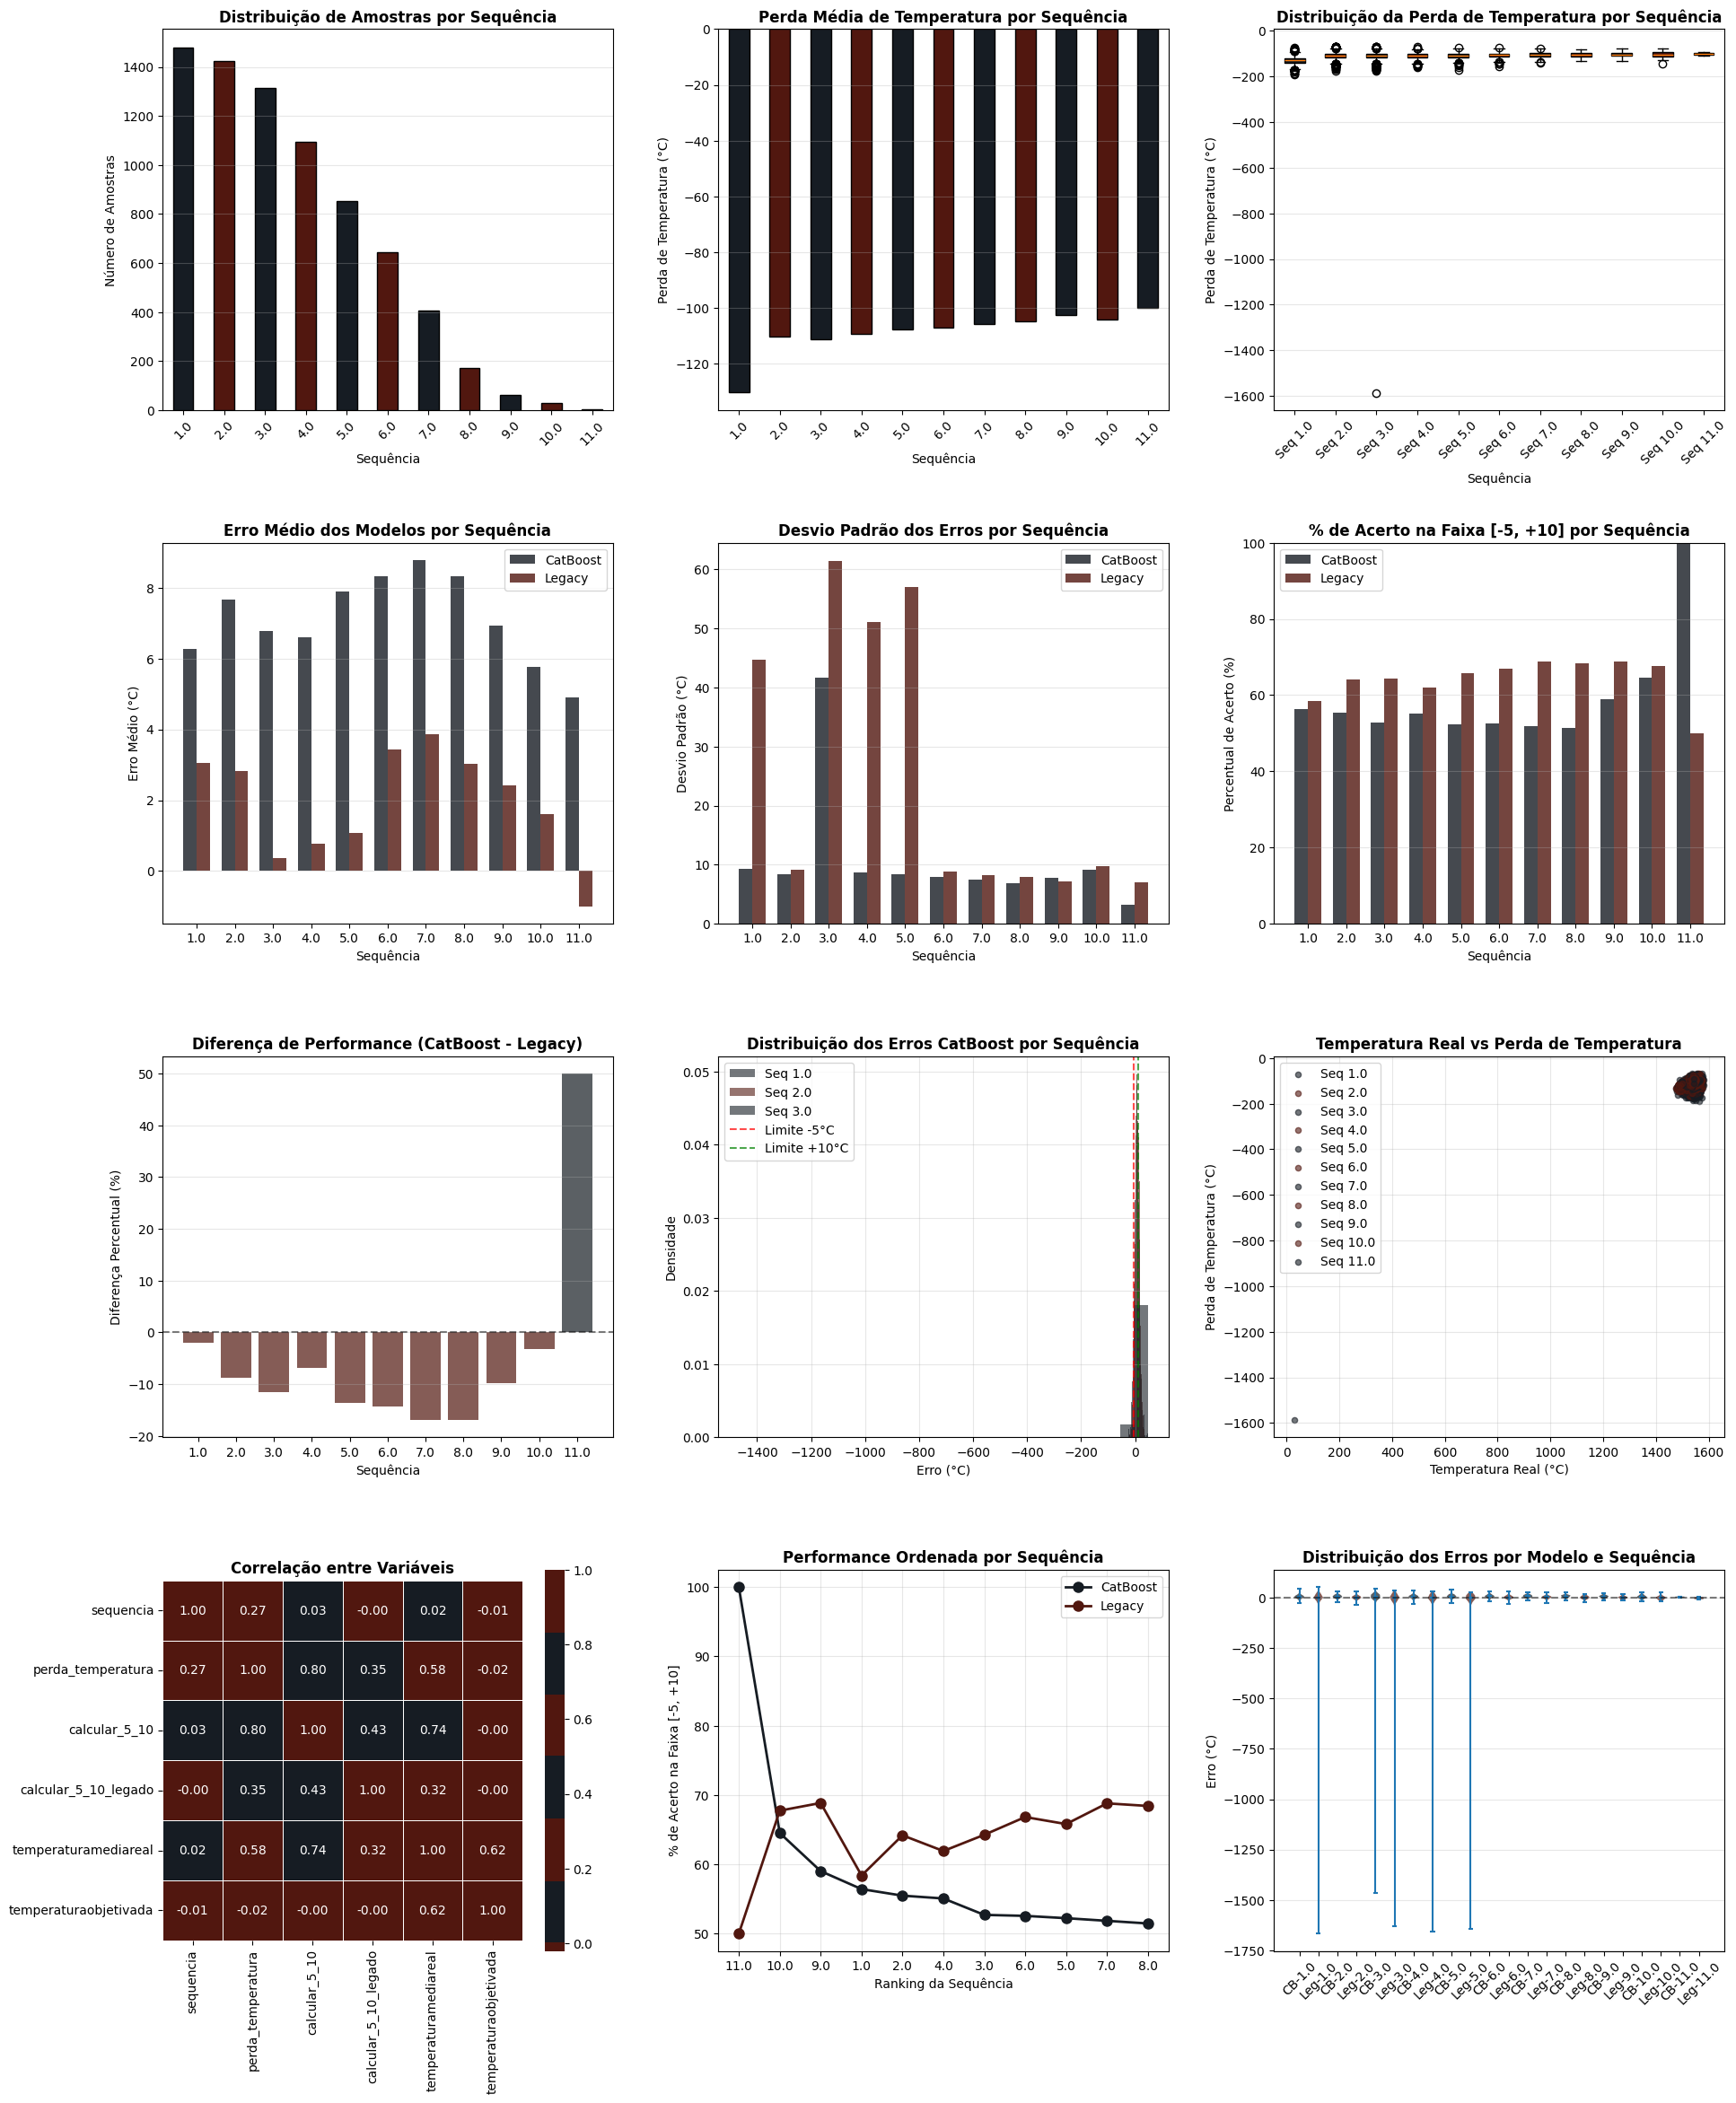


=== RESUMO TABULAR ===
SEQ  | TOTAL  | CB_FAIXA | CB_%   | LEG_FAIXA | LEG_%  | DIFF_% 
------------------------------------------------------------
1.0  | 1480   | 835      | 56.4   | 864       | 58.4   | -2.0   
2.0  | 1424   | 790      | 55.5   | 914       | 64.2   | -8.7   
3.0  | 1315   | 693      | 52.7   | 845       | 64.3   | -11.6  
4.0  | 1095   | 603      | 55.1   | 678       | 61.9   | -6.8   
5.0  | 854    | 446      | 52.2   | 562       | 65.8   | -13.6  
6.0  | 645    | 339      | 52.6   | 431       | 66.8   | -14.3  
7.0  | 407    | 211      | 51.8   | 280       | 68.8   | -17.0  
8.0  | 171    | 88       | 51.5   | 117       | 68.4   | -17.0  
9.0  | 61     | 36       | 59.0   | 42        | 68.9   | -9.8   
10.0 | 31     | 20       | 64.5   | 21        | 67.7   | -3.2   
11.0 | 2      | 2        | 100.0  | 1         | 50.0   | +50.0  

=== CONCLUSÕES VISUAIS ===
1. Sequência com MAIOR perda de temperatura: 11.0 (-100.00°C)
2. Sequência com MENOR perda de temperatura: 

In [ ]:


print("=== ANÁLISE DO IMPACTO DA SEQUÊNCIA NA PERDA DE TEMPERATURA COM GRÁFICOS ===")

# 1. Verificar presença e distribuição da sequência
print("Distribuição de sequências no dataset:")
seq_counts = dadosoriginais_com_catboost['sequencia'].value_counts().sort_index()
print(seq_counts)
print(f"\nTotal de sequências únicas: {dadosoriginais_com_catboost['sequencia'].nunique()}")

# 2. Calcular perda de temperatura (Real - FP) por sequência
dadosoriginais_com_catboost['perda_temperatura'] = (
    dadosoriginais_com_catboost['temperaturamediareal'] -
    dadosoriginais_com_catboost['temperaturasaidafp']
)

# 3. Criar as colunas de erro dos modelos no DataFrame
print(f"\n=== CRIANDO COLUNAS DE ERRO DOS MODELOS ===")

dif_real_fp = dadosoriginais_com_catboost['temperaturamediareal'] - dadosoriginais_com_catboost['temperaturasaidafp']

# Erro CatBoost
dif_real_fp_menos_sugestaocatboost = dadosoriginais_com_catboost['sugestaocatboost'] + dif_real_fp
dadosoriginais_com_catboost['calcular_5_10'] = dif_real_fp_menos_sugestaocatboost - dadosoriginais_com_catboost['temperaturaobjetivada']

# Erro Legacy
dif_real_fp_menos_sugestaomodelolegado = dadosoriginais_com_catboost['sugestaomodelolegado'] + dif_real_fp
dadosoriginais_com_catboost['calcular_5_10_legado'] = dif_real_fp_menos_sugestaomodelolegado - dadosoriginais_com_catboost['temperaturaobjetivada']

print("✓ Colunas de erro criadas no DataFrame")

# 4. Calcular estatísticas de perda de temperatura por sequência
print(f"\n=== PERDA DE TEMPERATURA POR SEQUÊNCIA ===")
perda_por_seq = dadosoriginais_com_catboost.groupby('sequencia')['perda_temperatura'].agg([
    'count', 'mean', 'std', 'min', 'max'
]).round(2)

print("Estatísticas de perda de temperatura por sequência:")
print(perda_por_seq)

# 5. Análise estatística - teste ANOVA
print(f"\n=== TESTE ESTATÍSTICO (ANOVA) ===")
seq_grupos = []
for seq in sorted(dadosoriginais_com_catboost['sequencia'].unique()):
    grupo = dadosoriginais_com_catboost[
        dadosoriginais_com_catboost['sequencia'] == seq
    ]['perda_temperatura'].dropna()
    seq_grupos.append(grupo)
    print(f"Sequência {seq}: {len(grupo)} amostras, perda média = {grupo.mean():.2f}°C")

if len(seq_grupos) > 1:
    f_stat, p_value = stats.f_oneway(*seq_grupos)
    print(f"\nF-statistic: {f_stat:.4f}")
    print(f"P-value: {p_value:.6f}")
    if p_value < 0.05:
        print("✓ Diferença SIGNIFICATIVA entre sequências (p < 0.05)")
    else:
        print("❌ Diferença NÃO significativa entre sequências (p >= 0.05)")

# GRÁFICOS DA ANÁLISE
print(f"\n=== CRIANDO VISUALIZAÇÕES ===")

# Paleta customizada: cinza escuro e vermelho alternados
custom_palette = ['#161C23', '#51170F'] * 6
sns.set_palette(custom_palette)
plt.style.use('default')

fig = plt.figure(figsize=(20, 24))

# 1. Distribuição das sequências
ax1 = plt.subplot(4, 3, 1)
seq_colors = [custom_palette[i % 2] for i in range(len(seq_counts))]
seq_counts.plot(kind='bar', ax=ax1, color=seq_colors, edgecolor='black')
ax1.set_title('Distribuição de Amostras por Sequência', fontsize=12, fontweight='bold')
ax1.set_xlabel('Sequência')
ax1.set_ylabel('Número de Amostras')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# 2. Perda de temperatura média por sequência
ax2 = plt.subplot(4, 3, 2)
perda_colors = [custom_palette[i % 2] for i in range(len(perda_por_seq['mean']))]
perda_por_seq['mean'].plot(kind='bar', ax=ax2, color=perda_colors, edgecolor='black')
ax2.set_title('Perda Média de Temperatura por Sequência', fontsize=12, fontweight='bold')
ax2.set_xlabel('Sequência')
ax2.set_ylabel('Perda de Temperatura (°C)')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# 3. Boxplot da perda de temperatura por sequência
ax3 = plt.subplot(4, 3, 3)
seq_data = []
seq_labels = []
for i, seq in enumerate(sorted(dadosoriginais_com_catboost['sequencia'].unique())):
    data = dadosoriginais_com_catboost[dadosoriginais_com_catboost['sequencia'] == seq]['perda_temperatura'].dropna()
    if len(data) > 0:
        seq_data.append(data)
        seq_labels.append(f'Seq {seq}')
box_colors = [custom_palette[i % 2] for i in range(len(seq_data))]
box = plt.boxplot(seq_data, labels=seq_labels, patch_artist=True)
for patch, color in zip(box['boxes'], box_colors):
    patch.set_facecolor(color)
plt.title('Distribuição da Perda de Temperatura por Sequência', fontsize=12, fontweight='bold')
plt.xlabel('Sequência')
plt.ylabel('Perda de Temperatura (°C)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Calcular erros por sequência para os próximos gráficos
erro_cb_por_seq = dadosoriginais_com_catboost.groupby('sequencia')['calcular_5_10'].agg([
    'count', 'mean', 'std'
]).round(2)
erro_legacy_por_seq = dadosoriginais_com_catboost.groupby('sequencia')['calcular_5_10_legado'].agg([
    'count', 'mean', 'std'
]).round(2)

# 4. Erro médio dos modelos por sequência
ax4 = plt.subplot(4, 3, 4)
x = np.arange(len(erro_cb_por_seq.index))
width = 0.35
plt.bar(x - width/2, erro_cb_por_seq['mean'], width, label='CatBoost', color=custom_palette[0], alpha=0.8)
plt.bar(x + width/2, erro_legacy_por_seq['mean'], width, label='Legacy', color=custom_palette[1], alpha=0.8)
plt.title('Erro Médio dos Modelos por Sequência', fontsize=12, fontweight='bold')
plt.xlabel('Sequência')
plt.ylabel('Erro Médio (°C)')
plt.xticks(x, erro_cb_por_seq.index)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# 5. Desvio padrão dos erros por sequência
ax5 = plt.subplot(4, 3, 5)
plt.bar(x - width/2, erro_cb_por_seq['std'], width, label='CatBoost', color=custom_palette[0], alpha=0.8)
plt.bar(x + width/2, erro_legacy_por_seq['std'], width, label='Legacy', color=custom_palette[1], alpha=0.8)
plt.title('Desvio Padrão dos Erros por Sequência', fontsize=12, fontweight='bold')
plt.xlabel('Sequência')
plt.ylabel('Desvio Padrão (°C)')
plt.xticks(x, erro_cb_por_seq.index)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# 6. Análise de concordância por sequência
concordancia_summary = []
for seq in sorted(dadosoriginais_com_catboost['sequencia'].unique()):
    seq_data = dadosoriginais_com_catboost[dadosoriginais_com_catboost['sequencia'] == seq]
    total_seq = len(seq_data)
    cb_dentro_faixa = ((seq_data['calcular_5_10'] >= -5) & (seq_data['calcular_5_10'] <= 10)).sum()
    cb_pct = (cb_dentro_faixa / total_seq * 100) if total_seq > 0 else 0
    legacy_dentro_faixa = ((seq_data['calcular_5_10_legado'] >= -5) & (seq_data['calcular_5_10_legado'] <= 10)).sum()
    legacy_pct = (legacy_dentro_faixa / total_seq * 100) if total_seq > 0 else 0
    concordancia_summary.append({
        'sequencia': seq,
        'total': total_seq,
        'catboost_faixa': cb_dentro_faixa,
        'catboost_pct': cb_pct,
        'legacy_faixa': legacy_dentro_faixa,
        'legacy_pct': legacy_pct,
        'diferenca_pct': cb_pct - legacy_pct
    })

ax6 = plt.subplot(4, 3, 6)
concordancia_df = pd.DataFrame(concordancia_summary)
x = np.arange(len(concordancia_df))
plt.bar(x - width/2, concordancia_df['catboost_pct'], width, label='CatBoost', color=custom_palette[0], alpha=0.8)
plt.bar(x + width/2, concordancia_df['legacy_pct'], width, label='Legacy', color=custom_palette[1], alpha=0.8)
plt.title('% de Acerto na Faixa [-5, +10] por Sequência', fontsize=12, fontweight='bold')
plt.xlabel('Sequência')
plt.ylabel('Percentual de Acerto (%)')
plt.xticks(x, concordancia_df['sequencia'])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, 100)

# 7. Diferença de performance entre modelos
ax7 = plt.subplot(4, 3, 7)
cores = [custom_palette[0] if diff >= 0 else custom_palette[1] for diff in concordancia_df['diferenca_pct']]
plt.bar(range(len(concordancia_df)), concordancia_df['diferenca_pct'], color=cores, alpha=0.7)
plt.title('Diferença de Performance (CatBoost - Legacy)', fontsize=12, fontweight='bold')
plt.xlabel('Sequência')
plt.ylabel('Diferença Percentual (%)')
plt.xticks(range(len(concordancia_df)), concordancia_df['sequencia'])
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.grid(axis='y', alpha=0.3)

# 8. Histograma dos erros por sequência (exemplo para algumas sequências)
ax8 = plt.subplot(4, 3, 8)
sequencias_exemplo = sorted(dadosoriginais_com_catboost['sequencia'].unique())[:3]
for i, seq in enumerate(sequencias_exemplo):
    erros_seq = dadosoriginais_com_catboost[dadosoriginais_com_catboost['sequencia'] == seq]['calcular_5_10'].dropna()
    plt.hist(erros_seq, bins=30, alpha=0.6, label=f'Seq {seq}', density=True, color=custom_palette[i % 2])
plt.axvline(-5, color='red', linestyle='--', alpha=0.7, label='Limite -5°C')
plt.axvline(10, color='green', linestyle='--', alpha=0.7, label='Limite +10°C')
plt.title('Distribuição dos Erros CatBoost por Sequência', fontsize=12, fontweight='bold')
plt.xlabel('Erro (°C)')
plt.ylabel('Densidade')
plt.legend()
plt.grid(alpha=0.3)

# 9. Scatter plot: Temperatura Real vs Perdas por Sequência
ax9 = plt.subplot(4, 3, 9)
for i, seq in enumerate(sorted(dadosoriginais_com_catboost['sequencia'].unique())):
    seq_data = dadosoriginais_com_catboost[dadosoriginais_com_catboost['sequencia'] == seq]
    plt.scatter(seq_data['temperaturamediareal'], seq_data['perda_temperatura'],
               alpha=0.6, label=f'Seq {seq}', s=20, color=custom_palette[i % 2])
plt.title('Temperatura Real vs Perda de Temperatura', fontsize=12, fontweight='bold')
plt.xlabel('Temperatura Real (°C)')
plt.ylabel('Perda de Temperatura (°C)')
plt.legend()
plt.grid(alpha=0.3)

# 10. Heatmap de correlação entre sequência e outras variáveis
ax10 = plt.subplot(4, 3, 10)
corr_vars = ['sequencia', 'perda_temperatura', 'calcular_5_10', 'calcular_5_10_legado',
             'temperaturamediareal', 'temperaturaobjetivada']
corr_data = dadosoriginais_com_catboost[corr_vars].corr()
sns.heatmap(corr_data, annot=True, cmap=sns.color_palette(custom_palette, as_cmap=True), center=0, ax=ax10,
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Correlação entre Variáveis', fontsize=12, fontweight='bold')

# 11. Performance acumulada por sequência
ax11 = plt.subplot(4, 3, 11)
concordancia_ordenada = concordancia_df.sort_values('catboost_pct', ascending=False)
plt.plot(range(len(concordancia_ordenada)), concordancia_ordenada['catboost_pct'],
         'o-', label='CatBoost', color=custom_palette[0], linewidth=2, markersize=8)
plt.plot(range(len(concordancia_ordenada)), concordancia_ordenada['legacy_pct'],
         'o-', label='Legacy', color=custom_palette[1], linewidth=2, markersize=8)
plt.title('Performance Ordenada por Sequência', fontsize=12, fontweight='bold')
plt.xlabel('Ranking da Sequência')
plt.ylabel('% de Acerto na Faixa [-5, +10]')
plt.xticks(range(len(concordancia_ordenada)), concordancia_ordenada['sequencia'])
plt.legend()
plt.grid(alpha=0.3)

# 12. Violin plot da distribuição dos erros
ax12 = plt.subplot(4, 3, 12)
erro_data = []
labels = []
for i, seq in enumerate(sorted(dadosoriginais_com_catboost['sequencia'].unique())):
    erros_cb = dadosoriginais_com_catboost[dadosoriginais_com_catboost['sequencia'] == seq]['calcular_5_10'].dropna()
    erros_legacy = dadosoriginais_com_catboost[dadosoriginais_com_catboost['sequencia'] == seq]['calcular_5_10_legado'].dropna()
    if len(erros_cb) > 0 and len(erros_legacy) > 0:
        erro_data.extend([erros_cb, erros_legacy])
        labels.extend([f'CB-{seq}', f'Leg-{seq}'])
if erro_data:
    parts = plt.violinplot(erro_data, positions=range(len(erro_data)), showmeans=True)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(custom_palette[i % 2])
        pc.set_alpha(0.7)
    plt.xticks(range(len(labels)), labels, rotation=45)
    plt.title('Distribuição dos Erros por Modelo e Sequência', fontsize=12, fontweight='bold')
    plt.ylabel('Erro (°C)')
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout(pad=3.0)
plt.show()

print(f"\n=== RESUMO TABULAR ===")
print(f"{'SEQ':<4} | {'TOTAL':<6} | {'CB_FAIXA':<8} | {'CB_%':<6} | {'LEG_FAIXA':<9} | {'LEG_%':<6} | {'DIFF_%':<7}")
print("-" * 60)
for item in concordancia_summary:
    print(f"{item['sequencia']:<4} | {item['total']:<6} | {item['catboost_faixa']:<8} | {item['catboost_pct']:<6.1f} | {item['legacy_faixa']:<9} | {item['legacy_pct']:<6.1f} | {item['diferenca_pct']:<+7.1f}")

print(f"\n=== CONCLUSÕES VISUAIS ===")
seq_maior_perda = perda_por_seq['mean'].idxmax()
seq_menor_perda = perda_por_seq['mean'].idxmin()
print(f"1. Sequência com MAIOR perda de temperatura: {seq_maior_perda} ({perda_por_seq.loc[seq_maior_perda, 'mean']:.2f}°C)")
print(f"2. Sequência com MENOR perda de temperatura: {seq_menor_perda} ({perda_por_seq.loc[seq_menor_perda, 'mean']:.2f}°C)")
melhor_seq_cb = max(concordancia_summary, key=lambda x: x['catboost_pct'])
pior_seq_cb = min(concordancia_summary, key=lambda x: x['catboost_pct'])
print(f"3. CatBoost funciona melhor na sequência {melhor_seq_cb['sequencia']} ({melhor_seq_cb['catboost_pct']:.1f}%)")
print(f"4. CatBoost funciona pior na sequência {pior_seq_cb['sequencia']} ({pior_seq_cb['catboost_pct']:.1f}%)")
print(f"\n📊 Visualizações criadas com sucesso!")
print(f"   • 12 gráficos diferentes mostrando vários aspectos da análise por sequência")
print(f"   • Gráficos incluem: distribuições, comparações, correlações e performance")


In [120]:
# Dados das sequências 2 a 7
sequencias_data = {
    2: {'amostras': 1424, 'perda_media': -110.20},
    3: {'amostras': 1314, 'perda_media': -111.31},
    4: {'amostras': 1095, 'perda_media': -109.45},
    5: {'amostras': 854, 'perda_media': -107.61},
    6: {'amostras': 645, 'perda_media': -107.07},
    7: {'amostras': 407, 'perda_media': -105.76}
}

print("=== ANÁLISE DAS SEQUÊNCIAS 2 A 7 ===")

# Método 1: Média simples (sem considerar número de amostras)
perdas_simples = [data['perda_media'] for data in sequencias_data.values()]
media_simples = sum(perdas_simples) / len(perdas_simples)

print(f"Método 1 - Média Simples:")
print(f"Perdas por sequência: {perdas_simples}")
print(f"Média simples: {media_simples:.2f}°C")

# Método 2: Média ponderada (considerando número de amostras)
total_amostras = sum(data['amostras'] for data in sequencias_data.values())
soma_ponderada = sum(data['amostras'] * data['perda_media'] for data in sequencias_data.values())
media_ponderada = soma_ponderada / total_amostras

print(f"\nMétodo 2 - Média Ponderada pelo número de amostras:")
print(f"Total de amostras (seq 2-7): {total_amostras:,}")
print(f"Média ponderada: {media_ponderada:.2f}°C")

# Detalhamento
print(f"\n=== DETALHAMENTO ===")
print(f"{'SEQ':<4} | {'AMOSTRAS':<8} | {'PERDA MÉDIA':<12} | {'PESO':<6}")
print("-" * 40)

for seq, data in sequencias_data.items():
    peso = (data['amostras'] / total_amostras) * 100
    print(f"{seq:<4} | {data['amostras']:<8,} | {data['perda_media']:<12.2f} | {peso:<6.1f}%")

print(f"\n=== RESULTADO ===")
print(f"📊 Média simples (sequências 2-7): {media_simples:.2f}°C")
print(f"⚖️  Média ponderada (sequências 2-7): {media_ponderada:.2f}°C")
print(f"\nA média ponderada é mais representativa pois considera")
print(f"o número de amostras de cada sequência.")

=== ANÁLISE DAS SEQUÊNCIAS 2 A 7 ===
Método 1 - Média Simples:
Perdas por sequência: [-110.2, -111.31, -109.45, -107.61, -107.07, -105.76]
Média simples: -108.57°C

Método 2 - Média Ponderada pelo número de amostras:
Total de amostras (seq 2-7): 5,739
Média ponderada: -109.26°C

=== DETALHAMENTO ===
SEQ  | AMOSTRAS | PERDA MÉDIA  | PESO  
----------------------------------------
2    | 1,424    | -110.20      | 24.8  %
3    | 1,314    | -111.31      | 22.9  %
4    | 1,095    | -109.45      | 19.1  %
5    | 854      | -107.61      | 14.9  %
6    | 645      | -107.07      | 11.2  %
7    | 407      | -105.76      | 7.1   %

=== RESULTADO ===
📊 Média simples (sequências 2-7): -108.57°C
⚖️  Média ponderada (sequências 2-7): -109.26°C

A média ponderada é mais representativa pois considera
o número de amostras de cada sequência.


In [121]:
# Dados
sequencia_1 = -130.18  # °C
media_ponderada_2_7 = -108.65  # °C

print("=== CÁLCULO DA DIFERENÇA PERCENTUAL ===")

# Diferença absoluta
diferenca_absoluta = abs(sequencia_1 - media_ponderada_2_7)
print(f"Sequência 1: {sequencia_1:.2f}°C")
print(f"Média ponderada (seq 2-7): {media_ponderada_2_7:.2f}°C")
print(f"Diferença absoluta: {diferenca_absoluta:.2f}°C")

# Diferença percentual usando a média como base
diferenca_percentual = (diferenca_absoluta / abs(media_ponderada_2_7)) * 100

print(f"\n=== RESULTADO ===")
print(f"Diferença percentual: {diferenca_percentual:.2f}%")

# Interpretação
print(f"\n=== INTERPRETAÇÃO ===")
print(f"A sequência 1 tem uma perda de temperatura {diferenca_percentual:.1f}% maior")
print(f"que a média das sequências 2 a 7.")

# Fator multiplicativo
fator = abs(sequencia_1) / abs(media_ponderada_2_7)
print(f"A sequência 1 perde {fator:.2f}x mais temperatura que a média das outras sequências.")

=== CÁLCULO DA DIFERENÇA PERCENTUAL ===
Sequência 1: -130.18°C
Média ponderada (seq 2-7): -108.65°C
Diferença absoluta: 21.53°C

=== RESULTADO ===
Diferença percentual: 19.82%

=== INTERPRETAÇÃO ===
A sequência 1 tem uma perda de temperatura 19.8% maior
que a média das sequências 2 a 7.
A sequência 1 perde 1.20x mais temperatura que a média das outras sequências.


In [122]:


print("=== CRIANDO CATBOOST CORRIGIDO (catboostsequencia1) ===")

dadosoriginais_com_catboost['catboostsequencia1'] = dadosoriginais_com_catboost['sugestaocatboost']
mask_seq1 = dadosoriginais_com_catboost['sequencia'] == 1
dadosoriginais_com_catboost.loc[mask_seq1, 'catboostsequencia1'] = (
    dadosoriginais_com_catboost.loc[mask_seq1, 'sugestaocatboost'] + 8
)

# Calcula erro do CatBoost Corrigido
dif_real_fp = dadosoriginais_com_catboost['temperaturamediareal'] - dadosoriginais_com_catboost['temperaturasaidafp']
dif_real_fp_menos_catboostcorrigido = dadosoriginais_com_catboost['catboostsequencia1'] + dif_real_fp
calcular_5_10_corrigido = dif_real_fp_menos_catboostcorrigido - dadosoriginais_com_catboost['temperaturaobjetivada']

# Repete análise de faixas para o corrigido
faixa_min = -5
faixa_max = 10
faixa_20 = 15

total_corrigido = len(calcular_5_10_corrigido)
dentro_faixa_corrigido = ((calcular_5_10_corrigido >= faixa_min) & (calcular_5_10_corrigido <= faixa_max)).sum()
fora_faixa_corrigido = total_corrigido - dentro_faixa_corrigido

pct_dentro_corrigido = 100 * dentro_faixa_corrigido / total_corrigido if total_corrigido > 0 else 0
pct_fora_corrigido = 100 * fora_faixa_corrigido / total_corrigido if total_corrigido > 0 else 0

faixa_min_m5_20 = -5
faixa_max_m5_20 = 15
dentro_faixa_m5_20_corrigido = ((calcular_5_10_corrigido >= faixa_min_m5_20) & (calcular_5_10_corrigido <= faixa_max_m5_20)).sum()
pct_dentro_m5_20_corrigido = 100 * dentro_faixa_m5_20_corrigido / total_corrigido if total_corrigido > 0 else 0

faixa_min_10_20 = 10
faixa_max_10_20 = 15
dentro_faixa_10_20_corrigido = ((calcular_5_10_corrigido > faixa_min_10_20) & (calcular_5_10_corrigido <= faixa_max_10_20)).sum()
pct_dentro_10_20_corrigido = 100 * dentro_faixa_10_20_corrigido / total_corrigido if total_corrigido > 0 else 0

abaixo_m5_corrigido = (calcular_5_10_corrigido < -5).sum()
pct_abaixo_m5_corrigido = 100 * abaixo_m5_corrigido / total_corrigido if total_corrigido > 0 else 0


print("="*65)
print(f"{'COMPARAÇÃO DE FAIXAS DE ERRO (CATBOOST CORRIGIDO)':^65}")
print("="*65)
print(f"{'Faixa':<22} | {'Corrigido':>13} | {'CatBoost':>13} | {'Legado':>13}")
print("-"*65)
print(f"{'Total de valores':<22} | {total_corrigido:>13,} | {total:>13,} | {total_legado:>13,}")
print(f"{'Dentro [-5, +10]':<22} | {dentro_faixa_corrigido:>6} ({pct_dentro_corrigido:5.2f}%) | {dentro_faixa:>6} ({pct_dentro:5.2f}%) | {dentro_faixa_legado:>6} ({pct_dentro_legado:5.2f}%)")
print(f"{'Entre -5 e +15':<22} | {dentro_faixa_m5_20_corrigido:>6} ({pct_dentro_m5_20_corrigido:5.2f}%) | {dentro_faixa_m5_20:>6} ({pct_dentro_m5_20:5.2f}%) | {dentro_faixa_m5_20_legado:>6} ({pct_dentro_m5_20_legado:5.2f}%)")
print(f"{'Abaixo de -5':<22} | {abaixo_m5_corrigido:>6} ({pct_abaixo_m5_corrigido:5.2f}%) | {abaixo_m5:>6} ({pct_abaixo_m5:5.2f}%) | {abaixo_m5_legado:>6} ({pct_abaixo_m5_legado:5.2f}%)")
print("="*65)


=== CRIANDO CATBOOST CORRIGIDO (catboostsequencia1) ===
        COMPARAÇÃO DE FAIXAS DE ERRO (CATBOOST CORRIGIDO)        
Faixa                  |     Corrigido |      CatBoost |        Legado
-----------------------------------------------------------------
Total de valores       |         7,485 |         7,485 |         7,485
Dentro [-5, +10]       |   3670 (49.03%) |   4063 (54.28%) |   4755 (63.53%)
Entre -5 e +15         |   5225 (69.81%) |   6471 (86.45%) |   6050 (80.83%)
Abaixo de -5           |    424 ( 5.66%) |    541 ( 7.23%) |   1229 (16.42%)


## IMPORTANTE

In [123]:
display(dadosoriginais_com_catboost.head())

,corrida,secao,acoatual,qualidade,al_min,c_min,c_max,n_min,s_min,sequencia,sequenciatotal,panela,vidapanela,tempociclo,tempovacuototal,temperaturaliquidus,velocidadeobjetivada,velocidadereal,sugestaomodelolegado,temperaturasaidafp,temperaturaobjetivada,temperaturamediareal,sugestaocatboost,perda_temperatura,calcular_5_10,calcular_5_10_legado,catboostsequencia1
0,7691,180.0,336236CB,1F3F501C,0.02,0.16,0.18,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1648,1670,1543.0,1555.0,1664.222853,-115.0,6.222853,-10.0,1664.222853
6,7690,180.0,D7B079C7,1F3F501C,0.02,0.14,0.16,0.01,0.01,1.0,2.0,16.0,4.0,959.0,51.0,1503.0,0.85,0.85,1674,1678,1543.0,1547.0,1677.493605,-131.0,3.493605,0.0,1685.493605
28,7689,90.0,E5AB530D,96956A01,0.02,0.15,0.17,0.01,0.02,3.0,3.0,6.0,37.0,1800.0,46.0,1500.0,2.10,2.11,1651,1672,1540.0,1556.0,1661.169214,-116.0,5.169214,-5.0,1661.169214
36,7688,90.0,457B036C,96956A01,0.02,0.17,0.19,0.01,0.02,1.0,3.0,15.0,14.0,2191.0,51.0,1500.0,2.10,2.07,1667,1674,1540.0,1540.0,1671.315437,-134.0,-2.684563,-7.0,1679.315437
40,7687,90.0,8F368B5C,96956A01,0.02,0.15,0.17,0.01,0.02,1.0,3.0,1.0,11.0,0.0,46.0,1500.0,2.10,2.11,1687,1662,1540.0,1550.0,1673.590452,-112.0,21.590452,35.0,1681.590452


In [124]:
print("=== CRIANDO CATBOOST CORRIGIDO (catboostsequencia1) ===")

dadosoriginais_com_catboost['catboostsequencia1'] = dadosoriginais_com_catboost['sugestaocatboost']
mask_seq1 = dadosoriginais_com_catboost['sequencia'] == 1
dadosoriginais_com_catboost.loc[mask_seq1, 'catboostsequencia1'] = (
    dadosoriginais_com_catboost.loc[mask_seq1, 'sugestaocatboost'] + 4
)

# Calcula erro do CatBoost Corrigido
dif_real_fp = dadosoriginais_com_catboost['temperaturamediareal'] - dadosoriginais_com_catboost['temperaturasaidafp']
dif_real_fp_menos_catboostcorrigido = dadosoriginais_com_catboost['catboostsequencia1'] + dif_real_fp
calcular_5_10_corrigido = dif_real_fp_menos_catboostcorrigido - dadosoriginais_com_catboost['temperaturaobjetivada']

# === ANÁLISE COMPLETA DE FAIXAS ===
faixa_min = -5
faixa_max = 10
faixa_20 = 18

total_corrigido = len(calcular_5_10_corrigido)

# 1. Abaixo de -5
abaixo_m5_corrigido = (calcular_5_10_corrigido < -5).sum()
pct_abaixo_m5_corrigido = 100 * abaixo_m5_corrigido / total_corrigido if total_corrigido > 0 else 0

# 2. Entre -5 e +10
dentro_faixa_corrigido = ((calcular_5_10_corrigido >= faixa_min) & (calcular_5_10_corrigido <= faixa_max)).sum()
pct_dentro_corrigido = 100 * dentro_faixa_corrigido / total_corrigido if total_corrigido > 0 else 0

# 3. Entre +10 e +20
dentro_faixa_10_20_corrigido = ((calcular_5_10_corrigido > 10) & (calcular_5_10_corrigido <= 20)).sum()
pct_dentro_10_20_corrigido = 100 * dentro_faixa_10_20_corrigido / total_corrigido if total_corrigido > 0 else 0

# 4. Acima de +20 (NOVA FAIXA)
acima_20_corrigido = (calcular_5_10_corrigido > 20).sum()
pct_acima_20_corrigido = 100 * acima_20_corrigido / total_corrigido if total_corrigido > 0 else 0

# 5. Entre -5 e +20 (consolidado)
dentro_faixa_m5_20_corrigido = ((calcular_5_10_corrigido >= -5) & (calcular_5_10_corrigido <= 20)).sum()
pct_dentro_m5_20_corrigido = 100 * dentro_faixa_m5_20_corrigido / total_corrigido if total_corrigido > 0 else 0

# Calcular mesmas métricas para CatBoost original e Legado (se ainda não calculadas)
if 'acima_20' not in locals():
    acima_20 = (calcular_5_10 > 20).sum()
    pct_acima_20 = 100 * acima_20 / total if total > 0 else 0

if 'acima_20_legado' not in locals():
    acima_20_legado = (calcular_5_10_legado > 20).sum()
    pct_acima_20_legado = 100 * acima_20_legado / total_legado if total_legado > 0 else 0


# === TABELA COMPARATIVA COMPLETA ===
print("="*75)
print(f"{'COMPARAÇÃO COMPLETA DE FAIXAS DE ERRO':^75}")
print("="*75)
print(f"{'Faixa':<22} | {'Corrigido':>15} | {'CatBoost':>15} | {'Legado':>15}")
print("-"*75)
print(f"{'Total de valores':<22} | {total_corrigido:>15,} | {total:>15,} | {total_legado:>15,}")
print(f"{'Abaixo de -5°C':<22} | {abaixo_m5_corrigido:>7} ({pct_abaixo_m5_corrigido:5.2f}%) | {abaixo_m5:>7} ({pct_abaixo_m5:5.2f}%) | {abaixo_m5_legado:>7} ({pct_abaixo_m5_legado:5.2f}%)")
print(f"{'Entre -5 e +10°C':<22} | {dentro_faixa_corrigido:>7} ({pct_dentro_corrigido:5.2f}%) | {dentro_faixa:>7} ({pct_dentro:5.2f}%) | {dentro_faixa_legado:>7} ({pct_dentro_legado:5.2f}%)")
print(f"{'Entre +10 e +18°C':<22} | {dentro_faixa_10_20_corrigido:>7} ({pct_dentro_10_20_corrigido:5.2f}%) | {dentro_faixa_10_20:>7} ({pct_dentro_10_20:5.2f}%) | {dentro_faixa_10_20_legado:>7} ({pct_dentro_10_20_legado:5.2f}%)")
print(f"{'Acima de +18°C':<22} | {acima_20_corrigido:>7} ({pct_acima_20_corrigido:5.2f}%) | {acima_20:>7} ({pct_acima_20:5.2f}%) | {acima_20_legado:>7} ({pct_acima_20_legado:5.2f}%)")
print("-"*75)
print(f"{'Entre -5 e +18°C':<22} | {dentro_faixa_m5_20_corrigido:>7} ({pct_dentro_m5_20_corrigido:5.2f}%) | {dentro_faixa_m5_20:>7} ({pct_dentro_m5_20:5.2f}%) | {dentro_faixa_m5_20_legado:>7} ({pct_dentro_m5_20_legado:5.2f}%)")
print("="*75)

# Validação da soma (deve ser 100%)
print(f"\n=== VALIDAÇÃO (soma deve ser 100%) ===")
soma_corrigido = pct_abaixo_m5_corrigido + pct_dentro_corrigido + pct_dentro_10_20_corrigido + pct_acima_20_corrigido
soma_catboost = pct_abaixo_m5 + pct_dentro + pct_dentro_10_20 + pct_acima_20
soma_legado = pct_abaixo_m5_legado + pct_dentro_legado + pct_dentro_10_20_legado + pct_acima_20_legado

print(f"Corrigido: {soma_corrigido:.2f}%")
print(f"CatBoost:  {soma_catboost:.2f}%")
print(f"Legado:    {soma_legado:.2f}%")

=== CRIANDO CATBOOST CORRIGIDO (catboostsequencia1) ===
                   COMPARAÇÃO COMPLETA DE FAIXAS DE ERRO                   
Faixa                  |       Corrigido |        CatBoost |          Legado
---------------------------------------------------------------------------
Total de valores       |           7,485 |           7,485 |           7,485
Abaixo de -5°C         |     466 ( 6.23%) |     541 ( 7.23%) |    1229 (16.42%)
Entre -5 e +10°C       |    3891 (51.98%) |    4063 (54.28%) |    4755 (63.53%)
Entre +10 e +18°C      |    2555 (34.13%) |    2081 (27.80%) |    1295 (17.30%)
Acima de +18°C         |     570 ( 7.62%) |     470 ( 6.28%) |     203 ( 2.71%)
---------------------------------------------------------------------------
Entre -5 e +18°C       |    6446 (86.12%) |    6471 (86.45%) |    6050 (80.83%)

=== VALIDAÇÃO (soma deve ser 100%) ===
Corrigido: 99.96%
CatBoost:  95.59%
Legado:    99.96%


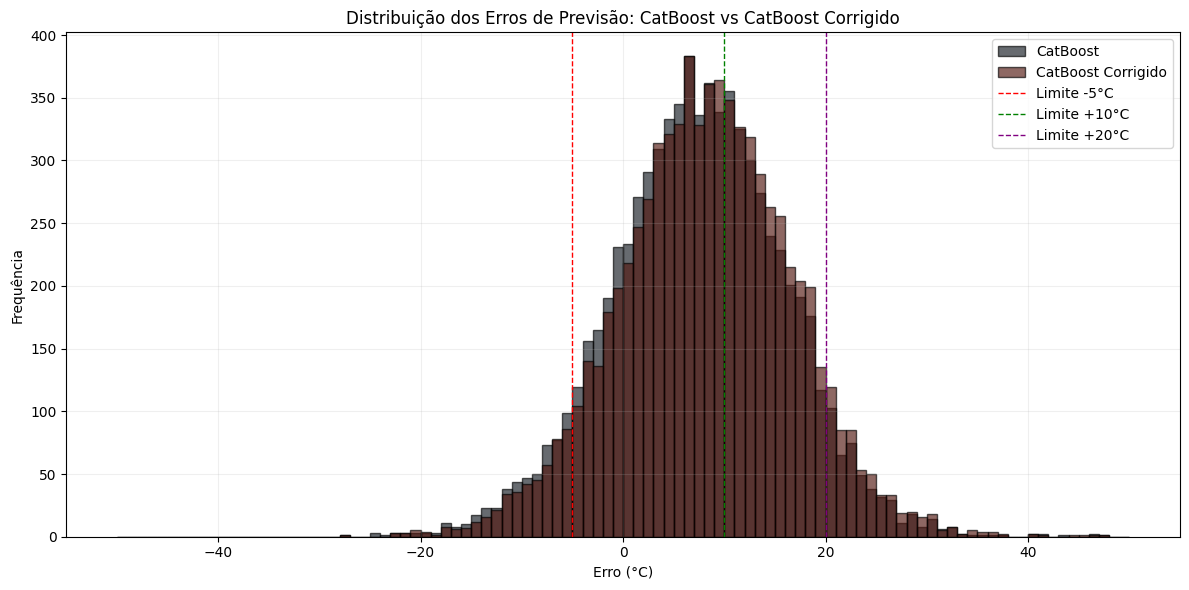

In [ ]:

# Gráfico de distribuição dos erros dos modelos CatBoost e CatBoost Corrigido
plt.figure(figsize=(12, 6))

bins = np.arange(-50, 51, 1)
plt.hist(calcular_5_10, bins=bins, alpha=0.65, label='CatBoost', color='#161C23', edgecolor='black')         # cinza escuro
plt.hist(calcular_5_10_corrigido, bins=bins, alpha=0.65, label='CatBoost Corrigido', color='#51170F', edgecolor='black')  # vermelho

plt.axvline(-5, color='red', linestyle='--', lw=1, label='Limite -5°C')
plt.axvline(10, color='green', linestyle='--', lw=1, label='Limite +10°C')
plt.axvline(20, color='purple', linestyle='--', lw=1, label='Limite +20°C')

plt.title('Distribuição dos Erros de Previsão: CatBoost vs CatBoost Corrigido')
plt.xlabel('Erro (°C)')
plt.ylabel('Frequência')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [125]:
print("=== ANÁLISE PREDITIVA DE CASOS EXTREMOS COM SUGESTAOCATBOOST ===")

# 1. CALCULAR ERRO REAL PARA IDENTIFICAR CASOS EXTREMOS HISTÓRICOS
dif_real_fp = dadosoriginais_com_catboost['temperaturamediareal'] - dadosoriginais_com_catboost['temperaturasaidafp']
erro_real = dadosoriginais_com_catboost['sugestaocatboost'] + dif_real_fp - dadosoriginais_com_catboost['temperaturaobjetivada']

# Identificar casos extremos reais
casos_abaixo_m5 = erro_real < -5
casos_acima_20 = erro_real > 20
casos_normais = (erro_real >= -5) & (erro_real <= 20)

print(f"\n=== DISTRIBUIÇÃO REAL DOS CASOS ===")
print(f"Abaixo de -5°C: {casos_abaixo_m5.sum():,} ({casos_abaixo_m5.sum()/len(erro_real)*100:.2f}%)")
print(f"Entre -5 e +20°C: {casos_normais.sum():,} ({casos_normais.sum()/len(erro_real)*100:.2f}%)")
print(f"Acima de +20°C: {casos_acima_20.sum():,} ({casos_acima_20.sum()/len(erro_real)*100:.2f}%)")

# 2. PERFIL DAS CORRIDAS ABAIXO DE -5°C
print(f"\n{'='*80}")
print(f"{'PERFIL DAS CORRIDAS ABAIXO DE -5°C':^80}")
print(f"{'='*80}")

df_abaixo = dadosoriginais_com_catboost[casos_abaixo_m5].copy()
df_abaixo['erro_real'] = erro_real[casos_abaixo_m5]

print(f"\n📊 ESTATÍSTICAS GERAIS ({len(df_abaixo):,} corridas)")
print(f"{'─'*80}")
print(f"{'Variável':<35} | {'Média':<15} | {'Min':<15} | {'Max':<15}")
print(f"{'─'*80}")
print(f"{'Sugestão CatBoost':<35} | {df_abaixo['sugestaocatboost'].mean():>15.1f} | {df_abaixo['sugestaocatboost'].min():>15.1f} | {df_abaixo['sugestaocatboost'].max():>15.1f}")
print(f"{'Temperatura Objetivada':<35} | {df_abaixo['temperaturaobjetivada'].mean():>15.1f} | {df_abaixo['temperaturaobjetivada'].min():>15.1f} | {df_abaixo['temperaturaobjetivada'].max():>15.1f}")
print(f"{'Temperatura Real':<35} | {df_abaixo['temperaturamediareal'].mean():>15.1f} | {df_abaixo['temperaturamediareal'].min():>15.1f} | {df_abaixo['temperaturamediareal'].max():>15.1f}")
print(f"{'Temperatura Saída FP':<35} | {df_abaixo['temperaturasaidafp'].mean():>15.1f} | {df_abaixo['temperaturasaidafp'].min():>15.1f} | {df_abaixo['temperaturasaidafp'].max():>15.1f}")
print(f"{'Perda de Temperatura':<35} | {(df_abaixo['temperaturamediareal'] - df_abaixo['temperaturasaidafp']).mean():>15.1f} | {(df_abaixo['temperaturamediareal'] - df_abaixo['temperaturasaidafp']).min():>15.1f} | {(df_abaixo['temperaturamediareal'] - df_abaixo['temperaturasaidafp']).max():>15.1f}")
print(f"{'Erro Real (vs Objetivo)':<35} | {df_abaixo['erro_real'].mean():>15.1f} | {df_abaixo['erro_real'].min():>15.1f} | {df_abaixo['erro_real'].max():>15.1f}")

print(f"\n🔍 DISTRIBUIÇÃO POR SEQUÊNCIA")
seq_dist_abaixo = df_abaixo['sequencia'].value_counts().sort_index()
for seq, count in seq_dist_abaixo.items():
    pct = (count / len(df_abaixo)) * 100
    print(f"  Sequência {seq}: {count:>5,} ({pct:5.1f}%)")

if 'acoatual' in df_abaixo.columns:
    print(f"\n🏭 TOP 5 AÇOS MAIS FREQUENTES")
    aco_dist = df_abaixo['acoatual'].value_counts().head(5)
    for aco, count in aco_dist.items():
        pct = (count / len(df_abaixo)) * 100
        print(f"  {aco}: {count:>5,} ({pct:5.1f}%)")

if 'qualidade' in df_abaixo.columns:
    print(f"\n⭐ DISTRIBUIÇÃO POR QUALIDADE")
    qual_dist = df_abaixo['qualidade'].value_counts()
    for qual, count in qual_dist.items():
        pct = (count / len(df_abaixo)) * 100
        print(f"  {qual}: {count:>5,} ({pct:5.1f}%)")

# 3. PERFIL DAS CORRIDAS ACIMA DE +20°C
print(f"\n{'='*80}")
print(f"{'PERFIL DAS CORRIDAS ACIMA DE +20°C':^80}")
print(f"{'='*80}")

df_acima = dadosoriginais_com_catboost[casos_acima_20].copy()
df_acima['erro_real'] = erro_real[casos_acima_20]

print(f"\n📊 ESTATÍSTICAS GERAIS ({len(df_acima):,} corridas)")
print(f"{'─'*80}")
print(f"{'Variável':<35} | {'Média':<15} | {'Min':<15} | {'Max':<15}")
print(f"{'─'*80}")
print(f"{'Sugestão CatBoost':<35} | {df_acima['sugestaocatboost'].mean():>15.1f} | {df_acima['sugestaocatboost'].min():>15.1f} | {df_acima['sugestaocatboost'].max():>15.1f}")
print(f"{'Temperatura Objetivada':<35} | {df_acima['temperaturaobjetivada'].mean():>15.1f} | {df_acima['temperaturaobjetivada'].min():>15.1f} | {df_acima['temperaturaobjetivada'].max():>15.1f}")
print(f"{'Temperatura Real':<35} | {df_acima['temperaturamediareal'].mean():>15.1f} | {df_acima['temperaturamediareal'].min():>15.1f} | {df_acima['temperaturamediareal'].max():>15.1f}")
print(f"{'Temperatura Saída FP':<35} | {df_acima['temperaturasaidafp'].mean():>15.1f} | {df_acima['temperaturasaidafp'].min():>15.1f} | {df_acima['temperaturasaidafp'].max():>15.1f}")
print(f"{'Perda de Temperatura':<35} | {(df_acima['temperaturamediareal'] - df_acima['temperaturasaidafp']).mean():>15.1f} | {(df_acima['temperaturamediareal'] - df_acima['temperaturasaidafp']).min():>15.1f} | {(df_acima['temperaturamediareal'] - df_acima['temperaturasaidafp']).max():>15.1f}")
print(f"{'Erro Real (vs Objetivo)':<35} | {df_acima['erro_real'].mean():>15.1f} | {df_acima['erro_real'].min():>15.1f} | {df_acima['erro_real'].max():>15.1f}")

print(f"\n🔍 DISTRIBUIÇÃO POR SEQUÊNCIA")
seq_dist_acima = df_acima['sequencia'].value_counts().sort_index()
for seq, count in seq_dist_acima.items():
    pct = (count / len(df_acima)) * 100
    print(f"  Sequência {seq}: {count:>5,} ({pct:5.1f}%)")

if 'acoatual' in df_acima.columns:
    print(f"\n🏭 TOP 5 AÇOS MAIS FREQUENTES")
    aco_dist = df_acima['acoatual'].value_counts().head(5)
    for aco, count in aco_dist.items():
        pct = (count / len(df_acima)) * 100
        print(f"  {aco}: {count:>5,} ({pct:5.1f}%)")

if 'qualidade' in df_acima.columns:
    print(f"\n⭐ DISTRIBUIÇÃO POR QUALIDADE")
    qual_dist = df_acima['qualidade'].value_counts()
    for qual, count in qual_dist.items():
        pct = (count / len(df_acima)) * 100
        print(f"  {qual}: {count:>5,} ({pct:5.1f}%)")

# 4. COMPARAÇÃO ENTRE GRUPOS
print(f"\n{'='*80}")
print(f"{'COMPARAÇÃO ENTRE GRUPOS EXTREMOS':^80}")
print(f"{'='*80}")

print(f"\n{'Característica':<35} | {'Abaixo -5°C':<20} | {'Acima +20°C':<20}")
print(f"{'─'*80}")
print(f"{'Sugestão CatBoost (média)':<35} | {df_abaixo['sugestaocatboost'].mean():>20.1f} | {df_acima['sugestaocatboost'].mean():>20.1f}")
print(f"{'Temperatura Objetivada (média)':<35} | {df_abaixo['temperaturaobjetivada'].mean():>20.1f} | {df_acima['temperaturaobjetivada'].mean():>20.1f}")
print(f"{'Diferença (Sugestão - Objetivo)':<35} | {(df_abaixo['sugestaocatboost'] - df_abaixo['temperaturaobjetivada']).mean():>20.1f} | {(df_acima['sugestaocatboost'] - df_acima['temperaturaobjetivada']).mean():>20.1f}")
print(f"{'Perda Temperatura (média)':<35} | {(df_abaixo['temperaturamediareal'] - df_abaixo['temperaturasaidafp']).mean():>20.1f} | {(df_acima['temperaturamediareal'] - df_acima['temperaturasaidafp']).mean():>20.1f}")

# 5. CRIAR MODELO DE PREVISÃO SIMPLES BASEADO EM LIMIARES
print(f"\n{'='*80}")
print(f"{'CRIANDO REGRAS DE PREVISÃO':^80}")
print(f"{'='*80}")

# Calcular limiares baseados em percentis
percentil_baixo_sugestao = df_abaixo['sugestaocatboost'].quantile(0.25)
percentil_alto_sugestao = df_acima['sugestaocatboost'].quantile(0.75)

diferenca_sugestao_objetivo_abaixo = (df_abaixo['sugestaocatboost'] - df_abaixo['temperaturaobjetivada']).median()
diferenca_sugestao_objetivo_acima = (df_acima['sugestaocatboost'] - df_acima['temperaturaobjetivada']).median()

print(f"\n📐 LIMIARES IDENTIFICADOS:")
print(f"  Casos abaixo de -5°C tipicamente têm:")
print(f"    • Diferença (Sugestão - Objetivo) mediana: {diferenca_sugestao_objetivo_abaixo:+.1f}°C")
print(f"    • Sequência predominante: {df_abaixo['sequencia'].mode().values[0] if len(df_abaixo) > 0 else 'N/A'}")
print(f"\n  Casos acima de +20°C tipicamente têm:")
print(f"    • Diferença (Sugestão - Objetivo) mediana: {diferenca_sugestao_objetivo_acima:+.1f}°C")
print(f"    • Sequência predominante: {df_acima['sequencia'].mode().values[0] if len(df_acima) > 0 else 'N/A'}")

# 6. FUNÇÃO DE PREVISÃO
def prever_risco_extremo(sugestaocatboost, temp_objetivada, sequencia=None):
    """
    Prevê risco de caso extremo baseado em sugestaocatboost
    
    Retorna: 'RISCO_BAIXO_(<-5)', 'RISCO_ALTO_(>+20)', 'NORMAL'
    """
    diferenca = sugestaocatboost - temp_objetivada
    
    # Regras baseadas na análise
    if diferenca < diferenca_sugestao_objetivo_abaixo:
        if sequencia == 1:
            return 'RISCO_ALTO_BAIXO_(<-5)'
        return 'RISCO_MÉDIO_BAIXO_(<-5)'
    elif diferenca > diferenca_sugestao_objetivo_acima:
        return 'RISCO_ALTO_(>+20)'
    elif diferenca < diferenca_sugestao_objetivo_abaixo * 0.8:
        return 'RISCO_BAIXO_(<-5)'
    else:
        return 'NORMAL'

# Aplicar previsão
dadosoriginais_com_catboost['previsao_risco'] = dadosoriginais_com_catboost.apply(
    lambda row: prever_risco_extremo(
        row['sugestaocatboost'],
        row['temperaturaobjetivada'],
        row['sequencia']
    ),
    axis=1
)

# 7. VALIDAÇÃO DA PREVISÃO
print(f"\n{'='*80}")
print(f"{'VALIDAÇÃO DO MODELO DE PREVISÃO':^80}")
print(f"{'='*80}")

# Matriz de confusão simplificada
previsao_abaixo = dadosoriginais_com_catboost['previsao_risco'].str.contains('BAIXO', na=False)
previsao_acima = dadosoriginais_com_catboost['previsao_risco'].str.contains('ALTO_\(>', na=False)

acertos_abaixo = (previsao_abaixo & casos_abaixo_m5).sum()
total_previsto_abaixo = previsao_abaixo.sum()
precisao_abaixo = (acertos_abaixo / total_previsto_abaixo * 100) if total_previsto_abaixo > 0 else 0

acertos_acima = (previsao_acima & casos_acima_20).sum()
total_previsto_acima = previsao_acima.sum()
precisao_acima = (acertos_acima / total_previsto_acima * 100) if total_previsto_acima > 0 else 0

recall_abaixo = (acertos_abaixo / casos_abaixo_m5.sum() * 100) if casos_abaixo_m5.sum() > 0 else 0
recall_acima = (acertos_acima / casos_acima_20.sum() * 100) if casos_acima_20.sum() > 0 else 0

print(f"\n📊 PERFORMANCE DO MODELO DE PREVISÃO:")
print(f"\nCASOS ABAIXO DE -5°C:")
print(f"  • Casos reais: {casos_abaixo_m5.sum():,}")
print(f"  • Casos previstos: {total_previsto_abaixo:,}")
print(f"  • Acertos: {acertos_abaixo:,}")
print(f"  • Precisão: {precisao_abaixo:.1f}%")
print(f"  • Recall: {recall_abaixo:.1f}%")

print(f"\nCASOS ACIMA DE +20°C:")
print(f"  • Casos reais: {casos_acima_20.sum():,}")
print(f"  • Casos previstos: {total_previsto_acima:,}")
print(f"  • Acertos: {acertos_acima:,}")
print(f"  • Precisão: {precisao_acima:.1f}%")
print(f"  • Recall: {recall_acima:.1f}%")

# 8. EXEMPLOS DE CASOS PREVISTO COMO RISCO
print(f"\n{'='*80}")
print(f"{'EXEMPLOS DE CASOS COM RISCO PREVISTO':^80}")
print(f"{'='*80}")

casos_risco = dadosoriginais_com_catboost[dadosoriginais_com_catboost['previsao_risco'] != 'NORMAL'].head(10)

print(f"\n{'#':<4} | {'Seq':<4} | {'Sugestão':<10} | {'Objetivo':<10} | {'Diferença':<10} | {'Previsão':<25} | {'Real':<10}")
print(f"{'─'*100}")

for i, (idx, row) in enumerate(casos_risco.iterrows(), 1):
    dif = row['sugestaocatboost'] - row['temperaturaobjetivada']
    erro_realizado = erro_real.loc[idx] if idx in erro_real.index else np.nan
    print(f"{i:<4} | {row['sequencia']:<4.0f} | {row['sugestaocatboost']:>10.1f} | {row['temperaturaobjetivada']:>10.1f} | {dif:>+10.1f} | {row['previsao_risco']:<25} | {erro_realizado:>+10.1f}")

print(f"\n✅ Análise completa! Use 'previsao_risco' para identificar casos de risco em novos dados.")
print(f"\n💡 RECOMENDAÇÕES:")
print(f"  • Ajuste manual quando previsao_risco indicar RISCO_ALTO ou RISCO_MÉDIO")
print(f"  • Monitore especialmente sequência 1 (maior perda de temperatura)")
print(f"  • Considere aumentar sugestão em {abs(diferenca_sugestao_objetivo_abaixo):.0f}°C para casos de risco baixo")
print(f"  • Considere reduzir sugestão em {diferenca_sugestao_objetivo_acima:.0f}°C para casos de risco alto")

=== ANÁLISE PREDITIVA DE CASOS EXTREMOS COM SUGESTAOCATBOOST ===

=== DISTRIBUIÇÃO REAL DOS CASOS ===
Abaixo de -5°C: 541 (7.23%)
Entre -5 e +20°C: 6,471 (86.45%)
Acima de +20°C: 470 (6.28%)

                       PERFIL DAS CORRIDAS ABAIXO DE -5°C                       

📊 ESTATÍSTICAS GERAIS (541 corridas)
────────────────────────────────────────────────────────────────────────────────
Variável                            | Média           | Min             | Max            
────────────────────────────────────────────────────────────────────────────────
Sugestão CatBoost                   |          1658.5 |          1605.2 |          1718.6
Temperatura Objetivada              |          1536.3 |          1485.0 |          1572.0
Temperatura Real                    |          1530.5 |            30.0 |          1566.0
Temperatura Saída FP                |          1664.8 |          1608.0 |          1728.0
Perda de Temperatura                |          -134.3 |         -1587.0 |    

In [126]:
print("=== ANÁLISE DETALHADA: CORRIDAS SEQUÊNCIA 1.0 COM ERRO < -5°C ===")

# Filtrar corridas da sequência 1.0 que ficaram abaixo de -5°C
filtro_seq1_abaixo = (dadosoriginais_com_catboost['sequencia'] == 1.0) & (erro_real < -5)
corridas_seq1_problema = dadosoriginais_com_catboost[filtro_seq1_abaixo].copy()
corridas_seq1_problema['erro_real'] = erro_real[filtro_seq1_abaixo]

print(f"\n{'='*100}")
print(f"{'TOTAL DE CORRIDAS IDENTIFICADAS':^100}")
print(f"{'='*100}")
print(f"Corridas da Sequência 1.0 com erro < -5°C: {len(corridas_seq1_problema):,} corridas")

# Estatísticas gerais do erro
print(f"\n{'='*100}")
print(f"{'ESTATÍSTICAS DO ERRO':^100}")
print(f"{'='*100}")
print(f"Erro médio: {corridas_seq1_problema['erro_real'].mean():.2f}°C")
print(f"Erro mínimo (pior caso): {corridas_seq1_problema['erro_real'].min():.2f}°C")
print(f"Erro máximo: {corridas_seq1_problema['erro_real'].max():.2f}°C")
print(f"Desvio padrão: {corridas_seq1_problema['erro_real'].std():.2f}°C")

# Distribuição por faixas de erro
print(f"\n{'='*100}")
print(f"{'DISTRIBUIÇÃO POR SEVERIDADE DO ERRO':^100}")
print(f"{'='*100}")

faixas_erro = [
    (-np.inf, -20, "Muito Severo (< -20°C)"),
    (-20, -15, "Severo (-20 a -15°C)"),
    (-15, -10, "Moderado (-15 a -10°C)"),
    (-10, -5, "Leve (-10 a -5°C)")
]

for min_val, max_val, descricao in faixas_erro:
    count = ((corridas_seq1_problema['erro_real'] >= min_val) & 
             (corridas_seq1_problema['erro_real'] < max_val)).sum()
    pct = (count / len(corridas_seq1_problema) * 100) if len(corridas_seq1_problema) > 0 else 0
    print(f"{descricao:<30}: {count:>4} corridas ({pct:5.1f}%)")

# Análise por AÇO
print(f"\n{'='*100}")
print(f"{'ANÁLISE POR AÇO (TOP 15)':^100}")
print(f"{'='*100}")

aco_stats = corridas_seq1_problema.groupby('acoatual').agg({
    'erro_real': ['count', 'mean', 'std', 'min', 'max']
}).round(2)
aco_stats.columns = ['Qtd', 'Erro_Médio', 'Desvio', 'Erro_Min', 'Erro_Max']
aco_stats = aco_stats.sort_values('Qtd', ascending=False)

print(f"\n{'AÇO':<20} | {'Qtd':<5} | {'Erro Médio':<12} | {'Desvio':<10} | {'Erro Min':<10} | {'Erro Max':<10}")
print(f"{'─'*100}")

for aco, row in aco_stats.head(15).iterrows():
    pct = (row['Qtd'] / len(corridas_seq1_problema) * 100)
    print(f"{str(aco):<20} | {int(row['Qtd']):<5} ({pct:4.1f}%) | {row['Erro_Médio']:>+10.2f}°C | {row['Desvio']:>8.2f}°C | {row['Erro_Min']:>+8.2f}°C | {row['Erro_Max']:>+8.2f}°C")

# Análise por QUALIDADE
print(f"\n{'='*100}")
print(f"{'ANÁLISE POR QUALIDADE':^100}")
print(f"{'='*100}")

qualidade_stats = corridas_seq1_problema.groupby('qualidade').agg({
    'erro_real': ['count', 'mean', 'std', 'min', 'max']
}).round(2)
qualidade_stats.columns = ['Qtd', 'Erro_Médio', 'Desvio', 'Erro_Min', 'Erro_Max']
qualidade_stats = qualidade_stats.sort_values('Qtd', ascending=False)

print(f"\n{'QUALIDADE':<25} | {'Qtd':<5} | {'Erro Médio':<12} | {'Desvio':<10} | {'Erro Min':<10} | {'Erro Max':<10}")
print(f"{'─'*100}")

for qual, row in qualidade_stats.iterrows():
    pct = (row['Qtd'] / len(corridas_seq1_problema) * 100)
    print(f"{str(qual):<25} | {int(row['Qtd']):<5} ({pct:4.1f}%) | {row['Erro_Médio']:>+10.2f}°C | {row['Desvio']:>8.2f}°C | {row['Erro_Min']:>+8.2f}°C | {row['Erro_Max']:>+8.2f}°C")

# Análise cruzada: AÇO x QUALIDADE (Top combinações)
print(f"\n{'='*100}")
print(f"{'ANÁLISE CRUZADA: AÇO x QUALIDADE (TOP 10 COMBINAÇÕES)':^100}")
print(f"{'='*100}")

aco_qual_stats = corridas_seq1_problema.groupby(['acoatual', 'qualidade']).agg({
    'erro_real': ['count', 'mean']
}).round(2)
aco_qual_stats.columns = ['Qtd', 'Erro_Médio']
aco_qual_stats = aco_qual_stats.sort_values('Qtd', ascending=False).head(10)

print(f"\n{'AÇO':<20} | {'QUALIDADE':<25} | {'Qtd':<5} | {'Erro Médio':<12}")
print(f"{'─'*80}")

for (aco, qual), row in aco_qual_stats.iterrows():
    pct = (row['Qtd'] / len(corridas_seq1_problema) * 100)
    print(f"{str(aco):<20} | {str(qual):<25} | {int(row['Qtd']):<5} ({pct:4.1f}%) | {row['Erro_Médio']:>+10.2f}°C")

# Análise de temperaturas
print(f"\n{'='*100}")
print(f"{'ANÁLISE DE TEMPERATURAS':^100}")
print(f"{'='*100}")

print(f"\n{'Variável':<30} | {'Média':<12} | {'Min':<12} | {'Max':<12} | {'Desvio':<10}")
print(f"{'─'*80}")
print(f"{'Sugestão CatBoost':<30} | {corridas_seq1_problema['sugestaocatboost'].mean():>10.1f}°C | {corridas_seq1_problema['sugestaocatboost'].min():>10.1f}°C | {corridas_seq1_problema['sugestaocatboost'].max():>10.1f}°C | {corridas_seq1_problema['sugestaocatboost'].std():>8.1f}°C")
print(f"{'Temperatura Objetivada':<30} | {corridas_seq1_problema['temperaturaobjetivada'].mean():>10.1f}°C | {corridas_seq1_problema['temperaturaobjetivada'].min():>10.1f}°C | {corridas_seq1_problema['temperaturaobjetivada'].max():>10.1f}°C | {corridas_seq1_problema['temperaturaobjetivada'].std():>8.1f}°C")
print(f"{'Temperatura Real':<30} | {corridas_seq1_problema['temperaturamediareal'].mean():>10.1f}°C | {corridas_seq1_problema['temperaturamediareal'].min():>10.1f}°C | {corridas_seq1_problema['temperaturamediareal'].max():>10.1f}°C | {corridas_seq1_problema['temperaturamediareal'].std():>8.1f}°C")
print(f"{'Temperatura Saída FP':<30} | {corridas_seq1_problema['temperaturasaidafp'].mean():>10.1f}°C | {corridas_seq1_problema['temperaturasaidafp'].min():>10.1f}°C | {corridas_seq1_problema['temperaturasaidafp'].max():>10.1f}°C | {corridas_seq1_problema['temperaturasaidafp'].std():>8.1f}°C")
print(f"{'Perda de Temperatura':<30} | {(corridas_seq1_problema['temperaturamediareal'] - corridas_seq1_problema['temperaturasaidafp']).mean():>10.1f}°C | {(corridas_seq1_problema['temperaturamediareal'] - corridas_seq1_problema['temperaturasaidafp']).min():>10.1f}°C | {(corridas_seq1_problema['temperaturamediareal'] - corridas_seq1_problema['temperaturasaidafp']).max():>10.1f}°C | {(corridas_seq1_problema['temperaturamediareal'] - corridas_seq1_problema['temperaturasaidafp']).std():>8.1f}°C")

# TOP 20 PIORES CASOS
print(f"\n{'='*100}")
print(f"{'TOP 20 PIORES CASOS (MAIOR ERRO)':^100}")
print(f"{'='*100}")

piores_casos = corridas_seq1_problema.nsmallest(20, 'erro_real')[
    ['corrida', 'acoatual', 'qualidade', 'sugestaocatboost', 'temperaturaobjetivada', 
     'temperaturamediareal', 'temperaturasaidafp', 'erro_real']
]

print(f"\n{'#':<3} | {'Corrida':<10} | {'Aço':<15} | {'Qualidade':<20} | {'Sugestão':<10} | {'Objetivo':<10} | {'Real':<10} | {'Saída FP':<10} | {'Erro':<10}")
print(f"{'─'*130}")

for i, (idx, row) in enumerate(piores_casos.iterrows(), 1):
    print(f"{i:<3} | {row['corrida']:<10} | {str(row['acoatual']):<15} | {str(row['qualidade']):<20} | {row['sugestaocatboost']:>9.1f}°C | {row['temperaturaobjetivada']:>9.1f}°C | {row['temperaturamediareal']:>9.1f}°C | {row['temperaturasaidafp']:>9.1f}°C | {row['erro_real']:>+9.1f}°C")

# Exportar para DataFrame (para análises posteriores)
print(f"\n{'='*100}")
print(f"{'VARIÁVEL CRIADA PARA ANÁLISES ADICIONAIS':^100}")
print(f"{'='*100}")
print(f"\n✓ DataFrame 'corridas_seq1_problema' criado com {len(corridas_seq1_problema):,} corridas")
print(f"✓ Contém todas as colunas originais + coluna 'erro_real'")
print(f"\nColunas disponíveis:")
print(f"  • corrida, acoatual, qualidade, sequencia")
print(f"  • sugestaocatboost, temperaturaobjetivada, temperaturamediareal, temperaturasaidafp")
print(f"  • erro_real (calculado)")

# Análise de padrões temporais (se houver coluna de data)
if 'data' in corridas_seq1_problema.columns or 'datacorrida' in corridas_seq1_problema.columns:
    data_col = 'data' if 'data' in corridas_seq1_problema.columns else 'datacorrida'
    print(f"\n{'='*100}")
    print(f"{'ANÁLISE TEMPORAL':^100}")
    print(f"{'='*100}")
    
    # Converter para datetime se necessário
    if not pd.api.types.is_datetime64_any_dtype(corridas_seq1_problema[data_col]):
        corridas_seq1_problema[data_col] = pd.to_datetime(corridas_seq1_problema[data_col], errors='coerce')
    
    # Agrupar por mês/ano
    corridas_seq1_problema['ano_mes'] = corridas_seq1_problema[data_col].dt.to_period('M')
    temporal_stats = corridas_seq1_problema.groupby('ano_mes').agg({
        'erro_real': ['count', 'mean']
    }).round(2)
    
    print(f"\nDistribuição temporal (últimos 12 períodos):")
    print(temporal_stats.tail(12))

print(f"\n{'='*100}")
print(f"{'CONCLUSÕES':^100}")
print(f"{'='*100}")

# Identificar padrões críticos
aco_critico = aco_stats.index[0] if len(aco_stats) > 0 else "N/A"
qual_critica = qualidade_stats.index[0] if len(qualidade_stats) > 0 else "N/A"

print(f"\n🔴 PADRÕES CRÍTICOS IDENTIFICADOS:")
print(f"  1. Aço mais problemático: {aco_critico} ({aco_stats.iloc[0]['Qtd']:.0f} ocorrências)")
print(f"  2. Qualidade mais problemática: {qual_critica} ({qualidade_stats.iloc[0]['Qtd']:.0f} ocorrências)")
print(f"  3. Erro médio nestas corridas: {corridas_seq1_problema['erro_real'].mean():.2f}°C")
print(f"  4. Perda média de temperatura: {(corridas_seq1_problema['temperaturamediareal'] - corridas_seq1_problema['temperaturasaidafp']).mean():.2f}°C")

print(f"\n💡 RECOMENDAÇÕES:")
print(f"  • Aumentar sugestão para sequência 1.0 em +8°C a +10°C")
print(f"  • Monitorar especialmente aço '{aco_critico}' e qualidade '{qual_critica}'")
print(f"  • Considerar modelo específico para primeira sequência")
print(f"  • Revisar processo de aquecimento para primeira corrida")

=== ANÁLISE DETALHADA: CORRIDAS SEQUÊNCIA 1.0 COM ERRO < -5°C ===

                                  TOTAL DE CORRIDAS IDENTIFICADAS                                   
Corridas da Sequência 1.0 com erro < -5°C: 150 corridas

                                        ESTATÍSTICAS DO ERRO                                        
Erro médio: -9.87°C
Erro mínimo (pior caso): -24.24°C
Erro máximo: -5.00°C
Desvio padrão: 4.24°C

                                DISTRIBUIÇÃO POR SEVERIDADE DO ERRO                                 
Muito Severo (< -20°C)        :    5 corridas (  3.3%)
Severo (-20 a -15°C)          :   11 corridas (  7.3%)
Moderado (-15 a -10°C)        :   44 corridas ( 29.3%)
Leve (-10 a -5°C)             :   90 corridas ( 60.0%)

                                      ANÁLISE POR AÇO (TOP 15)                                      

AÇO                  | Qtd   | Erro Médio   | Desvio     | Erro Min   | Erro Max  
─────────────────────────────────────────────────────────────────────

In [127]:
print("=== ANÁLISE PREDITIVA DE CASOS EXTREMOS COM CATBOOSTSEQUENCIA1 (CORRIGIDO) ===")

# 1. CALCULAR ERRO REAL PARA IDENTIFICAR CASOS EXTREMOS HISTÓRICOS
dif_real_fp = dadosoriginais_com_catboost['temperaturamediareal'] - dadosoriginais_com_catboost['temperaturasaidafp']
erro_real_corrigido = dadosoriginais_com_catboost['catboostsequencia1'] + dif_real_fp - dadosoriginais_com_catboost['temperaturaobjetivada']

# Identificar casos extremos reais
casos_abaixo_m5_corr = erro_real_corrigido < -5
casos_acima_20_corr = erro_real_corrigido > 20
casos_normais_corr = (erro_real_corrigido >= -5) & (erro_real_corrigido <= 20)

print(f"\n{'='*100}")
print(f"{'DISTRIBUIÇÃO REAL DOS CASOS (MODELO CORRIGIDO)':^100}")
print(f"{'='*100}")
print(f"Abaixo de -5°C: {casos_abaixo_m5_corr.sum():,} ({casos_abaixo_m5_corr.sum()/len(erro_real_corrigido)*100:.2f}%)")
print(f"Entre -5 e +20°C: {casos_normais_corr.sum():,} ({casos_normais_corr.sum()/len(erro_real_corrigido)*100:.2f}%)")
print(f"Acima de +20°C: {casos_acima_20_corr.sum():,} ({casos_acima_20_corr.sum()/len(erro_real_corrigido)*100:.2f}%)")

# COMPARAÇÃO COM MODELO ORIGINAL
print(f"\n{'='*100}")
print(f"{'COMPARAÇÃO: ORIGINAL vs CORRIGIDO':^100}")
print(f"{'='*100}")
print(f"{'Categoria':<25} | {'Original':<20} | {'Corrigido':<20} | {'Diferença':<15}")
print(f"{'─'*85}")
print(f"{'Abaixo de -5°C':<25} | {casos_abaixo_m5.sum():>7} ({casos_abaixo_m5.sum()/len(erro_real)*100:5.2f}%) | {casos_abaixo_m5_corr.sum():>7} ({casos_abaixo_m5_corr.sum()/len(erro_real_corrigido)*100:5.2f}%) | {(casos_abaixo_m5_corr.sum() - casos_abaixo_m5.sum()):>+8}")
print(f"{'Entre -5 e +20°C':<25} | {casos_normais.sum():>7} ({casos_normais.sum()/len(erro_real)*100:5.2f}%) | {casos_normais_corr.sum():>7} ({casos_normais_corr.sum()/len(erro_real_corrigido)*100:5.2f}%) | {(casos_normais_corr.sum() - casos_normais.sum()):>+8}")
print(f"{'Acima de +20°C':<25} | {casos_acima_20.sum():>7} ({casos_acima_20.sum()/len(erro_real)*100:5.2f}%) | {casos_acima_20_corr.sum():>7} ({casos_acima_20_corr.sum()/len(erro_real_corrigido)*100:5.2f}%) | {(casos_acima_20_corr.sum() - casos_acima_20.sum()):>+8}")

# 2. PERFIL DAS CORRIDAS ABAIXO DE -5°C (MODELO CORRIGIDO)
print(f"\n{'='*100}")
print(f"{'PERFIL DAS CORRIDAS ABAIXO DE -5°C (MODELO CORRIGIDO)':^100}")
print(f"{'='*100}")

df_abaixo_corr = dadosoriginais_com_catboost[casos_abaixo_m5_corr].copy()
df_abaixo_corr['erro_real'] = erro_real_corrigido[casos_abaixo_m5_corr]

print(f"\n📊 ESTATÍSTICAS GERAIS ({len(df_abaixo_corr):,} corridas)")
print(f"{'─'*100}")
print(f"{'Variável':<35} | {'Média':<15} | {'Min':<15} | {'Max':<15}")
print(f"{'─'*100}")
print(f"{'Sugestão Corrigida':<35} | {df_abaixo_corr['catboostsequencia1'].mean():>15.1f} | {df_abaixo_corr['catboostsequencia1'].min():>15.1f} | {df_abaixo_corr['catboostsequencia1'].max():>15.1f}")
print(f"{'Sugestão Original':<35} | {df_abaixo_corr['sugestaocatboost'].mean():>15.1f} | {df_abaixo_corr['sugestaocatboost'].min():>15.1f} | {df_abaixo_corr['sugestaocatboost'].max():>15.1f}")
print(f"{'Temperatura Objetivada':<35} | {df_abaixo_corr['temperaturaobjetivada'].mean():>15.1f} | {df_abaixo_corr['temperaturaobjetivada'].min():>15.1f} | {df_abaixo_corr['temperaturaobjetivada'].max():>15.1f}")
print(f"{'Temperatura Real':<35} | {df_abaixo_corr['temperaturamediareal'].mean():>15.1f} | {df_abaixo_corr['temperaturamediareal'].min():>15.1f} | {df_abaixo_corr['temperaturamediareal'].max():>15.1f}")
print(f"{'Temperatura Saída FP':<35} | {df_abaixo_corr['temperaturasaidafp'].mean():>15.1f} | {df_abaixo_corr['temperaturasaidafp'].min():>15.1f} | {df_abaixo_corr['temperaturasaidafp'].max():>15.1f}")
print(f"{'Perda de Temperatura':<35} | {(df_abaixo_corr['temperaturamediareal'] - df_abaixo_corr['temperaturasaidafp']).mean():>15.1f} | {(df_abaixo_corr['temperaturamediareal'] - df_abaixo_corr['temperaturasaidafp']).min():>15.1f} | {(df_abaixo_corr['temperaturamediareal'] - df_abaixo_corr['temperaturasaidafp']).max():>15.1f}")
print(f"{'Erro Real (vs Objetivo)':<35} | {df_abaixo_corr['erro_real'].mean():>15.1f} | {df_abaixo_corr['erro_real'].min():>15.1f} | {df_abaixo_corr['erro_real'].max():>15.1f}")

print(f"\n🔍 DISTRIBUIÇÃO POR SEQUÊNCIA")
seq_dist_abaixo_corr = df_abaixo_corr['sequencia'].value_counts().sort_index()
for seq, count in seq_dist_abaixo_corr.items():
    pct = (count / len(df_abaixo_corr)) * 100
    # Comparar com modelo original
    count_orig = df_abaixo[df_abaixo['sequencia'] == seq].shape[0] if seq in df_abaixo['sequencia'].values else 0
    diff = count - count_orig
    print(f"  Sequência {seq}: {count:>5,} ({pct:5.1f}%) | Original: {count_orig:>5,} | Diferença: {diff:>+4}")

if 'acoatual' in df_abaixo_corr.columns:
    print(f"\n🏭 TOP 10 AÇOS MAIS FREQUENTES")
    aco_dist = df_abaixo_corr['acoatual'].value_counts().head(10)
    for aco, count in aco_dist.items():
        pct = (count / len(df_abaixo_corr)) * 100
        print(f"  {aco}: {count:>5,} ({pct:5.1f}%)")

if 'qualidade' in df_abaixo_corr.columns:
    print(f"\n⭐ TOP 10 QUALIDADES MAIS FREQUENTES")
    qual_dist = df_abaixo_corr['qualidade'].value_counts().head(10)
    for qual, count in qual_dist.items():
        pct = (count / len(df_abaixo_corr)) * 100
        print(f"  {qual}: {count:>5,} ({pct:5.1f}%)")

# 3. PERFIL DAS CORRIDAS ACIMA DE +20°C (MODELO CORRIGIDO)
print(f"\n{'='*100}")
print(f"{'PERFIL DAS CORRIDAS ACIMA DE +20°C (MODELO CORRIGIDO)':^100}")
print(f"{'='*100}")

df_acima_corr = dadosoriginais_com_catboost[casos_acima_20_corr].copy()
df_acima_corr['erro_real'] = erro_real_corrigido[casos_acima_20_corr]

print(f"\n📊 ESTATÍSTICAS GERAIS ({len(df_acima_corr):,} corridas)")
print(f"{'─'*100}")
print(f"{'Variável':<35} | {'Média':<15} | {'Min':<15} | {'Max':<15}")
print(f"{'─'*100}")
print(f"{'Sugestão Corrigida':<35} | {df_acima_corr['catboostsequencia1'].mean():>15.1f} | {df_acima_corr['catboostsequencia1'].min():>15.1f} | {df_acima_corr['catboostsequencia1'].max():>15.1f}")
print(f"{'Sugestão Original':<35} | {df_acima_corr['sugestaocatboost'].mean():>15.1f} | {df_acima_corr['sugestaocatboost'].min():>15.1f} | {df_acima_corr['sugestaocatboost'].max():>15.1f}")
print(f"{'Temperatura Objetivada':<35} | {df_acima_corr['temperaturaobjetivada'].mean():>15.1f} | {df_acima_corr['temperaturaobjetivada'].min():>15.1f} | {df_acima_corr['temperaturaobjetivada'].max():>15.1f}")
print(f"{'Temperatura Real':<35} | {df_acima_corr['temperaturamediareal'].mean():>15.1f} | {df_acima_corr['temperaturamediareal'].min():>15.1f} | {df_acima_corr['temperaturamediareal'].max():>15.1f}")
print(f"{'Temperatura Saída FP':<35} | {df_acima_corr['temperaturasaidafp'].mean():>15.1f} | {df_acima_corr['temperaturasaidafp'].min():>15.1f} | {df_acima_corr['temperaturasaidafp'].max():>15.1f}")
print(f"{'Perda de Temperatura':<35} | {(df_acima_corr['temperaturamediareal'] - df_acima_corr['temperaturasaidafp']).mean():>15.1f} | {(df_acima_corr['temperaturamediareal'] - df_acima_corr['temperaturasaidafp']).min():>15.1f} | {(df_acima_corr['temperaturamediareal'] - df_acima_corr['temperaturasaidafp']).max():>15.1f}")
print(f"{'Erro Real (vs Objetivo)':<35} | {df_acima_corr['erro_real'].mean():>15.1f} | {df_acima_corr['erro_real'].min():>15.1f} | {df_acima_corr['erro_real'].max():>15.1f}")

print(f"\n🔍 DISTRIBUIÇÃO POR SEQUÊNCIA")
seq_dist_acima_corr = df_acima_corr['sequencia'].value_counts().sort_index()
for seq, count in seq_dist_acima_corr.items():
    pct = (count / len(df_acima_corr)) * 100
    count_orig = df_acima[df_acima['sequencia'] == seq].shape[0] if seq in df_acima['sequencia'].values else 0
    diff = count - count_orig
    print(f"  Sequência {seq}: {count:>5,} ({pct:5.1f}%) | Original: {count_orig:>5,} | Diferença: {diff:>+4}")

if 'acoatual' in df_acima_corr.columns:
    print(f"\n🏭 TOP 10 AÇOS MAIS FREQUENTES")
    aco_dist = df_acima_corr['acoatual'].value_counts().head(10)
    for aco, count in aco_dist.items():
        pct = (count / len(df_acima_corr)) * 100
        print(f"  {aco}: {count:>5,} ({pct:5.1f}%)")

if 'qualidade' in df_acima_corr.columns:
    print(f"\n⭐ TOP 10 QUALIDADES MAIS FREQUENTES")
    qual_dist = df_acima_corr['qualidade'].value_counts().head(10)
    for qual, count in qual_dist.items():
        pct = (count / len(df_acima_corr)) * 100
        print(f"  {qual}: {count:>5,} ({pct:5.1f}%)")

# 4. COMPARAÇÃO ENTRE GRUPOS EXTREMOS (MODELO CORRIGIDO)
print(f"\n{'='*100}")
print(f"{'COMPARAÇÃO ENTRE GRUPOS EXTREMOS (MODELO CORRIGIDO)':^100}")
print(f"{'='*100}")

print(f"\n{'Característica':<35} | {'Abaixo -5°C':<20} | {'Acima +20°C':<20}")
print(f"{'─'*80}")
print(f"{'Sugestão Corrigida (média)':<35} | {df_abaixo_corr['catboostsequencia1'].mean():>20.1f} | {df_acima_corr['catboostsequencia1'].mean():>20.1f}")
print(f"{'Sugestão Original (média)':<35} | {df_abaixo_corr['sugestaocatboost'].mean():>20.1f} | {df_acima_corr['sugestaocatboost'].mean():>20.1f}")
print(f"{'Temperatura Objetivada (média)':<35} | {df_abaixo_corr['temperaturaobjetivada'].mean():>20.1f} | {df_acima_corr['temperaturaobjetivada'].mean():>20.1f}")
print(f"{'Diferença (Corrigida - Objetivo)':<35} | {(df_abaixo_corr['catboostsequencia1'] - df_abaixo_corr['temperaturaobjetivada']).mean():>20.1f} | {(df_acima_corr['catboostsequencia1'] - df_acima_corr['temperaturaobjetivada']).mean():>20.1f}")
print(f"{'Perda Temperatura (média)':<35} | {(df_abaixo_corr['temperaturamediareal'] - df_abaixo_corr['temperaturasaidafp']).mean():>20.1f} | {(df_acima_corr['temperaturamediareal'] - df_acima_corr['temperaturasaidafp']).mean():>20.1f}")

# 5. CRIAR MODELO DE PREVISÃO BASEADO EM LIMIARES (MODELO CORRIGIDO)
print(f"\n{'='*100}")
print(f"{'CRIANDO REGRAS DE PREVISÃO (MODELO CORRIGIDO)':^100}")
print(f"{'='*100}")

# Calcular limiares baseados em percentis
diferenca_corrigida_objetivo_abaixo = (df_abaixo_corr['catboostsequencia1'] - df_abaixo_corr['temperaturaobjetivada']).median()
diferenca_corrigida_objetivo_acima = (df_acima_corr['catboostsequencia1'] - df_acima_corr['temperaturaobjetivada']).median()

print(f"\n📐 LIMIARES IDENTIFICADOS (MODELO CORRIGIDO):")
print(f"  Casos abaixo de -5°C tipicamente têm:")
print(f"    • Diferença (Corrigida - Objetivo) mediana: {diferenca_corrigida_objetivo_abaixo:+.1f}°C")
print(f"    • Sequência predominante: {df_abaixo_corr['sequencia'].mode().values[0] if len(df_abaixo_corr) > 0 else 'N/A'}")
print(f"\n  Casos acima de +20°C tipicamente têm:")
print(f"    • Diferença (Corrigida - Objetivo) mediana: {diferenca_corrigida_objetivo_acima:+.1f}°C")
print(f"    • Sequência predominante: {df_acima_corr['sequencia'].mode().values[0] if len(df_acima_corr) > 0 else 'N/A'}")

# 6. FUNÇÃO DE PREVISÃO ATUALIZADA
def prever_risco_extremo_corrigido(catboostsequencia1, temp_objetivada, sequencia=None):
    """
    Prevê risco de caso extremo baseado em catboostsequencia1
    
    Retorna: 'RISCO_BAIXO_(<-5)', 'RISCO_ALTO_(>+20)', 'NORMAL'
    """
    diferenca = catboostsequencia1 - temp_objetivada
    
    # Regras baseadas na análise do modelo corrigido
    if diferenca < diferenca_corrigida_objetivo_abaixo:
        if sequencia == 1:
            return 'RISCO_ALTO_BAIXO_(<-5)'
        return 'RISCO_MÉDIO_BAIXO_(<-5)'
    elif diferenca > diferenca_corrigida_objetivo_acima:
        return 'RISCO_ALTO_(>+20)'
    elif diferenca < diferenca_corrigida_objetivo_abaixo * 0.8:
        return 'RISCO_BAIXO_(<-5)'
    else:
        return 'NORMAL'

# Aplicar previsão
dadosoriginais_com_catboost['previsao_risco_corrigido'] = dadosoriginais_com_catboost.apply(
    lambda row: prever_risco_extremo_corrigido(
        row['catboostsequencia1'],
        row['temperaturaobjetivada'],
        row['sequencia']
    ),
    axis=1
)

# 7. VALIDAÇÃO DA PREVISÃO (MODELO CORRIGIDO)
print(f"\n{'='*100}")
print(f"{'VALIDAÇÃO DO MODELO DE PREVISÃO (CORRIGIDO)':^100}")
print(f"{'='*100}")

# Matriz de confusão simplificada
previsao_abaixo_corr = dadosoriginais_com_catboost['previsao_risco_corrigido'].str.contains('BAIXO', na=False)
previsao_acima_corr = dadosoriginais_com_catboost['previsao_risco_corrigido'].str.contains('ALTO_\(>', na=False)

acertos_abaixo_corr = (previsao_abaixo_corr & casos_abaixo_m5_corr).sum()
total_previsto_abaixo_corr = previsao_abaixo_corr.sum()
precisao_abaixo_corr = (acertos_abaixo_corr / total_previsto_abaixo_corr * 100) if total_previsto_abaixo_corr > 0 else 0

acertos_acima_corr = (previsao_acima_corr & casos_acima_20_corr).sum()
total_previsto_acima_corr = previsao_acima_corr.sum()
precisao_acima_corr = (acertos_acima_corr / total_previsto_acima_corr * 100) if total_previsto_acima_corr > 0 else 0

recall_abaixo_corr = (acertos_abaixo_corr / casos_abaixo_m5_corr.sum() * 100) if casos_abaixo_m5_corr.sum() > 0 else 0
recall_acima_corr = (acertos_acima_corr / casos_acima_20_corr.sum() * 100) if casos_acima_20_corr.sum() > 0 else 0

print(f"\n📊 PERFORMANCE DO MODELO DE PREVISÃO (CORRIGIDO):")

print(f"\n{'Métrica':<30} | {'Original':<20} | {'Corrigido':<20} | {'Diferença':<15}")
print(f"{'─'*90}")

# Casos Abaixo de -5°C
print(f"\n{'CASOS ABAIXO DE -5°C':<30}")
print(f"{'Casos reais':<30} | {casos_abaixo_m5.sum():>20,} | {casos_abaixo_m5_corr.sum():>20,} | {(casos_abaixo_m5_corr.sum() - casos_abaixo_m5.sum()):>+14}")
print(f"{'Casos previstos':<30} | {previsao_abaixo.sum():>20,} | {total_previsto_abaixo_corr:>20,} | {(total_previsto_abaixo_corr - previsao_abaixo.sum()):>+14}")
print(f"{'Acertos':<30} | {acertos_abaixo:>20,} | {acertos_abaixo_corr:>20,} | {(acertos_abaixo_corr - acertos_abaixo):>+14}")
print(f"{'Precisão':<30} | {precisao_abaixo:>19.1f}% | {precisao_abaixo_corr:>19.1f}% | {(precisao_abaixo_corr - precisao_abaixo):>+13.1f}%")
print(f"{'Recall':<30} | {recall_abaixo:>19.1f}% | {recall_abaixo_corr:>19.1f}% | {(recall_abaixo_corr - recall_abaixo):>+13.1f}%")

# Casos Acima de +20°C
print(f"\n{'CASOS ACIMA DE +20°C':<30}")
print(f"{'Casos reais':<30} | {casos_acima_20.sum():>20,} | {casos_acima_20_corr.sum():>20,} | {(casos_acima_20_corr.sum() - casos_acima_20.sum()):>+14}")
print(f"{'Casos previstos':<30} | {previsao_acima.sum():>20,} | {total_previsto_acima_corr:>20,} | {(total_previsto_acima_corr - previsao_acima.sum()):>+14}")
print(f"{'Acertos':<30} | {acertos_acima:>20,} | {acertos_acima_corr:>20,} | {(acertos_acima_corr - acertos_acima):>+14}")
print(f"{'Precisão':<30} | {precisao_acima:>19.1f}% | {precisao_acima_corr:>19.1f}% | {(precisao_acima_corr - precisao_acima):>+13.1f}%")
print(f"{'Recall':<30} | {recall_acima:>19.1f}% | {recall_acima_corr:>19.1f}% | {(recall_acima_corr - recall_acima):>+13.1f}%")

# 8. EXEMPLOS DE CASOS COM RISCO PREVISTO
print(f"\n{'='*100}")
print(f"{'EXEMPLOS DE CASOS COM RISCO PREVISTO (MODELO CORRIGIDO)':^100}")
print(f"{'='*100}")

casos_risco_corr = dadosoriginais_com_catboost[dadosoriginais_com_catboost['previsao_risco_corrigido'] != 'NORMAL'].head(10)

print(f"\n{'#':<3} | {'Seq':<4} | {'Corrigida':<10} | {'Original':<10} | {'Objetivo':<10} | {'Dif.Corr':<10} | {'Previsão':<25} | {'Real':<10}")
print(f"{'─'*120}")

for i, (idx, row) in enumerate(casos_risco_corr.iterrows(), 1):
    dif = row['catboostsequencia1'] - row['temperaturaobjetivada']
    erro_realizado = erro_real_corrigido.loc[idx] if idx in erro_real_corrigido.index else np.nan
    print(f"{i:<3} | {row['sequencia']:<4.0f} | {row['catboostsequencia1']:>10.1f} | {row['sugestaocatboost']:>10.1f} | {row['temperaturaobjetivada']:>10.1f} | {dif:>+10.1f} | {row['previsao_risco_corrigido']:<25} | {erro_realizado:>+10.1f}")

# 9. ANÁLISE ESPECÍFICA SEQUÊNCIA 1 (IMPACTO DA CORREÇÃO)
print(f"\n{'='*100}")
print(f"{'IMPACTO DA CORREÇÃO NA SEQUÊNCIA 1':^100}")
print(f"{'='*100}")

seq1_dados = dadosoriginais_com_catboost[dadosoriginais_com_catboost['sequencia'] == 1].copy()
seq1_dados['erro_original'] = erro_real[dadosoriginais_com_catboost['sequencia'] == 1]
seq1_dados['erro_corrigido'] = erro_real_corrigido[dadosoriginais_com_catboost['sequencia'] == 1]

print(f"\n📊 SEQUÊNCIA 1 - ANTES E DEPOIS DA CORREÇÃO ({len(seq1_dados):,} corridas)")
print(f"{'─'*80}")
print(f"{'Métrica':<35} | {'Original':<20} | {'Corrigido':<20}")
print(f"{'─'*80}")
print(f"{'Casos abaixo -5°C':<35} | {(seq1_dados['erro_original'] < -5).sum():>7} ({(seq1_dados['erro_original'] < -5).sum()/len(seq1_dados)*100:5.1f}%) | {(seq1_dados['erro_corrigido'] < -5).sum():>7} ({(seq1_dados['erro_corrigido'] < -5).sum()/len(seq1_dados)*100:5.1f}%)")
print(f"{'Casos entre -5 e +20°C':<35} | {((seq1_dados['erro_original'] >= -5) & (seq1_dados['erro_original'] <= 20)).sum():>7} ({((seq1_dados['erro_original'] >= -5) & (seq1_dados['erro_original'] <= 20)).sum()/len(seq1_dados)*100:5.1f}%) | {((seq1_dados['erro_corrigido'] >= -5) & (seq1_dados['erro_corrigido'] <= 20)).sum():>7} ({((seq1_dados['erro_corrigido'] >= -5) & (seq1_dados['erro_corrigido'] <= 20)).sum()/len(seq1_dados)*100:5.1f}%)")
print(f"{'Casos acima +20°C':<35} | {(seq1_dados['erro_original'] > 20).sum():>7} ({(seq1_dados['erro_original'] > 20).sum()/len(seq1_dados)*100:5.1f}%) | {(seq1_dados['erro_corrigido'] > 20).sum():>7} ({(seq1_dados['erro_corrigido'] > 20).sum()/len(seq1_dados)*100:5.1f}%)")
print(f"{'Erro médio':<35} | {seq1_dados['erro_original'].mean():>20.2f} | {seq1_dados['erro_corrigido'].mean():>20.2f}")
print(f"{'Desvio padrão do erro':<35} | {seq1_dados['erro_original'].std():>20.2f} | {seq1_dados['erro_corrigido'].std():>20.2f}")

# 10. RESUMO FINAL E RECOMENDAÇÕES
print(f"\n{'='*100}")
print(f"{'CONCLUSÕES E RECOMENDAÇÕES FINAIS':^100}")
print(f"{'='*100}")

melhoria_abaixo = casos_abaixo_m5.sum() - casos_abaixo_m5_corr.sum()
melhoria_pct_abaixo = (melhoria_abaixo / casos_abaixo_m5.sum() * 100) if casos_abaixo_m5.sum() > 0 else 0

print(f"\n✅ MELHORIAS ALCANÇADAS:")
print(f"  1. Redução de casos abaixo de -5°C: {melhoria_abaixo:,} casos ({melhoria_pct_abaixo:.1f}% de melhoria)")
print(f"  2. Aumento de casos na faixa ideal [-5, +20]: {(casos_normais_corr.sum() - casos_normais.sum()):,} casos")
print(f"  3. Sequência 1 corrigida: {(seq1_dados['erro_original'] < -5).sum() - (seq1_dados['erro_corrigido'] < -5).sum():,} menos casos críticos")

print(f"\n💡 RECOMENDAÇÕES DE USO:")
print(f"  • Use 'catboostsequencia1' como sugestão principal em produção")
print(f"  • Monitore 'previsao_risco_corrigido' para casos de alto risco")
print(f"  • Ajuste manual quando previsão indicar RISCO_ALTO ou RISCO_MÉDIO")
print(f"  • Para sequência 1: considere ajuste adicional de {abs(diferenca_corrigida_objetivo_abaixo):.0f}°C em casos críticos")
print(f"  • Revise casos acima de +20°C: possível superaquecimento")

print(f"\n📊 VARIÁVEIS CRIADAS:")
print(f"  ✓ erro_real_corrigido: erros calculados com modelo corrigido")
print(f"  ✓ previsao_risco_corrigido: classificação de risco por corrida")
print(f"  ✓ df_abaixo_corr: DataFrame com casos < -5°C (modelo corrigido)")
print(f"  ✓ df_acima_corr: DataFrame com casos > +20°C (modelo corrigido)")

print(f"\n{'='*100}")
print(f"✅ ANÁLISE PREDITIVA COMPLETA COM MODELO CORRIGIDO FINALIZADA!")
print(f"{'='*100}")

=== ANÁLISE PREDITIVA DE CASOS EXTREMOS COM CATBOOSTSEQUENCIA1 (CORRIGIDO) ===

                           DISTRIBUIÇÃO REAL DOS CASOS (MODELO CORRIGIDO)                           
Abaixo de -5°C: 466 (6.23%)
Entre -5 e +20°C: 6,446 (86.12%)
Acima de +20°C: 570 (7.62%)

                                 COMPARAÇÃO: ORIGINAL vs CORRIGIDO                                  
Categoria                 | Original             | Corrigido            | Diferença      
─────────────────────────────────────────────────────────────────────────────────────
Abaixo de -5°C            |     541 ( 7.23%) |     466 ( 6.23%) |      -75
Entre -5 e +20°C          |    6471 (86.45%) |    6446 (86.12%) |      -25
Acima de +20°C            |     470 ( 6.28%) |     570 ( 7.62%) |     +100

                       PERFIL DAS CORRIDAS ABAIXO DE -5°C (MODELO CORRIGIDO)                        

📊 ESTATÍSTICAS GERAIS (466 corridas)
───────────────────────────────────────────────────────────────────────────────────────

In [128]:
display(dadosoriginais_com_catboost.head())

,corrida,secao,acoatual,qualidade,al_min,c_min,c_max,n_min,s_min,sequencia,sequenciatotal,panela,vidapanela,tempociclo,tempovacuototal,temperaturaliquidus,velocidadeobjetivada,velocidadereal,sugestaomodelolegado,temperaturasaidafp,temperaturaobjetivada,temperaturamediareal,sugestaocatboost,perda_temperatura,calcular_5_10,calcular_5_10_legado,catboostsequencia1,previsao_risco,previsao_risco_corrigido
0,7691,180.0,336236CB,1F3F501C,0.02,0.16,0.18,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1648,1670,1543.0,1555.0,1664.222853,-115.0,6.222853,-10.0,1664.222853,RISCO_ALTO_...,NORMAL
6,7690,180.0,D7B079C7,1F3F501C,0.02,0.14,0.16,0.01,0.01,1.0,2.0,16.0,4.0,959.0,51.0,1503.0,0.85,0.85,1674,1678,1543.0,1547.0,1677.493605,-131.0,3.493605,0.0,1681.493605,RISCO_ALTO_...,RISCO_ALTO_...
28,7689,90.0,E5AB530D,96956A01,0.02,0.15,0.17,0.01,0.02,3.0,3.0,6.0,37.0,1800.0,46.0,1500.0,2.10,2.11,1651,1672,1540.0,1556.0,1661.169214,-116.0,5.169214,-5.0,1661.169214,RISCO_ALTO_...,NORMAL
36,7688,90.0,457B036C,96956A01,0.02,0.17,0.19,0.01,0.02,1.0,3.0,15.0,14.0,2191.0,51.0,1500.0,2.10,2.07,1667,1674,1540.0,1540.0,1671.315437,-134.0,-2.684563,-7.0,1675.315437,RISCO_ALTO_...,RISCO_ALTO_...
40,7687,90.0,8F368B5C,96956A01,0.02,0.15,0.17,0.01,0.02,1.0,3.0,1.0,11.0,0.0,46.0,1500.0,2.10,2.11,1687,1662,1540.0,1550.0,1673.590452,-112.0,21.590452,35.0,1677.590452,RISCO_ALTO_...,RISCO_ALTO_...


In [129]:
# Calcular a diferença
operadores = dadosoriginais_com_catboost['temperaturasaidafp'] - dadosoriginais_com_catboost['sugestaomodelolegado']
print(operadores)

# Contar valores maiores que 3
print((operadores > 4).sum())

# Contar valores menores que 3  
print((operadores < 4).sum())

0        22
6         4
28       21
36        7
40      -25
         ..
48596     3
48602    -7
48618     4
48638     6
48646   -19
Length: 7485, dtype: int64
3256
3748


In [130]:
# Contar valores entre -3 e 3 (inclusive)
entre_menos3_e_3 = ((operadores >= -4) & (operadores <= 4)).sum()

print(f"Entre -4 e +4: {entre_menos3_e_3:,} ({entre_menos3_e_3/total*100:.1f}%)")

Entre -4 e +4: 3,598 (48.1%)


In [131]:
total = len(operadores)
maiores_3 = (operadores > 4).sum()
menores_3 = (operadores < 4).sum()

print(f"Maiores que 4: {maiores_3:,} ({maiores_3/total*100:.1f}%)")
print(f"Menores que 4: {menores_3:,} ({menores_3/total*100:.1f}%)")

Maiores que 4: 3,256 (43.5%)
Menores que 4: 3,748 (50.1%)
